# Greggs Growth Intelligence System

### UK Store Network, Socioeconomic Context and Competitive Location Intelligence

This project develops an end-to-end location-intelligence pipeline for analysing the existing Greggs store network across the United Kingdom.

It combines OpenStreetMap store-location data with official UK geographic and socioeconomic datasets to examine where Greggs operates, the characteristics of those markets, and the competitive environments surrounding individual stores.

Rather than relying only on city-level comparisons, the project uses store coordinates to measure the actual proximity and density of selected major competitors within 500-metre and 1-kilometre catchments.

For English stores, these spatial features are integrated with the English Indices of Deprivation 2025, population data and rural/urban classifications. Statistical analysis and K-Means clustering are then used to identify recurring store environments and translate them into interpretable strategic market contexts.

## Project Objectives

The analysis addresses five main questions:

1. How is the existing Greggs store network distributed across the UK?
2. What socioeconomic and urban/rural characteristics describe Greggs locations in England?
3. How much selected major-brand competition surrounds individual Greggs stores?
4. How are deprivation, urbanisation and local competition related?
5. Can stores be grouped into meaningful and stable market segments for strategic interpretation?

## Data Sources

- **OpenStreetMap (OSM)**  
  Greggs and selected competitor store locations, coordinates and available location metadata.

- **ONS Postcode Directory — May 2026**  
  Postcode geography, coordinates, LSOA codes and rural/urban classifications.

- **English Indices of Deprivation 2025**  
  IMD scores, IMD deciles, income, employment and crime measures for English LSOAs.

- **Population estimates**  
  LSOA-level population values provided within the IoD analytical source.

## Selected Competitor Brands

The spatial competition analysis includes:

- McDonald's
- Costa Coffee
- Subway
- KFC
- Burger King
- Pret A Manger

These brands represent a selected comparison set rather than the complete UK food-to-go market.

## Analytical Workflow

The project follows a reproducible pipeline:

**Data Collection**  
→ OpenStreetMap extraction of Greggs and competitor locations

**Validation & Cleaning**  
→ removal of non-store OSM objects and manual review of ambiguous records

**Geographic Enrichment**  
→ postcode matching, spatial recovery of missing postcodes and ONS geography integration

**Socioeconomic Enrichment**  
→ IoD 2025, population and rural/urban features for English stores

**Spatial Competition Engineering**  
→ nearest competitor, competitor counts within 500 m / 1 km, brand diversity and brand-specific proximity features

**Exploratory Data Analysis**  
→ network, deprivation and competition profiling

**Statistical Analysis**  
→ urban/rural comparisons, deprivation–competition associations and group-level testing

**Machine Learning Segmentation**  
→ K-Means clustering, multi-metric cluster selection, profiling and stability testing

**Strategic Interpretation**  
→ market-scale, competitive-pressure and deprivation-context indices, market matrix and strategic action framework

**Reporting Preparation**  
→ final validated Power BI-ready store-level dataset

## Final Analytical Scope

The completed pipeline contains:

- **2,174 cleaned Greggs locations across the UK**
- **7,815 cleaned locations from six selected competitor brands**
- **1,746 English Greggs stores with complete socioeconomic analysis**
- **500 m and 1 km store-level competition features**
- **3 stable K-Means strategic segments**
- **4 strategic market contexts**
- **97 fields in the final Power BI-ready master dataset**
- **13 / 13 final data-quality checks passed**

## Technology

**Python · Pandas · NumPy · Geo/Spatial Analysis · SciPy · Scikit-learn · Matplotlib · OpenStreetMap · ONS Data · Power BI-ready Data Preparation**

> **Scope note:** This is an independent portfolio project and is not affiliated with Greggs plc. The analysis uses publicly available and open-source data. Strategic contexts describe characteristics of the existing store network and should not be interpreted as confirmed Greggs expansion, sales or profitability recommendations.

In [ ]:
# SECTION 1 - ENVIRONMENT & PROJECT CONFIGURATION

from google.colab import drive
from pathlib import Path
import os
import sys
import random
import warnings
import numpy as np
import pandas as pd
import requests

# 1. Reproducibility

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

# 2. Mount Google Drive

drive.mount("/content/drive")


# 3. Project directory structure

PROJECT_ROOT = Path("/content/drive/MyDrive/greggs-growth-intelligence-system")

DATA_DIR       = PROJECT_ROOT / "data"
RAW_DIR        = DATA_DIR / "raw"
EXTERNAL_DIR   = DATA_DIR / "external"
PROCESSED_DIR  = DATA_DIR / "processed"
FINAL_DIR      = DATA_DIR / "final"
FIGURES_DIR    = PROJECT_ROOT / "figures"
EXPORTS_DIR    = PROJECT_ROOT / "exports"
project_directories = [
    PROJECT_ROOT,
    DATA_DIR,
    RAW_DIR,
    EXTERNAL_DIR,
    PROCESSED_DIR,
    FINAL_DIR,
    FIGURES_DIR,
    EXPORTS_DIR,
]

for directory in project_directories:
    directory.mkdir(parents=True, exist_ok=True)

# 4. Project constants

EARTH_RADIUS_KM = 6371.0088
COMPETITION_RADIUS_500M_KM = 0.5
COMPETITION_RADIUS_1KM_KM  = 1.0
SPATIAL_MATCH_MAX_DISTANCE_KM = 0.5
REFRESH_OSM_DATA = False

# 5. Environment check

print("GREGGS GROWTH INTELLIGENCE SYSTEM")
print("Environment & Project Configuration")
print(f"Python version : {sys.version.split()[0]}")
print(f"Pandas version : {pd.__version__}")
print(f"NumPy version  : {np.__version__}")
print("\nProject directories:")
for directory in project_directories:
    print(f" {directory.relative_to(PROJECT_ROOT.parent)}")
print("\nConfiguration:")
print(f"  Random state                    : {RANDOM_STATE}")
print(f"  Competition radius (local)      : {COMPETITION_RADIUS_500M_KM} km")
print(f"  Competition radius (extended)   : {COMPETITION_RADIUS_1KM_KM} km")
print(f"  Max spatial postcode match      : {SPATIAL_MATCH_MAX_DISTANCE_KM} km")
print("\nSTATUS: Environment ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GREGGS GROWTH INTELLIGENCE SYSTEM
Environment & Project Configuration
Python version : 3.13.15
Pandas version : 2.2.3
NumPy version  : 2.1.3

Project directories:
 greggs-growth-intelligence-system
 greggs-growth-intelligence-system/data
 greggs-growth-intelligence-system/data/raw
 greggs-growth-intelligence-system/data/external
 greggs-growth-intelligence-system/data/processed
 greggs-growth-intelligence-system/data/final
 greggs-growth-intelligence-system/figures
 greggs-growth-intelligence-system/exports

Configuration:
  Random state                    : 42
  Competition radius (local)      : 0.5 km
  Competition radius (extended)   : 1.0 km
  Max spatial postcode match      : 0.5 km

STATUS: Environment ready.


## 2. Greggs Store Location Collection

Greggs store locations are collected from **OpenStreetMap (OSM)** using the **Overpass API**.

OpenStreetMap was selected because it provides openly accessible, UK-wide geospatial point-of-interest data and allows the same collection methodology to be applied consistently to both Greggs and competing brands.

The Overpass API provides a programmable interface for querying OSM objects by their tags. To improve coverage, the extraction searches:

- `name = Greggs`
- `brand = Greggs`
- `operator = Greggs`

across all three major OpenStreetMap object types:

- **Nodes** — individual mapped points
- **Ways** — mapped building or site geometries
- **Relations** — collections of OSM objects representing more complex features

For ways and relations, the geometric centre returned by Overpass is used as the representative store coordinate.

The extracted dataset is treated as an **open-source representation of the Greggs network**, rather than an official Greggs corporate store register.

In [ ]:
# SECTION 2 - GREGGS STORE COLLECTION

import time

# 1. Overpass configuration

OVERPASS_ENDPOINTS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
]
REQUEST_HEADERS = {
    "User-Agent": "Greggs-Growth-Intelligence-System/1.0"
}

# 2. Greggs UK-wide Overpass query

GREGGS_QUERY = """
[out:json][timeout:180];

area["ISO3166-1"="GB"][admin_level=2]->.uk;

(
    nwr["name"="Greggs"](area.uk);
    nwr["brand"="Greggs"](area.uk);
    nwr["operator"="Greggs"](area.uk);
);

out center tags;
"""
# 3. API request with retry and endpoint fallback

def request_overpass(query, max_retries=3):
    """
    Submit an Overpass query with retry logic and endpoint fallback.
    Returns parsed JSON if successful.
    """

    for endpoint in OVERPASS_ENDPOINTS:
        for attempt in range(1, max_retries + 1):
            try:
                response = requests.post(
                    endpoint,
                    data={"data": query},
                    headers=REQUEST_HEADERS,
                    timeout=240
                )

                if response.status_code == 200:
                    return response.json()

                if response.status_code in {429, 502, 503, 504}:
                    wait_seconds = 10 * (2 ** (attempt - 1))

                    if attempt < max_retries:
                        print(
                            f"Overpass service temporarily unavailable "
                            f"({response.status_code}); retrying in "
                            f"{wait_seconds}s."
                        )
                        time.sleep(wait_seconds)

                else:
                    print(
                        f"Overpass endpoint returned HTTP "
                        f"{response.status_code}."
                    )
                    break

            except requests.exceptions.RequestException as error:

                if attempt < max_retries:
                    wait_seconds = 10 * (2 ** (attempt - 1))

                    print(
                        f"Network request interrupted; retrying in "
                        f"{wait_seconds}s."
                    )

                    time.sleep(wait_seconds)

                else:
                    print(
                        f"Endpoint unavailable after "
                        f"{max_retries} attempts."
                    )

    raise RuntimeError(
        "Greggs extraction failed across all configured "
        "Overpass endpoints."
    )

# 4. Convert OSM objects into store records

def parse_greggs_elements(elements):
    """
    Convert raw OpenStreetMap objects into a tabular
    Greggs location dataset.
    """

    records = []

    for element in elements:

        tags = element.get("tags", {})
        osm_type = element.get("type")

        # Nodes contain direct coordinates.
        # Ways and relations use the centre returned by Overpass.
        if osm_type == "node":
            latitude = element.get("lat")
            longitude = element.get("lon")
        else:
            centre = element.get("center", {})
            latitude = centre.get("lat")
            longitude = centre.get("lon")

        records.append({
            "osm_id": element.get("id"),
            "osm_type": osm_type,
            "name": tags.get("name"),
            "brand": tags.get("brand"),
            "operator": tags.get("operator"),
            "chain": "Greggs",

            "matched_by_name": tags.get("name") == "Greggs",
            "matched_by_brand": tags.get("brand") == "Greggs",
            "matched_by_operator": tags.get("operator") == "Greggs",
            "lat": latitude,
            "lon": longitude,
            "house_number": tags.get("addr:housenumber"),
            "street": tags.get("addr:street"),
            "city": tags.get("addr:city"),
            "postcode": tags.get("addr:postcode"),
            "opening_hours": tags.get("opening_hours"),
            "amenity": tags.get("amenity"),
            "shop": tags.get("shop"),
        })

    return pd.DataFrame(records)

# 5. Run extraction

print("SECTION 2 — Greggs Store Collection")
GREGGS_RAW_FILE = RAW_DIR / "greggs_stores_raw.csv"
if GREGGS_RAW_FILE.exists() and not REFRESH_OSM_DATA:
    print("\nLoading existing Greggs OpenStreetMap snapshot")
    greggs_raw = pd.read_csv(
        GREGGS_RAW_FILE,
        dtype={
            "postcode": "string"
        }
    )
    print(
        f"Loaded {len(greggs_raw):,} records "
        f"from saved snapshot."
    )
else:
    print("\nRequesting UK-wide Greggs locations from OpenStreetMap")
    greggs_response = request_overpass(GREGGS_QUERY)
    raw_elements = greggs_response.get("elements", [])
    greggs_raw = parse_greggs_elements(raw_elements)
    print(
        f"Live extraction returned "
        f"{len(greggs_raw):,} OSM objects."
    )

# 6. Basic structural cleaning

raw_count = len(greggs_raw)

# Remove repeated OSM objects that may have matched
# more than one query condition.
greggs_raw = greggs_raw.drop_duplicates(
    subset=["osm_type", "osm_id"]
).copy()
unique_osm_count = len(greggs_raw)

# Records without coordinates cannot be used in
# downstream geospatial analysis.
missing_coordinates = (
    greggs_raw["lat"].isna() |
    greggs_raw["lon"].isna()
)

missing_coordinate_count = missing_coordinates.sum()
greggs_raw = greggs_raw[
    ~missing_coordinates
].reset_index(drop=True)

final_count = len(greggs_raw)

# 7. Normalise basic text fields

text_columns = [
    "name",
    "brand",
    "operator",
    "house_number",
    "street",
    "city",
    "postcode",
    "opening_hours",
    "amenity",
    "shop",
]

for column in text_columns:
    greggs_raw[column] = greggs_raw[column].astype("string")
greggs_raw["postcode"] = (
    greggs_raw["postcode"]
    .str.strip()
    .str.upper()
)

# 8. Data quality metrics

postcode_count = greggs_raw["postcode"].notna().sum()
hours_count = greggs_raw["opening_hours"].notna().sum()
city_count = greggs_raw["city"].notna().sum()
object_counts = (
    greggs_raw["osm_type"]
    .value_counts()
    .reindex(["node", "way", "relation"], fill_value=0)
)


# Potential coordinate duplicates are reported,
# not automatically removed.
coordinate_duplicate_count = (
    greggs_raw.duplicated(
        subset=["lat", "lon"],
        keep=False
    ).sum()
)

# 9. Save raw extraction

GREGGS_RAW_FILE = RAW_DIR / "greggs_stores_raw.csv"
greggs_raw.to_csv(
    GREGGS_RAW_FILE,
    index=False
)

# 10. Extraction summary

print("\nExtraction complete.")
print(f"\nRaw OSM objects returned        : {raw_count:,}")
print(f"Unique OSM objects              : {unique_osm_count:,}")
print(f"Records without coordinates     : {missing_coordinate_count:,}")
print(f"Usable geocoded records         : {final_count:,}")
print("\nOSM object types:")
print(f"  Nodes                         : {object_counts['node']:,}")
print(f"  Ways                          : {object_counts['way']:,}")
print(f"  Relations                     : {object_counts['relation']:,}")
print("\nMetadata coverage:")
print(
    f"  Postcode                      : "
    f"{postcode_count:,} "
    f"({postcode_count / final_count:.1%})"
)
print(
    f"  City                          : "
    f"{city_count:,} "
    f"({city_count / final_count:.1%})"
)
print(
    f"  Opening hours                 : "
    f"{hours_count:,} "
    f"({hours_count / final_count:.1%})"
)
print(
    f"\nRecords sharing exact coordinates: "
    f"{coordinate_duplicate_count:,}"
)

print(f"\nSaved raw dataset:")
print(f"  {GREGGS_RAW_FILE}")

print("\nSTATUS: Greggs collection complete.")

SECTION 2 — Greggs Store Collection

Loading existing Greggs OpenStreetMap snapshot
Loaded 2,181 records from saved snapshot.

Extraction complete.

Raw OSM objects returned        : 2,181
Unique OSM objects              : 2,181
Records without coordinates     : 0
Usable geocoded records         : 2,181

OSM object types:
  Nodes                         : 1,576
  Ways                          : 605
  Relations                     : 0

Metadata coverage:
  Postcode                      : 1,679 (77.0%)
  City                          : 1,579 (72.4%)
  Opening hours                 : 603 (27.6%)

Records sharing exact coordinates: 0

Saved raw dataset:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/raw/greggs_stores_raw.csv

STATUS: Greggs collection complete.


In [ ]:
# SECTION 2.1 — Greggs Extraction Validation

print("SECTION 2.1 - Greggs Extraction Validation")

print("\nName values:")
print(
    greggs_raw["name"]
    .value_counts(dropna=False)
    .head(10)
    .to_string()
)

print("\nBrand values:")
print(
    greggs_raw["brand"]
    .value_counts(dropna=False)
    .head(10)
    .to_string()
)

print("\nShop / amenity combinations:")
print(
    greggs_raw
    .groupby(["shop", "amenity"], dropna=False)
    .size()
    .sort_values(ascending=False)
    .head(15)
    .to_string()
)

print("\nSample records:")
display(
    greggs_raw[
        [
            "osm_type",
            "name",
            "brand",
            "operator",
            "city",
            "postcode",
            "shop",
            "amenity"
        ]
    ].sample(
        min(10, len(greggs_raw)),
        random_state=RANDOM_STATE
    )
)

print("\nSTATUS: Greggs extraction validation complete.")

SECTION 2.1 - Greggs Extraction Validation

Name values:
name
Greggs                        2142
Greggs Outlet                   25
<NA>                            11
Greggs @ Primark Oxford St       1
Bitesize Greggs                  1
Greggs Outdoor Seating           1

Brand values:
brand
Greggs    2137
<NA>        44

Shop / amenity combinations:
shop      amenity        
<NA>      fast_food          1906
bakery    fast_food           222
<NA>      <NA>                 19
bakery    <NA>                 15
<NA>      cafe                  4
pastry    fast_food             4
vacant    fast_food             2
<NA>      parking               2
optician  fast_food             1
gas       <NA>                  1
coffee    fast_food             1
Greggs    fast_food             1
kiosk     fast_food             1
<NA>      vending_machine       1
          waste_disposal        1

Sample records:


,osm_type,name,brand,operator,city,postcode,shop,amenity
282,node,Greggs,Greggs,<NA>,Walsall,WS1 1YT,optician,fast_food
479,node,Greggs,Greggs,<NA>,<NA>,<NA>,<NA>,fast_food
1064,node,Greggs,Greggs,<NA>,<NA>,<NA>,<NA>,fast_food
1255,node,Greggs,Greggs,<NA>,<NA>,<NA>,<NA>,fast_food
507,node,Greggs,Greggs,<NA>,<NA>,<NA>,<NA>,fast_food
495,node,Greggs,Greggs,<NA>,Chigwell,IG7 4DJ,bakery,fast_food
416,node,Greggs,Greggs,<NA>,Perth,PH2 8PA,<NA>,fast_food
2011,way,Greggs,Greggs,<NA>,Orpington,BR5 2RB,<NA>,fast_food
1071,node,Greggs,Greggs,<NA>,<NA>,<NA>,<NA>,fast_food
1151,node,Greggs,Greggs,<NA>,Tredegar,NP22 3EJ,<NA>,fast_food



STATUS: Greggs extraction validation complete.


In [ ]:
# SECTION 2.2 — GREGGS STORE RECORD CLEANING

# Create a working copy while preserving the untouched
# OpenStreetMap extraction.
greggs_stores = greggs_raw.copy()

# Normalised temporary fields used only for validation rules
name_check = greggs_stores["name"].fillna("").str.lower().str.strip()
shop_check = greggs_stores["shop"].fillna("").str.lower().str.strip()
amenity_check = greggs_stores["amenity"].fillna("").str.lower().str.strip()

# 1. Identify objects that clearly do not represent stores

non_store_name = name_check.str.contains(
    "outdoor seating",
    regex=False
)

non_store_shop = shop_check.isin([
    "vacant"
])

non_store_amenity = amenity_check.isin([
    "parking",
    "vending_machine",
    "waste_disposal"
])

obvious_non_store = (
    non_store_name |
    non_store_shop |
    non_store_amenity
)

# 2. Preserve excluded objects for auditability

greggs_excluded = greggs_stores[
    obvious_non_store
].copy()

greggs_stores = greggs_stores[
    ~obvious_non_store
].copy().reset_index(drop=True)

# 3. Flag unusual OSM classifications for review

unusual_shop_tags = [
    "optician",
    "gas"
]
greggs_stores["data_quality_flag"] = np.where(
    greggs_stores["shop"]
    .fillna("")
    .str.lower()
    .isin(unusual_shop_tags),
    "OSM tag conflict",
    "OK"
)

# 4. Save cleaned store dataset

GREGGS_CLEAN_FILE = PROCESSED_DIR / "greggs_stores_clean.csv"
GREGGS_EXCLUDED_FILE = PROCESSED_DIR / "greggs_non_store_objects.csv"
greggs_stores.to_csv(
    GREGGS_CLEAN_FILE,
    index=False
)
greggs_excluded.to_csv(
    GREGGS_EXCLUDED_FILE,
    index=False
)

# 5. Validation summary

print("SECTION 2.2 — Greggs Store Record Cleaning")
print(f"\nOSM records before cleaning : {len(greggs_raw):,}")
print(f"Clearly non-store objects   : {len(greggs_excluded):,}")
print(f"Store records retained      : {len(greggs_stores):,}")
print(
    f"Records flagged for review  : "
    f"{(greggs_stores['data_quality_flag'] != 'OK').sum():,}"
)

if len(greggs_excluded) > 0:
    print("\nExcluded objects:")
    display(
        greggs_excluded[
            [
                "osm_type",
                "name",
                "brand",
                "operator",
                "shop",
                "amenity",
                "city",
                "postcode"
            ]
        ]
    )
print("\nHow retained records matched the query:")
print(
    greggs_stores[
        [
            "matched_by_name",
            "matched_by_brand",
            "matched_by_operator"
        ]
    ]
    .value_counts()
    .to_string()
)
print(f"\nClean store dataset saved to:")
print(f"  {GREGGS_CLEAN_FILE}")
print("\nSTATUS: Greggs store cleaning complete.")

SECTION 2.2 — Greggs Store Record Cleaning

OSM records before cleaning : 2,181
Clearly non-store objects   : 7
Store records retained      : 2,174
Records flagged for review  : 2

Excluded objects:


,osm_type,name,brand,operator,shop,amenity,city,postcode
439,node,Greggs,Greggs,<NA>,vacant,fast_food,Wakefield,WF1 1JZ
913,node,<NA>,Greggs,Spar,<NA>,vending_machine,<NA>,<NA>
1305,node,Greggs,Greggs,<NA>,vacant,fast_food,Glasgow,G14 0YU
1859,way,<NA>,<NA>,Greggs,<NA>,parking,<NA>,<NA>
2072,way,<NA>,<NA>,Greggs,<NA>,parking,<NA>,<NA>
2155,way,<NA>,<NA>,Greggs,<NA>,waste_disposal,<NA>,<NA>
2156,way,Greggs Outdoor Seating,<NA>,Greggs,<NA>,<NA>,<NA>,<NA>



How retained records matched the query:
matched_by_name  matched_by_brand  matched_by_operator
True             True              False                  2054
                                   True                     52
                 False             False                    34
False            True              False                    26
                 False             True                      6
                 True              True                      2

Clean store dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_stores_clean.csv

STATUS: Greggs store cleaning complete.


## 3. Competitor Store Location Collection

To measure the competitive environment surrounding Greggs locations, UK-wide locations are collected for six major food-to-go and quick-service competitors:

- McDonald's
- Costa Coffee
- Subway
- KFC
- Burger King
- Pret A Manger

The same OpenStreetMap / Overpass methodology used for Greggs is applied to competitors to maintain consistency between datasets.

Multiple name variants are considered where required, while `brand` and `operator` tags are also searched to improve coverage.

The competitor set is intended to provide a **strategic representation of major comparable chains**, rather than an exhaustive record of every bakery, café or independent takeaway in the UK.

Raw OpenStreetMap snapshots are stored locally so subsequent notebook runs remain reproducible without repeatedly querying the live API.

In [ ]:
# SECTION 3 — COMPETITOR STORE COLLECTION

# 1. Competitor definitions

COMPETITOR_CONFIG = {
    "McDonald's": {
        "name_variants": [
            "McDonald's",
            "McDonalds"
        ],
        "brand_variants": [
            "McDonald's",
            "McDonalds"
        ],
    },

    "Costa Coffee": {
        "name_variants": [
            "Costa Coffee",
            "Costa"
        ],
        "brand_variants": [
            "Costa Coffee",
            "Costa"
        ],
    },

    "Subway": {
        "name_variants": [
            "Subway"
        ],
        "brand_variants": [
            "Subway"
        ],
    },

    "KFC": {
        "name_variants": [
            "KFC",
            "Kentucky Fried Chicken"
        ],
        "brand_variants": [
            "KFC",
            "Kentucky Fried Chicken"
        ],
    },

    "Burger King": {
        "name_variants": [
            "Burger King"
        ],
        "brand_variants": [
            "Burger King"
        ],
    },

    "Pret A Manger": {
        "name_variants": [
            "Pret A Manger",
            "Pret a Manger",
            "Pret"
        ],
        "brand_variants": [
            "Pret A Manger",
            "Pret a Manger"
        ],
    },
}

# 2. Build an Overpass query for one competitor

def build_competitor_query(name_variants, brand_variants):
    """
    Construct a UK-wide Overpass query for one competitor.

    Searches nodes, ways and relations using common
    name, brand and operator tag variants.
    """

    filters = []

    # Search known name variants
    for value in name_variants:
        filters.append(
            f'nwr["name"="{value}"](area.uk);'
        )

    # Search known brand/operator variants
    for value in brand_variants:
        filters.append(
            f'nwr["brand"="{value}"](area.uk);'
        )
        filters.append(
            f'nwr["operator"="{value}"](area.uk);'
        )

    filter_block = "\n        ".join(filters)

    return f"""
    [out:json][timeout:180];

    area["ISO3166-1"="GB"][admin_level=2]->.uk;

    (
        {filter_block}
    );

    out center tags;
    """

# 3. Convert raw OSM objects into competitor records

def parse_competitor_elements(elements, canonical_brand):
    """
    Convert raw OpenStreetMap objects into a standardised
    competitor-location dataframe.
    """
    records = []

    for element in elements:

        tags = element.get("tags", {})
        osm_type = element.get("type")

        if osm_type == "node":
            latitude = element.get("lat")
            longitude = element.get("lon")

        else:
            centre = element.get("center", {})
            latitude = centre.get("lat")
            longitude = centre.get("lon")

        records.append({
            "osm_id": element.get("id"),
            "osm_type": osm_type,

            # Original OSM metadata
            "name": tags.get("name"),
            "brand_osm": tags.get("brand"),
            "operator": tags.get("operator"),

            # Standard analytical label
            "brand": canonical_brand,

            "lat": latitude,
            "lon": longitude,

            "house_number": tags.get("addr:housenumber"),
            "street": tags.get("addr:street"),
            "city": tags.get("addr:city"),
            "postcode": tags.get("addr:postcode"),

            "opening_hours": tags.get("opening_hours"),
            "amenity": tags.get("amenity"),
            "shop": tags.get("shop"),
        })

    return pd.DataFrame(records)

# 4. Collect or load each competitor snapshot

competitor_frames = []
collection_summary = []

print("SECTION 3 — Competitor Store Collection")

for brand, config in COMPETITOR_CONFIG.items():

    safe_brand = (
        brand.lower()
        .replace(" ", "_")
        .replace("'", "")
    )

    snapshot_file = (
        RAW_DIR /
        f"competitor_{safe_brand}_raw.csv"
    )

    # Use saved snapshot unless deliberate refresh requested

    if snapshot_file.exists() and not REFRESH_OSM_DATA:

        print(f"\n{brand}: loading saved snapshot")

        brand_df = pd.read_csv(
            snapshot_file,
            dtype={
                "postcode": "string"
            }
        )

        source_type = "Saved snapshot"

    else:

        print(f"\n{brand}: requesting OpenStreetMap data")

        query = build_competitor_query(
            config["name_variants"],
            config["brand_variants"]
        )

        response = request_overpass(query)

        elements = response.get(
            "elements",
            []
        )

        brand_df = parse_competitor_elements(
            elements,
            brand
        )

        source_type = "Live extraction"

        # Remove duplicate references to the same OSM object
        brand_df = brand_df.drop_duplicates(
            subset=[
                "osm_type",
                "osm_id"
            ]
        ).copy()

        # Remove records without usable coordinates
        brand_df = brand_df.dropna(
            subset=[
                "lat",
                "lon"
            ]
        ).reset_index(drop=True)

        # Standardise postcode formatting
        brand_df["postcode"] = (
            brand_df["postcode"]
            .astype("string")
            .str.strip()
            .str.upper()
        )

        # Save snapshot immediately
        brand_df.to_csv(
            snapshot_file,
            index=False
        )

        # Avoid unnecessary pressure on public Overpass servers
        time.sleep(5)

    competitor_frames.append(
        brand_df
    )

    collection_summary.append({
        "brand": brand,
        "records": len(brand_df),
        "postcode_coverage":
            brand_df["postcode"].notna().mean(),
        "city_coverage":
            brand_df["city"].notna().mean(),
        "source": source_type,
    })


# 5. Combine competitor datasets

competitors_raw = pd.concat(
    competitor_frames,
    ignore_index=True
)

# 6. Basic combined validation

duplicate_osm_records = (
    competitors_raw
    .duplicated(
        subset=[
            "brand",
            "osm_type",
            "osm_id"
        ]
    )
    .sum()
)

missing_coordinates = (
    competitors_raw["lat"].isna() |
    competitors_raw["lon"].isna()
).sum()

exact_coordinate_duplicates = (
    competitors_raw
    .duplicated(
        subset=[
            "brand",
            "lat",
            "lon"
        ],
        keep=False
    )
    .sum()
)

# 7. Save master raw competitor dataset

COMPETITORS_RAW_FILE = (
    RAW_DIR /
    "competitor_stores_raw.csv"
)

competitors_raw.to_csv(
    COMPETITORS_RAW_FILE,
    index=False
)

# 8. Collection summary

summary_df = pd.DataFrame(
    collection_summary
)

summary_df["postcode_coverage"] = (
    summary_df["postcode_coverage"] * 100
).round(1)

summary_df["city_coverage"] = (
    summary_df["city_coverage"] * 100
).round(1)

summary_df = summary_df.rename(
    columns={
        "brand": "Brand",
        "records": "Locations",
        "postcode_coverage": "Postcode %",
        "city_coverage": "City %",
        "source": "Source",
    }
)

print("\nCompetitor extraction summary:")
display(summary_df)

print(
    f"\nTotal competitor records     : "
    f"{len(competitors_raw):,}"
)

print(
    f"Duplicate OSM records          : "
    f"{duplicate_osm_records:,}"
)

print(
    f"Records without coordinates    : "
    f"{missing_coordinates:,}"
)

print(
    f"Same-brand coordinate matches  : "
    f"{exact_coordinate_duplicates:,}"
)

print("\nSaved master competitor dataset:")
print(f"  {COMPETITORS_RAW_FILE}")

print(
    "\nSTATUS: Competitor collection complete."
)

SECTION 3 — Competitor Store Collection

McDonald's: loading saved snapshot

Costa Coffee: requesting OpenStreetMap data

Subway: loading saved snapshot

KFC: loading saved snapshot

Burger King: loading saved snapshot

Pret A Manger: loading saved snapshot

Competitor extraction summary:


,Brand,Locations,Postcode %,City %,Source
0,McDonald's,1792,69.0,63.2,Saved snapshot
1,Costa Coffee,2474,78.2,68.2,Live extraction
2,Subway,1826,76.5,71.8,Saved snapshot
3,KFC,1043,76.9,66.7,Saved snapshot
4,Burger King,586,74.6,68.8,Saved snapshot
5,Pret A Manger,458,78.8,77.9,Saved snapshot



Total competitor records     : 8,179
Duplicate OSM records          : 0
Records without coordinates    : 0
Same-brand coordinate matches  : 0

Saved master competitor dataset:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/raw/competitor_stores_raw.csv

STATUS: Competitor collection complete.


### 3.1 Competitor Extraction Validation

The raw competitor extraction is reviewed before any records are used for spatial analysis.

For each selected brand, OSM names, brand tags and object classifications are inspected to identify records that may represent car parks, vending machines, waste facilities or other non-store objects. Potentially ambiguous records are flagged for subsequent cleaning rather than being accepted automatically.

In [ ]:
# SECTION 3.1 - COMPETITOR EXTRACTION VALIDATION

print("SECTION 3.1 - Competitor Extraction Validation")

validation_rows = []

for brand in COMPETITOR_CONFIG.keys():

    brand_df = competitors_raw[
        competitors_raw["brand"] == brand
    ].copy()

    print("\n" + "-" * 65)
    print(brand.upper())
    print("-" * 65)

    print(f"Records: {len(brand_df):,}")

    # Name distribution

    print("\nMost common OSM names:")

    print(
        brand_df["name"]
        .value_counts(dropna=False)
        .head(10)
        .to_string()
    )

    # Brand-tag distribution

    print("\nMost common OSM brand tags:")

    print(
        brand_df["brand_osm"]
        .value_counts(dropna=False)
        .head(10)
        .to_string()
    )

    # Shop / amenity combinations

    print("\nMost common shop / amenity combinations:")

    tag_summary = (
        brand_df
        .groupby(
            ["shop", "amenity"],
            dropna=False
        )
        .size()
        .sort_values(ascending=False)
        .head(12)
    )

    print(tag_summary.to_string())

    # Broad suspicious-object screen

    shop_check = (
        brand_df["shop"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    amenity_check = (
        brand_df["amenity"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    name_check = (
        brand_df["name"]
        .fillna("")
        .astype(str)
        .str.lower()
    )

    suspicious = (
        shop_check.isin([
            "vacant",
            "yes"
        ])
        |
        amenity_check.isin([
            "parking",
            "vending_machine",
            "waste_disposal",
            "bench"
        ])
        |
        name_check.str.contains(
            "outdoor seating|car park|parking",
            regex=True
        )
    )

    suspicious_count = suspicious.sum()

    validation_rows.append({
        "brand": brand,
        "records": len(brand_df),
        "suspicious_records": suspicious_count,
        "postcode_pct":
            brand_df["postcode"].notna().mean() * 100,
        "city_pct":
            brand_df["city"].notna().mean() * 100
    })

    print(
        f"\nPotentially suspicious records: "
        f"{suspicious_count:,}"
    )

    if suspicious_count > 0:

        display(
            brand_df.loc[
                suspicious,
                [
                    "osm_type",
                    "name",
                    "brand_osm",
                    "operator",
                    "shop",
                    "amenity",
                    "city",
                    "postcode"
                ]
            ].head(20)
        )

# Final validation table

competitor_validation = pd.DataFrame(
    validation_rows
)

competitor_validation["postcode_pct"] = (
    competitor_validation["postcode_pct"].round(1)
)

competitor_validation["city_pct"] = (
    competitor_validation["city_pct"].round(1)
)

print("COMPETITOR VALIDATION SUMMARY")

display(competitor_validation)

print(
    "\nSTATUS: Competitor extraction validation complete."
)

SECTION 3.1 - Competitor Extraction Validation

-----------------------------------------------------------------
MCDONALD'S
-----------------------------------------------------------------
Records: 1,792

Most common OSM names:
name
McDonald's                                1506
NaN                                        253
McDonalds                                   21
McDonald's PlayPlace                         6
McDonald's Restaurants Limited               1
McDonald's Farnborough                       1
McDonald's - East Grinstead White Lion       1
McDonald's Drive Thru Park Up                1
McDonald's Car Park                          1
McDonalds - White Lion                       1

Most common OSM brand tags:
brand_osm
McDonald's    1482
NaN            310

Most common shop / amenity combinations:
shop    amenity         
NaN     fast_food           1460
        parking              184
        NaN                  117
        waste_basket          15
        bicycle_par

,osm_type,name,brand_osm,operator,shop,amenity,city,postcode
129,node,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>
532,node,NaN,NaN,McDonald's,NaN,waste_disposal,NaN,<NA>
568,way,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>
570,way,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>
572,way,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>
596,way,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>
599,way,McDonald's,NaN,NaN,NaN,parking,NaN,<NA>
605,way,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>
609,way,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>
612,way,NaN,NaN,McDonald's,NaN,parking,NaN,<NA>



-----------------------------------------------------------------
COSTA COFFEE
-----------------------------------------------------------------
Records: 2,474

Most common OSM names:
name
Costa                               2218
Costa Drive Thru                     127
None                                  52
Costa Coffee                          45
Costa Express                         15
Costa Coffee Drive Thru                2
The Conservatory                       1
Esquires Coffee                        1
ROS                                    1
Tasty by Greggs (inside Primark)       1

Most common OSM brand tags:
brand_osm
Costa                 2347
None                   103
Costa Express           13
Costa Coffee            10
Costa Coffee;Costa       1

Most common shop / amenity combinations:
shop         amenity        
NaN          cafe               2363
             NaN                  41
coffee       cafe                 23
NaN          vending_machine      17
       

,osm_type,name,brand_osm,operator,shop,amenity,city,postcode
2532,node,Costa Express,Costa Express,Costa,None,vending_machine,None,<NA>
2601,node,Costa Express,Costa Express,Costa,None,vending_machine,None,<NA>
2814,node,Costa Express,Costa Express,Costa,None,vending_machine,Pontefract,WF8 2JP
2865,node,Costa Express,Costa Express,Costa,None,vending_machine,None,<NA>
2907,node,Costa Express,Costa Express,Costa,None,vending_machine,None,<NA>
2936,node,Costa Express,Costa Express,Costa,None,vending_machine,None,<NA>
2937,node,None,None,Costa Coffee,None,vending_machine,None,<NA>
2941,node,None,None,Costa Coffee,None,vending_machine,None,<NA>
2951,node,Costa Express,Costa Express,Costa,None,vending_machine,None,<NA>
2961,node,Costa Express,Costa Express,Costa,None,vending_machine,None,<NA>



-----------------------------------------------------------------
SUBWAY
-----------------------------------------------------------------
Records: 1,826

Most common OSM names:
name
Subway         1818
NaN               5
Mina Market       1
Greggs            1
Fryz              1

Most common OSM brand tags:
brand_osm
Subway    1790
NaN         35
Greggs       1

Most common shop / amenity combinations:
shop         amenity  
NaN          fast_food    1795
             NaN            21
bakery       fast_food       2
deli         NaN             2
NaN          parking         2
food         fast_food       1
convenience  NaN             1
             fast_food       1
NaN          toilets         1

Potentially suspicious records: 2


...


-----------------------------------------------------------------
BURGER KING
-----------------------------------------------------------------
Records: 586

Most common OSM names:
name
Burger King             568
NaN                      17
Burger King Car Park      1

Most common OSM brand tags:
brand_osm
Burger King    561
NaN             25

Most common shop / amenity combinations:
shop  amenity        
NaN   fast_food          563
      parking             10
      NaN                  9
      bicycle_parking      2
      toilets              1
      waste_disposal       1

Potentially suspicious records: 11


,osm_type,name,brand_osm,operator,shop,amenity,city,postcode
7460,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7470,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7555,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7582,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7605,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7639,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7682,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7683,way,NaN,NaN,Burger King,NaN,parking,NaN,<NA>
7710,way,Burger King Car Park,NaN,Burger King,NaN,parking,NaN,<NA>
7714,way,Burger King,NaN,NaN,NaN,parking,NaN,<NA>



-----------------------------------------------------------------
PRET A MANGER
-----------------------------------------------------------------
Records: 458

Most common OSM names:
name
Pret A Manger    452
Pret a Manger      3
NaN                3

Most common OSM brand tags:
brand_osm
Pret A Manger    447
NaN               11

Most common shop / amenity combinations:
shop    amenity  
NaN     fast_food    446
        NaN            5
        cafe           4
bakery  fast_food      1
coffee  fast_food      1
gift    fast_food      1

Potentially suspicious records: 0
COMPETITOR VALIDATION SUMMARY


,brand,records,suspicious_records,postcode_pct,city_pct
0,McDonald's,1792,186,69.0,63.2
1,Costa Coffee,2474,35,78.2,68.2
2,Subway,1826,2,76.5,71.8
3,KFC,1043,79,76.9,66.7
4,Burger King,586,11,74.6,68.8
5,Pret A Manger,458,0,78.8,77.9



STATUS: Competitor extraction validation complete.


### 3.2 Competitor Store Cleaning

Broad name, brand and operator searches improve location coverage but can also return OpenStreetMap objects associated with a restaurant site rather than the restaurant itself, such as car parks, vending machines, waste facilities and bicycle parking.

The raw competitor extraction is therefore cleaned using conservative exclusion rules.

Objects are automatically excluded only when there is strong evidence that they do not represent a customer-facing store. Ambiguous records are retained but flagged for review rather than being removed automatically.

This approach aims to balance:

- **Recall** — retaining genuine competitor locations
- **Precision** — removing clearly non-store objects

The untouched raw snapshots are preserved separately for reproducibility and auditability.

In [ ]:
# SECTION 3.2 - COMPETITOR STORE CLEANING

print("SECTION 3.2 - Competitor Store Cleaning")

competitors_clean = competitors_raw.copy()

# 1. Normalised temporary fields for validation

name_check = (
    competitors_clean["name"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

shop_check = (
    competitors_clean["shop"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

amenity_check = (
    competitors_clean["amenity"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.strip()
)

# 2. Clearly non-store OSM object types

NON_STORE_AMENITIES = {
    "parking",
    "bicycle_parking",
    "waste_basket",
    "waste_disposal",
    "vending_machine",
    "toilets",
    "atm",
    "charging_station",
    "bench",
}

NON_STORE_SHOPS = {
    "vacant"
}

non_store_by_amenity = amenity_check.isin(
    NON_STORE_AMENITIES
)

non_store_by_shop = shop_check.isin(
    NON_STORE_SHOPS
)

# 3. Clearly non-store names

NON_STORE_NAME_PATTERN = (
    r"car park|"
    r"parking|"
    r"playplace|"
    r"park up|"
    r"outdoor seating"
)

non_store_by_name = name_check.str.contains(
    NON_STORE_NAME_PATTERN,
    regex=True,
    na=False
)

# 4. Combine definite exclusion rules

definite_non_store = (
    non_store_by_amenity |
    non_store_by_shop |
    non_store_by_name
)

# 5. Preserve excluded objects for auditability

competitors_excluded = (
    competitors_clean[
        definite_non_store
    ]
    .copy()
)

competitors_clean = (
    competitors_clean[
        ~definite_non_store
    ]
    .copy()
    .reset_index(drop=True)
)

# 6. Flag possible cross-brand / unusual records
known_brand_terms = {
    "McDonald's": [
        "costa",
        "subway",
        "kfc",
        "burger king",
        "pret",
        "greggs"
    ],

    "Costa Coffee": [
        "mcdonald",
        "subway",
        "kfc",
        "burger king",
        "pret",
        "greggs",
        "esquires"
    ],

    "Subway": [
        "mcdonald",
        "costa",
        "kfc",
        "burger king",
        "pret",
        "greggs"
    ],

    "KFC": [
        "mcdonald",
        "costa",
        "subway",
        "burger king",
        "pret",
        "greggs",
        "morley"
    ],

    "Burger King": [
        "mcdonald",
        "costa",
        "subway",
        "kfc",
        "pret",
        "greggs"
    ],

    "Pret A Manger": [
        "mcdonald",
        "costa",
        "subway",
        "kfc",
        "burger king",
        "greggs"
    ]
}


def detect_brand_conflict(row):
    """
    Flag records whose OSM name appears to refer to another
    major chain rather than the analytical brand assigned
    during extraction.
    """

    if pd.isna(row["name"]):
        return False

    name = str(row["name"]).lower()
    expected_brand = row["brand"]

    conflict_terms = known_brand_terms.get(
        expected_brand,
        []
    )

    return any(
        term in name
        for term in conflict_terms
    )


competitors_clean["brand_conflict_flag"] = (
    competitors_clean.apply(
        detect_brand_conflict,
        axis=1
    )
)

# 7. General data-quality flag

competitors_clean["data_quality_flag"] = np.where(
    competitors_clean["brand_conflict_flag"],
    "Review brand conflict",
    "OK"
)

# 8. Standardise postcode formatting

competitors_clean["postcode"] = (
    competitors_clean["postcode"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# 9. Save cleaned and excluded datasets

COMPETITORS_CLEAN_FILE = (
    PROCESSED_DIR /
    "competitor_stores_clean.csv"
)

COMPETITORS_EXCLUDED_FILE = (
    PROCESSED_DIR /
    "competitor_non_store_objects.csv"
)

competitors_clean.to_csv(
    COMPETITORS_CLEAN_FILE,
    index=False
)

competitors_excluded.to_csv(
    COMPETITORS_EXCLUDED_FILE,
    index=False
)

# 10. Brand-level cleaning summary

before_counts = (
    competitors_raw["brand"]
    .value_counts()
)

after_counts = (
    competitors_clean["brand"]
    .value_counts()
)

excluded_counts = (
    competitors_excluded["brand"]
    .value_counts()
)

cleaning_summary = pd.DataFrame({
    "Raw records": before_counts,
    "Excluded": excluded_counts,
    "Retained stores": after_counts
}).fillna(0).astype(int)

cleaning_summary["Retained %"] = (
    cleaning_summary["Retained stores"] /
    cleaning_summary["Raw records"] *
    100
).round(1)

cleaning_summary = (
    cleaning_summary
    .reindex(COMPETITOR_CONFIG.keys())
)

# 11. Final validation
print("\nCleaning summary:")
display(cleaning_summary)

print(
    f"\nRaw competitor records      : "
    f"{len(competitors_raw):,}"
)

print(
    f"Excluded non-store objects  : "
    f"{len(competitors_excluded):,}"
)

print(
    f"Retained competitor stores  : "
    f"{len(competitors_clean):,}"
)

review_count = (
    competitors_clean["data_quality_flag"]
    != "OK"
).sum()

print(
    f"Records flagged for review  : "
    f"{review_count:,}"
)

# 12. Display records requiring manual review
if review_count > 0:

    print("\nRecords requiring review:")

    display(
        competitors_clean.loc[
            competitors_clean[
                "data_quality_flag"
            ] != "OK",
            [
                "brand",
                "name",
                "brand_osm",
                "operator",
                "shop",
                "amenity",
                "city",
                "postcode",
                "data_quality_flag"
            ]
        ]
    )

# 13. Output paths

print("\nClean dataset saved to:")
print(f"  {COMPETITORS_CLEAN_FILE}")

print("\nExcluded-object audit file saved to:")
print(f"  {COMPETITORS_EXCLUDED_FILE}")

print(
    "\nSTATUS: Competitor store cleaning complete."
)

SECTION 3.2 - Competitor Store Cleaning

Cleaning summary:


,Raw records,Excluded,Retained stores,Retained %
brand,,,,
McDonald's,1792,220,1572,87.7
Costa Coffee,2474,41,2433,98.3
Subway,1826,3,1823,99.8
KFC,1043,82,961,92.1
Burger King,586,14,572,97.6
Pret A Manger,458,0,458,100.0



Raw competitor records      : 8,179
Excluded non-store objects  : 360
Retained competitor stores  : 7,819
Records flagged for review  : 4

Records requiring review:


,brand,name,brand_osm,operator,shop,amenity,city,postcode,data_quality_flag
2326,Costa Coffee,Esquires Coffee,Costa,None,None,cafe,London,SW19 2FA,Review brand conflict
2448,Costa Coffee,Tasty by Greggs (inside Primark),Costa,None,None,cafe,Bristol,BS1 3BB,Review brand conflict
4824,Subway,Greggs,Greggs,Subway,NaN,fast_food,Bridgwater,TA5 2AX,Review brand conflict
6149,KFC,MORLEY'S,KFC,NaN,NaN,fast_food,Bromley,BR1 4PB,Review brand conflict



Clean dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/competitor_stores_clean.csv

Excluded-object audit file saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/competitor_non_store_objects.csv

STATUS: Competitor store cleaning complete.


In [ ]:
# SECTION 3.3 - FINAL COMPETITOR QUALITY REVIEW

print("SECTION 3.3 - Final Competitor Quality Review")

# 1. Separate manually reviewed conflicts

manual_conflicts = competitors_clean[
    competitors_clean["data_quality_flag"] == "Review brand conflict"
].copy()

manual_conflicts["exclusion_reason"] = (
    "Conflicting OSM name/brand/operator tags; "
    "competitor identity cannot be confirmed reliably."
)

# 2. Remove reviewed conflicts from analytical dataset

competitors_final = competitors_clean[
    competitors_clean["data_quality_flag"] == "OK"
].copy().reset_index(drop=True)

# 3. Add manually reviewed conflicts to audit dataset

competitor_review_file = (
    PROCESSED_DIR /
    "competitor_manual_review_exclusions.csv"
)

manual_conflicts.to_csv(
    competitor_review_file,
    index=False
)

# 4. Save final competitor dataset

COMPETITORS_FINAL_FILE = (
    FINAL_DIR /
    "competitor_stores_final.csv"
)

competitors_final.to_csv(
    COMPETITORS_FINAL_FILE,
    index=False
)

# 5. Final brand counts

final_brand_counts = (
    competitors_final["brand"]
    .value_counts()
    .reindex(COMPETITOR_CONFIG.keys())
    .rename("Final locations")
    .to_frame()
)

print("\nFinal competitor store counts:")
display(final_brand_counts)

print(
    f"\nStores after automated cleaning : "
    f"{len(competitors_clean):,}"
)

print(
    f"Manual conflict exclusions      : "
    f"{len(manual_conflicts):,}"
)

print(
    f"Final competitor locations      : "
    f"{len(competitors_final):,}"
)

print("\nManually excluded records:")
display(
    manual_conflicts[
        [
            "brand",
            "name",
            "brand_osm",
            "operator",
            "city",
            "postcode"
        ]
    ]
)

print("\nFinal dataset saved to:")
print(f"  {COMPETITORS_FINAL_FILE}")

print("\nSTATUS: Competitor dataset finalised.")

SECTION 3.3 - Final Competitor Quality Review

Final competitor store counts:


,Final locations
brand,
McDonald's,1572
Costa Coffee,2431
Subway,1822
KFC,960
Burger King,572
Pret A Manger,458



Stores after automated cleaning : 7,819
Manual conflict exclusions      : 4
Final competitor locations      : 7,815

Manually excluded records:


,brand,name,brand_osm,operator,city,postcode
2326,Costa Coffee,Esquires Coffee,Costa,None,London,SW19 2FA
2448,Costa Coffee,Tasty by Greggs (inside Primark),Costa,None,Bristol,BS1 3BB
4824,Subway,Greggs,Greggs,Subway,Bridgwater,TA5 2AX
6149,KFC,MORLEY'S,KFC,NaN,Bromley,BR1 4PB



Final dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/final/competitor_stores_final.csv

STATUS: Competitor dataset finalised.


## 4. Official Geographic and Socioeconomic Data

Greggs store locations are enriched using two official UK geographic datasets.

### ONS Postcode Directory — May 2026

The ONS Postcode Directory (ONSPD) links UK postcodes to geographic and statistical areas. It provides the bridge between store-level postcode information and official area classifications.

The analysis uses:

- postcode
- latitude and longitude
- 2021 Lower Layer Super Output Area (LSOA)
- local authority
- region
- country
- 2021 Rural–Urban Classification

### English Indices of Deprivation 2025

The English Indices of Deprivation 2025 provide area-level socioeconomic measures for 2021 LSOAs in England.

Key variables include:

- Index of Multiple Deprivation (IMD) score
- IMD decile
- income deprivation
- employment deprivation
- crime
- population denominators

Because the deprivation dataset covers **England only**, deprivation-based analysis later in the project is restricted to Greggs stores that can be matched to English LSOAs. Stores elsewhere in the UK remain available for geographic and competition analysis where appropriate.

### 4.1 External Dataset Validation

Before enriching store locations, the external geographic and socioeconomic datasets are validated for structure, coverage and the availability of required analytical fields.

The ONS Postcode Directory provides the geographic bridge between store coordinates/postcodes and official statistical areas, while the English Indices of Deprivation 2025 provides the socioeconomic measures used for the England-level analysis.

In [ ]:
# SECTION 4.1 - EXTERNAL DATASET VALIDATION
print("SECTION 4.1 - External Dataset Validation")

# 1. External dataset paths
ONSPD_FILE = (
    EXTERNAL_DIR /
    "ONSPD_MAY_2026_UK.csv"
)

IOD_FILE = (
    EXTERNAL_DIR /
    "File_7_IoD2025_All_Ranks_Scores_Deciles_Population_Denominators.csv"
)

# 2. Confirm files exist
if not ONSPD_FILE.exists():
    raise FileNotFoundError(
        f"ONSPD file not found:\n{ONSPD_FILE}"
    )

if not IOD_FILE.exists():
    raise FileNotFoundError(
        f"IoD file not found:\n{IOD_FILE}"
    )

print("\nExternal files located successfully.")

print("\nONSPD:")
print(f"  {ONSPD_FILE}")

print("\nIoD 2025:")
print(f"  {IOD_FILE}")

# 3. Inspect ONSPD schema without loading 1.35 GB into memory

onspd_sample = pd.read_csv(
    ONSPD_FILE,
    nrows=5,
    low_memory=False
)

# Standardise source column names for easier handling later
onspd_sample.columns = (
    onspd_sample.columns
    .str.strip()
    .str.lower()
)

# 4. Required ONSPD columns

ONSPD_REQUIRED_COLUMNS = [
    "pcds",
    "lat",
    "long",
    "lsoa21cd",
    "ruc21ind",
    "rgn25cd",
    "lad25cd",
    "ctry25cd",
]

missing_onspd_columns = [
    column
    for column in ONSPD_REQUIRED_COLUMNS
    if column not in onspd_sample.columns
]

if missing_onspd_columns:
    raise ValueError(
        "Required ONSPD columns missing: "
        f"{missing_onspd_columns}\n\n"
        f"Available columns include:\n"
        f"{list(onspd_sample.columns)}"
    )

# 5. Load IoD 2025

iod_raw = pd.read_csv(
    IOD_FILE,
    low_memory=False
)

# 6. Required IoD 2025 columns

IOD_REQUIRED_COLUMNS = [
    "LSOA code (2021)",
    "LSOA name (2021)",
    "Local Authority District code (2024)",
    "Local Authority District name (2024)",
    "Index of Multiple Deprivation (IMD) Score",
    "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",
    "Income Score (rate)",
    "Employment Score (rate)",
    "Crime Score",
    "Total population: mid 2022",
    "Dependent Children aged 0-15: mid 2022",
    "Older population aged 60 and over: mid 2022",
]

missing_iod_columns = [
    column
    for column in IOD_REQUIRED_COLUMNS
    if column not in iod_raw.columns
]

if missing_iod_columns:
    raise ValueError(
        "Required IoD columns missing: "
        f"{missing_iod_columns}"
    )

# 7. IoD integrity checks
iod_lsoa_count = (
    iod_raw["LSOA code (2021)"]
    .nunique()
)

iod_duplicate_lsoa = (
    iod_raw["LSOA code (2021)"]
    .duplicated()
    .sum()
)

# 8. Validation summary

print("\nONSPD validation:")

print(
    f"  Source file size              : "
    f"{ONSPD_FILE.stat().st_size / (1024**3):.2f} GB"
)

print(
    f"  Columns in source             : "
    f"{len(onspd_sample.columns):,}"
)

print(
    "  Required geographic fields    : Available"
)


print("\nIoD 2025 validation:")

print(
    f"  LSOA rows                     : "
    f"{len(iod_raw):,}"
)

print(
    f"  Unique LSOAs                  : "
    f"{iod_lsoa_count:,}"
)

print(
    f"  Duplicate LSOA codes          : "
    f"{iod_duplicate_lsoa:,}"
)

print(
    "  Required deprivation fields   : Available"
)

# 9. Preview required fields

print("\nSample ONSPD fields:")

display(
    onspd_sample[
        ONSPD_REQUIRED_COLUMNS
    ]
)


print("\nSample IoD 2025 fields:")

display(
    iod_raw[
        [
            "LSOA code (2021)",
            "LSOA name (2021)",
            "Local Authority District name (2024)",
            "Index of Multiple Deprivation (IMD) Score",
            "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",
            "Total population: mid 2022",
        ]
    ].head()
)


print(
    "\nSTATUS: External datasets validated successfully."
)

SECTION 4.1 - External Dataset Validation

External files located successfully.

ONSPD:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/external/ONSPD_MAY_2026_UK.csv

IoD 2025:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/external/File_7_IoD2025_All_Ranks_Scores_Deciles_Population_Denominators.csv

ONSPD validation:
  Source file size              : 1.35 GB
  Columns in source             : 53
  Required geographic fields    : Available

IoD 2025 validation:
  LSOA rows                     : 33,755
  Unique LSOAs                  : 33,755
  Duplicate LSOA codes          : 0
  Required deprivation fields   : Available

Sample ONSPD fields:


,pcds,lat,long,lsoa21cd,ruc21ind,rgn25cd,lad25cd,ctry25cd
0,AB1 0AA,57.101459,-2.242858,S01013490,1,S99999999,S12000033,S92000003
1,AB1 0AB,57.102539,-2.246315,S01013490,1,S99999999,S12000033,S92000003
2,AB1 0AD,57.100541,-2.248349,S01013490,1,S99999999,S12000033,S92000003
3,AB1 0AE,57.084429,-2.255714,S01013856,5,S99999999,S12000034,S92000003
4,AB1 0AF,57.096641,-2.258109,S01013487,1,S99999999,S12000033,S92000003



Sample IoD 2025 fields:


,LSOA code (2021),LSOA name (2021),Local Authority District name (2024),Index of Multiple Deprivation (IMD) Score,Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs),Total population: mid 2022
0,E01000001,City of London 001A,City of London,8.742,8,1795
1,E01000002,City of London 001B,City of London,4.722,10,1671
2,E01000003,City of London 001C,City of London,9.250,8,1896
3,E01000005,City of London 001E,City of London,19.884,5,1737
4,E01000006,Barking and Dagenham 016A,Barking and Dagenham,25.307,4,1837



STATUS: External datasets validated successfully.


### 4.2 Build a Compact ONS Postcode Lookup

The full May 2026 ONS Postcode Directory contains millions of postcode records and 53 attributes.

Only the geographic fields required by this project are retained:

- postcode
- latitude and longitude
- 2021 LSOA
- 2021 Rural–Urban Classification
- region
- local authority
- country

The source file is processed in chunks to reduce memory usage. A compact Parquet lookup is then stored in the project directory and reused on subsequent notebook runs.

This creates a reproducible postcode-to-geography bridge without repeatedly loading the full 1.35 GB source dataset.

In [ ]:
# SECTION 4.2 — BUILD COMPACT ONS POSTCODE LOOKUP
print("SECTION 4.2 - Build Compact ONS Postcode Lookup")

# 1. Required source fields

ONSPD_USECOLS = [
    "pcds",
    "lat",
    "long",
    "lsoa21cd",
    "ruc21ind",
    "rgn25cd",
    "lad25cd",
    "ctry25cd",
]

ONSPD_COMPACT_FILE = (
    PROCESSED_DIR /
    "onspd_may_2026_compact.parquet"
)

# 2. Postcode standardisation function

def standardise_postcode(postcode):
    """
    Standardise UK postcodes for reliable joins.

    Spaces are removed because the same postcode may be
    represented with different spacing across data sources.
    """

    if pd.isna(postcode):
        return pd.NA

    postcode = str(postcode).strip().upper()

    if postcode == "":
        return pd.NA

    return postcode.replace(" ", "")

# 3. Create compact lookup or load cached version

if ONSPD_COMPACT_FILE.exists():

    print("\nLoading existing compact ONSPD lookup...")

    onspd = pd.read_parquet(
        ONSPD_COMPACT_FILE
    )

    source_status = "Cached compact lookup"

else:

    print(
        "\nCreating compact postcode lookup from "
        "the full ONSPD source..."
    )

    chunks = []

    chunk_size = 250_000

    for chunk_number, chunk in enumerate(
        pd.read_csv(
            ONSPD_FILE,
            usecols=ONSPD_USECOLS,
            chunksize=chunk_size,
            low_memory=False,
        ),
        start=1
    ):

        # Standardise source column names
        chunk.columns = (
            chunk.columns
            .str.strip()
            .str.lower()
        )

        # Standardise postcode
        chunk["postcode_key"] = (
            chunk["pcds"]
            .apply(standardise_postcode)
            .astype("string")
        )

        # Keep only postcodes with usable coordinates
        chunk = chunk.dropna(
            subset=[
                "postcode_key",
                "lat",
                "long"
            ]
        )

        chunks.append(chunk)

        print(
            f"  Processed chunk {chunk_number:>2} "
            f"({len(chunk):,} usable postcodes)"
        )


    # Combine all processed chunks
    onspd = pd.concat(
        chunks,
        ignore_index=True
    )

    # 4. Remove duplicate postcode records
    before_dedup = len(onspd)

    onspd = (
        onspd
        .drop_duplicates(
            subset=["postcode_key"],
            keep="first"
        )
        .reset_index(drop=True)
    )

    duplicate_postcodes_removed = (
        before_dedup - len(onspd)
    )

    # 5. Save compact lookup

    onspd.to_parquet(
        ONSPD_COMPACT_FILE,
        index=False
    )

    source_status = "Created from full ONSPD"

# 6. Standardise final schema

onspd = onspd.rename(
    columns={
        "pcds": "postcode",
        "long": "postcode_lon",
        "lat": "postcode_lat",
        "lsoa21cd": "lsoa21_code",
        "ruc21ind": "ruc21_code",
        "rgn25cd": "region_code",
        "lad25cd": "lad_code",
        "ctry25cd": "country_code",
    }
)

# 7. Integrity checks

duplicate_keys = (
    onspd["postcode_key"]
    .duplicated()
    .sum()
)

missing_coordinates = (
    onspd["postcode_lat"].isna() |
    onspd["postcode_lon"].isna()
).sum()

lsoa_coverage = (
    onspd["lsoa21_code"]
    .notna()
    .mean() * 100
)

country_counts = (
    onspd["country_code"]
    .value_counts(dropna=False)
)

# 8. Validation summary

print("\nCompact ONSPD summary:")

print(
    f"  Source                     : "
    f"{source_status}"
)

print(
    f"  Unique postcode records    : "
    f"{len(onspd):,}"
)

print(
    f"  Duplicate postcode keys    : "
    f"{duplicate_keys:,}"
)

print(
    f"  Missing coordinates        : "
    f"{missing_coordinates:,}"
)

print(
    f"  LSOA21 coverage            : "
    f"{lsoa_coverage:.1f}%"
)

print("\nCountry-code distribution:")
print(country_counts.to_string())

print("\nCompact lookup saved to:")
print(f"  {ONSPD_COMPACT_FILE}")


print("\nSample compact postcode records:")

display(
    onspd[
        [
            "postcode",
            "postcode_key",
            "postcode_lat",
            "postcode_lon",
            "lsoa21_code",
            "ruc21_code",
            "region_code",
            "lad_code",
            "country_code",
        ]
    ].head(10)
)
print(
    "\nSTATUS: Compact ONS postcode lookup ready."
)

SECTION 4.2 - Build Compact ONS Postcode Lookup

Creating compact postcode lookup from the full ONSPD source...
  Processed chunk  1 (250,000 usable postcodes)
  Processed chunk  2 (250,000 usable postcodes)
  Processed chunk  3 (250,000 usable postcodes)
  Processed chunk  4 (250,000 usable postcodes)
  Processed chunk  5 (250,000 usable postcodes)
  Processed chunk  6 (250,000 usable postcodes)
  Processed chunk  7 (250,000 usable postcodes)
  Processed chunk  8 (250,000 usable postcodes)
  Processed chunk  9 (250,000 usable postcodes)
  Processed chunk 10 (250,000 usable postcodes)
  Processed chunk 11 (226,477 usable postcodes)

Compact ONSPD summary:
  Source                     : Created from full ONSPD
  Unique postcode records    : 2,726,477
  Duplicate postcode keys    : 0
  Missing coordinates        : 0
  LSOA21 coverage            : 99.6%

Country-code distribution:
country_code
E92000001    2277064
S92000003     230924
W92000004     142084
N92000002      63240
L93000001   

,postcode,postcode_key,postcode_lat,postcode_lon,lsoa21_code,ruc21_code,region_code,lad_code,country_code
0,AB1 0AA,AB10AA,57.101459,-2.242858,S01013490,1,S99999999,S12000033,S92000003
1,AB1 0AB,AB10AB,57.102539,-2.246315,S01013490,1,S99999999,S12000033,S92000003
2,AB1 0AD,AB10AD,57.100541,-2.248349,S01013490,1,S99999999,S12000033,S92000003
3,AB1 0AE,AB10AE,57.084429,-2.255714,S01013856,5,S99999999,S12000034,S92000003
4,AB1 0AF,AB10AF,57.096641,-2.258109,S01013487,1,S99999999,S12000033,S92000003
5,AB1 0AG,AB10AG,57.097070,-2.267519,S01013482,1,S99999999,S12000033,S92000003
6,AB1 0AJ,AB10AJ,57.098996,-2.252861,S01013490,1,S99999999,S12000033,S92000003
7,AB1 0AL,AB10AL,57.101750,-2.254695,S01013487,1,S99999999,S12000033,S92000003
8,AB1 0AN,AB10AN,57.097537,-2.245490,S01013490,1,S99999999,S12000033,S92000003
9,AB1 0AP,AB10AP,57.098229,-2.245775,S01013490,1,S99999999,S12000033,S92000003



STATUS: Compact ONS postcode lookup ready.


### 4.3 Prepare the English Indices of Deprivation 2025

The official IoD 2025 dataset contains detailed socioeconomic measures at 2021 LSOA level.

For downstream analysis, the relevant variables are selected and renamed into a consistent analytical schema.

The retained measures include:

- Index of Multiple Deprivation (IMD) score and decile
- income deprivation
- employment deprivation
- crime
- total population
- dependent-child population
- older population
- local authority information

An IMD decile of **1 represents the most deprived 10% of English LSOAs**, while decile **10 represents the least deprived 10%**.

The cleaned table contains one record per English 2021 LSOA and is used to enrich Greggs store locations after geographic matching.

In [ ]:
# SECTION 4.3 - PREPARE IoD 2025 ANALYTICAL TABLE

print("SECTION 4.3 - Prepare IoD 2025 Analytical Table")

# 1. Select and rename required columns

iod = iod_raw[
    [
        "LSOA code (2021)",
        "LSOA name (2021)",
        "Local Authority District code (2024)",
        "Local Authority District name (2024)",
        "Index of Multiple Deprivation (IMD) Score",
        "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)",
        "Income Score (rate)",
        "Employment Score (rate)",
        "Crime Score",
        "Total population: mid 2022",
        "Dependent Children aged 0-15: mid 2022",
        "Older population aged 60 and over: mid 2022",
    ]
].copy()


iod = iod.rename(
    columns={
        "LSOA code (2021)":
            "lsoa21_code",

        "LSOA name (2021)":
            "lsoa_name",

        "Local Authority District code (2024)":
            "local_authority_code",

        "Local Authority District name (2024)":
            "local_authority",

        "Index of Multiple Deprivation (IMD) Score":
            "imd_score",

        "Index of Multiple Deprivation (IMD) Decile (where 1 is most deprived 10% of LSOAs)":
            "imd_decile",

        "Income Score (rate)":
            "income_score",

        "Employment Score (rate)":
            "employment_score",

        "Crime Score":
            "crime_score",

        "Total population: mid 2022":
            "total_population",

        "Dependent Children aged 0-15: mid 2022":
            "children_population",

        "Older population aged 60 and over: mid 2022":
            "older_population",
    }
)
# 2. Standardise identifier fields

identifier_columns = [
    "lsoa21_code",
    "lsoa_name",
    "local_authority_code",
    "local_authority",
]

for column in identifier_columns:
    iod[column] = (
        iod[column]
        .astype("string")
        .str.strip()
    )

# 3. Ensure analytical variables are numeric

numeric_columns = [
    "imd_score",
    "imd_decile",
    "income_score",
    "employment_score",
    "crime_score",
    "total_population",
    "children_population",
    "older_population",
]

for column in numeric_columns:
    iod[column] = pd.to_numeric(
        iod[column],
        errors="coerce"
    )


# IMD decile should be an integer classification
iod["imd_decile"] = (
    iod["imd_decile"]
    .astype("Int64")
)


# Population counts should also be integers
population_columns = [
    "total_population",
    "children_population",
    "older_population",
]

for column in population_columns:
    iod[column] = (
        iod[column]
        .round()
        .astype("Int64")
    )

# 4. Integrity checks

duplicate_lsoas = (
    iod["lsoa21_code"]
    .duplicated()
    .sum()
)

missing_lsoa = (
    iod["lsoa21_code"]
    .isna()
    .sum()
)

missing_imd = (
    iod["imd_score"]
    .isna()
    .sum()
)

invalid_deciles = (
    ~iod["imd_decile"]
    .between(1, 10)
).sum()

lsoa_prefix_check = (
    iod["lsoa21_code"]
    .str.startswith("E", na=False)
    .mean() * 100
)

# 5. Save cleaned analytical table

IOD_CLEAN_FILE = (
    PROCESSED_DIR /
    "iod2025_lsoa_clean.parquet"
)

iod.to_parquet(
    IOD_CLEAN_FILE,
    index=False
)
# 6. Summary

print("\nIoD analytical table summary:")

print(
    f"  LSOA records                 : "
    f"{len(iod):,}"
)

print(
    f"  Duplicate LSOA codes         : "
    f"{duplicate_lsoas:,}"
)

print(
    f"  Missing LSOA codes           : "
    f"{missing_lsoa:,}"
)

print(
    f"  Missing IMD scores           : "
    f"{missing_imd:,}"
)

print(
    f"  Invalid IMD deciles          : "
    f"{invalid_deciles:,}"
)

print(
    f"  English LSOA-code coverage   : "
    f"{lsoa_prefix_check:.1f}%"
)


print("\nIMD decile distribution:")

print(
    iod["imd_decile"]
    .value_counts()
    .sort_index()
    .to_string()
)


print("\nClean IoD dataset saved to:")
print(f"  {IOD_CLEAN_FILE}")


print("\nSample analytical records:")

display(
    iod[
        [
            "lsoa21_code",
            "lsoa_name",
            "local_authority",
            "imd_score",
            "imd_decile",
            "income_score",
            "employment_score",
            "crime_score",
            "total_population",
        ]
    ].head(10)
)


print(
    "\nSTATUS: IoD 2025 analytical table ready."
)

SECTION 4.3 - Prepare IoD 2025 Analytical Table

IoD analytical table summary:
  LSOA records                 : 33,755
  Duplicate LSOA codes         : 0
  Missing LSOA codes           : 0
  Missing IMD scores           : 0
  Invalid IMD deciles          : 0
  English LSOA-code coverage   : 100.0%

IMD decile distribution:
imd_decile
1     3375
2     3376
3     3375
4     3376
5     3375
6     3376
7     3375
8     3376
9     3375
10    3376

Clean IoD dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/iod2025_lsoa_clean.parquet

Sample analytical records:


,lsoa21_code,lsoa_name,local_authority,imd_score,imd_decile,income_score,employment_score,crime_score,total_population
0,E01000001,City of London 001A,City of London,8.742,8,0.013,0.014,-2.220,1795
1,E01000002,City of London 001B,City of London,4.722,10,0.018,0.010,-2.277,1671
2,E01000003,City of London 001C,City of London,9.250,8,0.107,0.064,-0.765,1896
3,E01000005,City of London 001E,City of London,19.884,5,0.211,0.104,-0.626,1737
4,E01000006,Barking and Dagenham 016A,Barking and Dagenham,25.307,4,0.343,0.120,-0.072,1837
5,E01000007,Barking and Dagenham 015A,Barking and Dagenham,37.217,2,0.486,0.186,1.161,2961
6,E01000008,Barking and Dagenham 015B,Barking and Dagenham,40.726,2,0.510,0.192,0.543,1761
7,E01000009,Barking and Dagenham 016B,Barking and Dagenham,39.153,2,0.403,0.176,1.151,1859
8,E01000011,Barking and Dagenham 016C,Barking and Dagenham,36.767,2,0.421,0.148,0.231,1719
9,E01000012,Barking and Dagenham 015D,Barking and Dagenham,37.530,2,0.494,0.180,0.384,2336



STATUS: IoD 2025 analytical table ready.


### 4.4 Direct Postcode Matching of Greggs Stores

Greggs locations with an OpenStreetMap postcode are linked directly to the ONS Postcode Directory.

Postcodes from both datasets are standardised by removing spaces and converting text to uppercase before matching.

A direct postcode match is preferred because it uses the store's explicitly recorded postcode rather than inferring geography from nearby coordinates.

Stores without a postcode, or whose postcode cannot be matched to ONSPD, are retained and handled separately using spatial nearest-postcode matching in the next stage.

In [ ]:
# SECTION 4.4 — DIRECT GREGGS → ONSPD POSTCODE MATCHING

print("SECTION 4.4 - Direct Greggs-to-ONSPD Postcode Matching")

# 1. Load cleaned Greggs data if necessary

GREGGS_CLEAN_FILE = (
    PROCESSED_DIR /
    "greggs_stores_clean.csv"
)

if "greggs_stores" not in globals():

    if not GREGGS_CLEAN_FILE.exists():
        raise FileNotFoundError(
            f"Cleaned Greggs dataset not found:\n"
            f"{GREGGS_CLEAN_FILE}"
        )

    greggs_stores = pd.read_csv(
        GREGGS_CLEAN_FILE,
        dtype={
            "postcode": "string"
        }
    )
print(
    f"\nClean Greggs locations loaded : "
    f"{len(greggs_stores):,}"
)

# 2. Create standardised postcode key

greggs_geo = greggs_stores.copy()

greggs_geo["postcode_key"] = (
    greggs_geo["postcode"]
    .apply(standardise_postcode)
    .astype("string")
)

# 3. Record original postcode availability

has_postcode = (
    greggs_geo["postcode_key"]
    .notna()
)

print(
    f"Stores with OSM postcode      : "
    f"{has_postcode.sum():,} "
    f"({has_postcode.mean():.1%})"
)

print(
    f"Stores without OSM postcode   : "
    f"{(~has_postcode).sum():,} "
    f"({(~has_postcode).mean():.1%})"
)

# 4. Prepare ONSPD lookup fields

onspd_lookup = onspd[
    [
        "postcode_key",
        "postcode_lat",
        "postcode_lon",
        "lsoa21_code",
        "ruc21_code",
        "region_code",
        "lad_code",
        "country_code",
    ]
].copy()

# 5. Join Greggs stores to ONSPD

greggs_geo = greggs_geo.merge(
    onspd_lookup,
    on="postcode_key",
    how="left",
    validate="many_to_one"
)

# 6. Identify successful direct matches

greggs_geo["onspd_direct_match"] = (
    greggs_geo["postcode_lat"].notna() &
    greggs_geo["postcode_lon"].notna()
)

greggs_geo["geography_match_method"] = np.where(
    greggs_geo["onspd_direct_match"],
    "Direct postcode",
    "Unmatched"
)

# 7. Add readable country labels

COUNTRY_CODE_MAP = {
    "E92000001": "England",
    "S92000003": "Scotland",
    "W92000004": "Wales",
    "N92000002": "Northern Ireland",
}

greggs_geo["country"] = (
    greggs_geo["country_code"]
    .map(COUNTRY_CODE_MAP)
    .fillna("Other / Unknown")
)

# 8. Matching statistics

direct_matches = (
    greggs_geo["onspd_direct_match"]
    .sum()
)

unmatched = (
    (~greggs_geo["onspd_direct_match"])
    .sum()
)

postcode_match_rate = (
    direct_matches /
    has_postcode.sum() * 100
    if has_postcode.sum() > 0
    else 0
)

overall_match_rate = (
    direct_matches /
    len(greggs_geo) * 100
)

# 9. Country distribution among direct matches

country_distribution = (
    greggs_geo.loc[
        greggs_geo["onspd_direct_match"],
        "country"
    ]
    .value_counts()
)

# 10. Inspect postcode failures

failed_postcode_matches = (
    greggs_geo[
        greggs_geo["postcode_key"].notna() &
        ~greggs_geo["onspd_direct_match"]
    ][
        [
            "osm_id",
            "name",
            "city",
            "postcode",
            "postcode_key",
            "lat",
            "lon",
        ]
    ]
    .copy()
)

# 11. Save intermediate geographic dataset

GREGGS_DIRECT_MATCH_FILE = (
    PROCESSED_DIR /
    "greggs_onspd_direct_matches.parquet"
)

greggs_geo.to_parquet(
    GREGGS_DIRECT_MATCH_FILE,
    index=False
)

# 12. Summary

print("\nDirect postcode matching summary:")

print(
    f"  Total cleaned Greggs stores : "
    f"{len(greggs_geo):,}"
)

print(
    f"  Stores with postcode        : "
    f"{has_postcode.sum():,}"
)

print(
    f"  Direct ONSPD matches        : "
    f"{direct_matches:,}"
)

print(
    f"  Failed / missing postcode   : "
    f"{unmatched:,}"
)

print(
    f"  Match rate among postcodes  : "
    f"{postcode_match_rate:.1f}%"
)

print(
    f"  Overall direct match rate   : "
    f"{overall_match_rate:.1f}%"
)


print("\nCountry distribution — direct matches:")
print(
    country_distribution.to_string()
)


print(
    f"\nPostcodes present but not matched to ONSPD: "
    f"{len(failed_postcode_matches):,}"
)

if len(failed_postcode_matches) > 0:

    display(
        failed_postcode_matches.head(20)
    )


print("\nIntermediate dataset saved to:")
print(f"  {GREGGS_DIRECT_MATCH_FILE}")

print(
    "\nSTATUS: Direct postcode matching complete."
)

SECTION 4.4 - Direct Greggs-to-ONSPD Postcode Matching

Clean Greggs locations loaded : 2,174
Stores with OSM postcode      : 1,677 (77.1%)
Stores without OSM postcode   : 497 (22.9%)

Direct postcode matching summary:
  Total cleaned Greggs stores : 2,174
  Stores with postcode        : 1,677
  Direct ONSPD matches        : 1,677
  Failed / missing postcode   : 497
  Match rate among postcodes  : 100.0%
  Overall direct match rate   : 77.1%

Country distribution — direct matches:
country
England             1329
Scotland             218
Wales                120
Northern Ireland      10

Postcodes present but not matched to ONSPD: 0

Intermediate dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_onspd_direct_matches.parquet

STATUS: Direct postcode matching complete.


### 4.5 Spatial Recovery of Stores Without Postcodes

Some OpenStreetMap Greggs records contain valid geographic coordinates but no postcode.

For these locations, geography is inferred from the nearest postcode centroid in the ONS Postcode Directory.

A **BallTree spatial index with Haversine distance** is used to efficiently identify the nearest postcode across the UK.

Spatially inferred matches are kept separate from direct postcode matches through a `geography_match_method` field.

A maximum distance threshold of **1 kilometre** is applied. Locations farther than this threshold are not automatically assigned because the nearest postcode may no longer provide a sufficiently reliable representation of the store's geographic area.

The matching distance is retained as a data-quality measure for later validation.

In [ ]:
# SECTION 4.5 — SPATIAL RECOVERY OF MISSING POSTCODES

from sklearn.neighbors import BallTree
print("SECTION 4.5 - Spatial Recovery of Missing Postcodes")

# 1. Identify Greggs stores requiring spatial matching

spatial_match_mask = (
    ~greggs_geo["onspd_direct_match"] &
    greggs_geo["lat"].notna() &
    greggs_geo["lon"].notna()
)

spatial_store_indices = (
    greggs_geo.index[
        spatial_match_mask
    ].to_numpy()
)

stores_to_match = (
    greggs_geo.loc[
        spatial_match_mask
    ]
    .copy()
    .reset_index(drop=True)
)

print(
    f"\nStores requiring spatial matching : "
    f"{len(stores_to_match):,}"
)

# 2. Prepare ONSPD postcode coordinates

onspd_spatial = (
    onspd.dropna(
        subset=[
            "postcode_lat",
            "postcode_lon"
        ]
    )
    .reset_index(drop=True)
    .copy()
)

print(
    f"ONS postcode centroids available : "
    f"{len(onspd_spatial):,}"
)

# 3. Convert geographic coordinates to radians

# BallTree with metric='haversine' expects coordinates
# in radians rather than decimal degrees.

onspd_coordinates_rad = np.radians(
    onspd_spatial[
        [
            "postcode_lat",
            "postcode_lon"
        ]
    ].to_numpy(dtype=float)
)

greggs_coordinates_rad = np.radians(
    stores_to_match[
        [
            "lat",
            "lon"
        ]
    ].to_numpy(dtype=float)
)

# 4. Build spatial index

print("\nBuilding postcode spatial index...")

postcode_tree = BallTree(
    onspd_coordinates_rad,
    metric="haversine",
    leaf_size=40
)

print("Spatial index ready.")

# 5. Find nearest postcode for each unmatched Greggs store

angular_distances, nearest_indices = (
    postcode_tree.query(
        greggs_coordinates_rad,
        k=1
    )
)

nearest_indices = (
    nearest_indices[:, 0]
)

nearest_distances_km = (
    angular_distances[:, 0] *
    EARTH_RADIUS_KM
)


nearest_postcodes = (
    onspd_spatial
    .iloc[nearest_indices]
    .reset_index(drop=True)
)

# 6. Inspect distance distribution BEFORE accepting matches

print("\nNearest-postcode distance diagnostics:")

print(
    f"  Mean distance                 : "
    f"{nearest_distances_km.mean():.3f} km"
)

print(
    f"  Median distance               : "
    f"{np.median(nearest_distances_km):.3f} km"
)

print(
    f"  95th percentile               : "
    f"{np.percentile(nearest_distances_km, 95):.3f} km"
)

print(
    f"  Maximum distance              : "
    f"{nearest_distances_km.max():.3f} km"
)

for threshold in [0.1, 0.25, 0.5, 1.0]:

    count = (
        nearest_distances_km <= threshold
    ).sum()

    print(
        f"  Within {threshold:<4} km               : "
        f"{count:,} "
        f"({count / len(stores_to_match):.1%})"
    )

# 7. Apply maximum spatial-match threshold

valid_spatial_match = (
    nearest_distances_km <=
    SPATIAL_MATCH_MAX_DISTANCE_KM
)

valid_store_indices = (
    spatial_store_indices[
        valid_spatial_match
    ]
)

valid_nearest = (
    nearest_postcodes.loc[
        valid_spatial_match
    ]
    .reset_index(drop=True)
)

# 8. Initialise geographic-postcode and distance fields

greggs_geo["geography_postcode"] = (
    greggs_geo["postcode"]
    .astype("string")
)

greggs_geo["nearest_postcode_distance_km"] = np.nan

# Direct postcode matches require no spatial inference.
greggs_geo.loc[
    greggs_geo["onspd_direct_match"],
    "nearest_postcode_distance_km"
] = 0.0


# Record nearest distance for every spatial candidate,
# including any match rejected by the 1 km threshold.
greggs_geo.loc[
    spatial_store_indices,
    "nearest_postcode_distance_km"
] = nearest_distances_km

# 9. Assign accepted spatial matches

spatial_fields = {
    "geography_postcode": "postcode",
    "postcode_lat": "postcode_lat",
    "postcode_lon": "postcode_lon",
    "lsoa21_code": "lsoa21_code",
    "ruc21_code": "ruc21_code",
    "region_code": "region_code",
    "lad_code": "lad_code",
    "country_code": "country_code",
}

for target_column, source_column in spatial_fields.items():

    greggs_geo.loc[
        valid_store_indices,
        target_column
    ] = valid_nearest[
        source_column
    ].to_numpy()

# 10. Update match method

greggs_geo.loc[
    valid_store_indices,
    "geography_match_method"
] = "Spatial nearest postcode"


rejected_indices = (
    spatial_store_indices[
        ~valid_spatial_match
    ]
)

greggs_geo.loc[
    rejected_indices,
    "geography_match_method"
] = "Unmatched - distance threshold"

# 11. Refresh readable country labels

greggs_geo["country"] = (
    greggs_geo["country_code"]
    .map(COUNTRY_CODE_MAP)
    .fillna("Other / Unknown")
)

# 12. Final geography-match counts

direct_count = (
    greggs_geo["geography_match_method"]
    .eq("Direct postcode")
    .sum()
)

spatial_count = (
    greggs_geo["geography_match_method"]
    .eq("Spatial nearest postcode")
    .sum()
)

unmatched_count = (
    greggs_geo["geography_match_method"]
    .str.startswith(
        "Unmatched",
        na=False
    )
    .sum()
)

total_geography_matched = (
    direct_count +
    spatial_count
)

# 13. Check LSOA coverage after geography matching

lsoa_matched = (
    greggs_geo["lsoa21_code"]
    .notna()
    .sum()
)

# 14. Save geographic dataset

GREGGS_GEOGRAPHY_FILE = (
    PROCESSED_DIR /
    "greggs_geography_matched.parquet"
)

greggs_geo.to_parquet(
    GREGGS_GEOGRAPHY_FILE,
    index=False
)

# 15. Final summary

print("\nFinal geography matching summary:")

print(
    f"  Total Greggs stores           : "
    f"{len(greggs_geo):,}"
)

print(
    f"  Direct postcode matches       : "
    f"{direct_count:,}"
)

print(
    f"  Spatial postcode matches      : "
    f"{spatial_count:,}"
)

print(
    f"  Still unmatched               : "
    f"{unmatched_count:,}"
)

print(
    f"  Total geography coverage      : "
    f"{total_geography_matched / len(greggs_geo):.1%}"
)

print(
    f"  Stores with LSOA21            : "
    f"{lsoa_matched:,} "
    f"({lsoa_matched / len(greggs_geo):.1%})"
)
print("\nCountry distribution after spatial recovery:")

print(
    greggs_geo["country"]
    .value_counts()
    .to_string()
)

# 16. Inspect the most distant spatial matches

spatial_review = (
    greggs_geo[
        greggs_geo[
            "geography_match_method"
        ] == "Spatial nearest postcode"
    ][
        [
            "osm_id",
            "name",
            "city",
            "lat",
            "lon",
            "geography_postcode",
            "nearest_postcode_distance_km",
            "country",
            "lsoa21_code",
        ]
    ]
    .sort_values(
        "nearest_postcode_distance_km",
        ascending=False
    )
)

print("\nMost distant accepted spatial matches:")

display(
    spatial_review.head(15)
)


print("\nGeographic dataset saved to:")
print(f"  {GREGGS_GEOGRAPHY_FILE}")

print(
    "\nSTATUS: Greggs geographic matching complete."
)

SECTION 4.5 - Spatial Recovery of Missing Postcodes

Stores requiring spatial matching : 497
ONS postcode centroids available : 2,726,477

Building postcode spatial index...
Spatial index ready.

Nearest-postcode distance diagnostics:
  Mean distance                 : 0.046 km
  Median distance               : 0.030 km
  95th percentile               : 0.145 km
  Maximum distance              : 0.427 km
  Within 0.1  km               : 451 (90.7%)
  Within 0.25 km               : 489 (98.4%)
  Within 0.5  km               : 497 (100.0%)
  Within 1.0  km               : 497 (100.0%)

Final geography matching summary:
  Total Greggs stores           : 2,174
  Direct postcode matches       : 1,677
  Spatial postcode matches      : 497
  Still unmatched               : 0
  Total geography coverage      : 100.0%
  Stores with LSOA21            : 2,174 (100.0%)

Country distribution after spatial recovery:
country
England             1746
Scotland             252
Wales                156
Nor

,osm_id,name,city,lat,lon,geography_postcode,nearest_postcode_distance_km,country,lsoa21_code
582,5317350475,Greggs,<NA>,51.773399,-2.813726,NP25 4BR,0.426907,Wales,W01001575
1681,243966477,Greggs,<NA>,53.141468,-0.805863,NG23 6JG,0.312715,England,E01028349
1365,12441559331,Greggs,<NA>,53.753700,-2.440841,BB1 3JA,0.301283,England,E01012639
1419,12915060027,Greggs,<NA>,52.232030,0.893044,IP30 9RH,0.288042,England,E01030089
2123,1395085577,Greggs,<NA>,52.366586,-0.703135,NN14 1FQ,0.280663,England,E01027119
1112,11075045897,Greggs,<NA>,52.886119,-2.173453,ST15 0EU,0.279032,England,E01029695
1062,10678881122,Greggs,<NA>,52.410609,-1.246057,CV23 0EZ,0.271656,England,E01035026
1181,11497809121,Greggs,<NA>,53.944719,-1.370825,LS22 5GT,0.268855,England,E01027703
1292,12106622337,Greggs,<NA>,51.782920,-2.036968,GL7 7JR,0.216441,England,E01022201
1426,12966392688,Greggs,<NA>,50.719605,-3.852031,EX20 2QT,0.211601,England,E01020319



Geographic dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_geography_matched.parquet

STATUS: Greggs geographic matching complete.


### 4.6 Socioeconomic Enrichment Using IoD 2025

Following geographic assignment, Greggs locations are linked to the English Indices of Deprivation 2025 using their 2021 LSOA codes.

The deprivation dataset applies only to **England**. Therefore:

- English Greggs locations are enriched with IMD, income, employment, crime and population measures.
- Scottish, Welsh and Northern Irish locations remain in the UK-wide store dataset but are not assigned English deprivation values.

This distinction prevents missing deprivation values outside England from being incorrectly treated as data-quality failures.

The resulting dataset supports both:

1. **UK-wide geographic and competitive analysis**
2. **England-only socioeconomic and strategic analysis**

In [ ]:
# SECTION 4.6 - IoD 2025 SOCIOECONOMIC ENRICHMENT

print("SECTION 4.6 - IoD 2025 Socioeconomic Enrichment")

# 1. Join geographic Greggs data to IoD 2025 by LSOA21

greggs_enriched = greggs_geo.merge(
    iod,
    on="lsoa21_code",
    how="left",
    validate="many_to_one"
)

# 2. Identify England and deprivation availability

greggs_enriched["is_england"] = (
    greggs_enriched["country"] == "England"
)

greggs_enriched["deprivation_available"] = (
    greggs_enriched["imd_score"].notna()
)

# 3. Create a clear analytical-scope label

greggs_enriched["analysis_scope"] = np.select(
    [
        greggs_enriched["is_england"]
        & greggs_enriched["deprivation_available"],

        greggs_enriched["is_england"]
        & ~greggs_enriched["deprivation_available"],
    ],
    [
        "England - IoD available",
        "England - IoD unavailable",
    ],
    default="UK geography only"
)

# 4. Validate deprivation matching

england_stores = (
    greggs_enriched["is_england"].sum()
)

england_with_iod = (
    (
        greggs_enriched["is_england"]
        &
        greggs_enriched["deprivation_available"]
    )
    .sum()
)

england_without_iod = (
    england_stores -
    england_with_iod
)

non_england_stores = (
    (~greggs_enriched["is_england"]).sum()
)

# 5. Validate IMD decile values

invalid_store_deciles = (
    greggs_enriched.loc[
        greggs_enriched["deprivation_available"],
        "imd_decile"
    ]
    .dropna()
    .between(1, 10)
    .eq(False)
    .sum()
)

# 6. Create England analytical subset

greggs_england = (
    greggs_enriched[
        greggs_enriched["deprivation_available"]
    ]
    .copy()
    .reset_index(drop=True)
)

# 7. Basic socioeconomic summary

avg_imd = (
    greggs_england["imd_score"].mean()
)

median_imd_decile = (
    greggs_england["imd_decile"].median()
)

most_deprived_30_pct = (
    greggs_england["imd_decile"]
    .le(3)
    .mean() * 100
)

least_deprived_30_pct = (
    greggs_england["imd_decile"]
    .ge(8)
    .mean() * 100
)

# 8. Save datasets

GREGGS_ENRICHED_FILE = (
    PROCESSED_DIR /
    "greggs_geography_iod2025.parquet"
)

GREGGS_ENGLAND_FILE = (
    PROCESSED_DIR /
    "greggs_england_iod2025.parquet"
)

greggs_enriched.to_parquet(
    GREGGS_ENRICHED_FILE,
    index=False
)

greggs_england.to_parquet(
    GREGGS_ENGLAND_FILE,
    index=False
)

# 9. Validation summary

print("\nIoD matching summary:")

print(
    f"  Total UK Greggs stores       : "
    f"{len(greggs_enriched):,}"
)

print(
    f"  England stores               : "
    f"{england_stores:,}"
)

print(
    f"  England stores with IoD      : "
    f"{england_with_iod:,}"
)

print(
    f"  England stores without IoD   : "
    f"{england_without_iod:,}"
)

print(
    f"  Non-England stores           : "
    f"{non_england_stores:,}"
)

print(
    f"  England IoD coverage         : "
    f"{england_with_iod / england_stores:.1%}"
)

print(
    f"  Invalid IMD deciles          : "
    f"{invalid_store_deciles:,}"
)

# 10. Analytical headline statistics

print("\nEngland socioeconomic summary:")

print(
    f"  Stores available for analysis : "
    f"{len(greggs_england):,}"
)

print(
    f"  Mean IMD score                : "
    f"{avg_imd:.2f}"
)

print(
    f"  Median IMD decile             : "
    f"{median_imd_decile:.1f}"
)

print(
    f"  Stores in IMD deciles 1-3     : "
    f"{most_deprived_30_pct:.1f}%"
)

print(
    f"  Stores in IMD deciles 8-10    : "
    f"{least_deprived_30_pct:.1f}%"
)

# 11. Country / analytical scope check

print("\nAnalytical scope distribution:")

print(
    greggs_enriched["analysis_scope"]
    .value_counts()
    .to_string()
)

# 12. Preview enriched stores

print("\nSample enriched English stores:")

display(
    greggs_england[
        [
            "osm_id",
            "name",
            "city",
            "geography_postcode",
            "local_authority",
            "lsoa21_code",
            "imd_score",
            "imd_decile",
            "income_score",
            "employment_score",
            "crime_score",
            "total_population",
            "geography_match_method",
        ]
    ].sample(
        min(10, len(greggs_england)),
        random_state=RANDOM_STATE
    )
)
print("\nDatasets saved to:")

print(
    f"  UK enriched dataset      : "
    f"{GREGGS_ENRICHED_FILE}"
)

print(
    f"  England analysis dataset : "
    f"{GREGGS_ENGLAND_FILE}"
)
print(
    "\nSTATUS: IoD 2025 socioeconomic enrichment complete."
)

SECTION 4.6 - IoD 2025 Socioeconomic Enrichment

IoD matching summary:
  Total UK Greggs stores       : 2,174
  England stores               : 1,746
  England stores with IoD      : 1,746
  England stores without IoD   : 0
  Non-England stores           : 428
  England IoD coverage         : 100.0%
  Invalid IMD deciles          : 0

England socioeconomic summary:
  Stores available for analysis : 1,746
  Mean IMD score                : 28.19
  Median IMD decile             : 4.0
  Stores in IMD deciles 1-3     : 45.4%
  Stores in IMD deciles 8-10    : 15.2%

Analytical scope distribution:
analysis_scope
England - IoD available    1746
UK geography only           428

Sample enriched English stores:


,osm_id,name,city,geography_postcode,local_authority,lsoa21_code,imd_score,imd_decile,income_score,employment_score,crime_score,total_population,geography_match_method
365,4423779128,Greggs,Wakefield,WF4 4LQ,Wakefield,E01011935,9.051,8,0.059,0.047,-0.051,2042,Direct postcode
344,4339439304,Greggs,Liverpool,L1 4DN,Liverpool,E01033756,21.166,5,0.159,0.067,1.575,1110,Direct postcode
715,8718355576,Greggs,Wigan,WN1 1PE,Wigan,E01006369,51.929,1,0.457,0.290,1.761,2090,Direct postcode
70,1309490490,Greggs,Bedford,MK40 1LN,Bedford,E01017466,46.167,1,0.413,0.218,1.712,2424,Direct postcode
846,10678260142,Greggs,Middlesbrough,TS8 0TJ,Middlesbrough,E01012030,12.142,7,0.151,0.095,0.476,1367,Direct postcode
1692,1327965154,Greggs,Middlesbrough,TS3 6NF,Middlesbrough,E01012059,65.896,1,0.558,0.363,2.203,1748,Direct postcode
1310,242813514,Greggs,<NA>,HA3 7FD,Harrow,E01002179,31.492,3,0.381,0.159,0.797,2679,Spatial nearest postcode
29,648387395,Greggs,<NA>,W3 7DD,Ealing,E01001240,30.957,3,0.382,0.128,0.260,1800,Spatial nearest postcode
1607,1027304357,Greggs,Alfreton,DE55 4LQ,Amber Valley,E01019471,41.392,2,0.409,0.237,0.386,1433,Direct postcode
1531,781378229,Greggs,Crewe,CW1 6FL,Cheshire East,E01018501,24.870,4,0.209,0.174,0.170,1544,Direct postcode



Datasets saved to:
  UK enriched dataset      : /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_geography_iod2025.parquet
  England analysis dataset : /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_england_iod2025.parquet

STATUS: IoD 2025 socioeconomic enrichment complete.


### 4.7 Rural–Urban Classification

The ONS 2021 Rural Urban Classification is used to describe the settlement context surrounding each English Greggs location.

Unlike the older 2011 classification, the 2021 methodology uses three broad settlement types:

- Urban
- Larger rural settlement
- Smaller rural settlement

Each is further classified according to whether it is **nearer to** or **further from** a major town or city.

For the England-based analytical dataset, these detailed codes are converted into both:

1. a descriptive rural–urban category; and
2. a simplified `is_urban` indicator for later analysis and modelling.

In [ ]:
# SECTION 4.7 - RURAL / URBAN CLASSIFICATION
print("SECTION 4.7 - Rural / Urban Classification")

# 1. Standardise RUC codes

greggs_enriched["ruc21_code"] = (
    greggs_enriched["ruc21_code"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# 2. England & Wales 2021 Rural Urban Classification

RUC21_LABELS = {
    "UN1": "Urban - Nearer to Major Town/City",
    "UF1": "Urban - Further from Major Town/City",

    "RLN1": "Larger Rural - Nearer to Major Town/City",
    "RLF1": "Larger Rural - Further from Major Town/City",

    "RSN1": "Smaller Rural - Nearer to Major Town/City",
    "RSF1": "Smaller Rural - Further from Major Town/City",
}


greggs_enriched["rural_urban_detail"] = (
    greggs_enriched["ruc21_code"]
    .map(RUC21_LABELS)
)

# 3. Simplified rural / urban category

greggs_enriched["rural_urban"] = np.select(
    [
        greggs_enriched["ruc21_code"].str.startswith(
            "U", na=False
        ),

        greggs_enriched["ruc21_code"].str.startswith(
            "R", na=False
        ),
    ],
    [
        "Urban",
        "Rural",
    ],
    default="Other / Not classified"
)


greggs_enriched["is_urban"] = (
    greggs_enriched["rural_urban"] == "Urban"
)

# 4. Recreate England analysis dataset
greggs_england = (
    greggs_enriched[
        greggs_enriched["deprivation_available"]
    ]
    .copy()
    .reset_index(drop=True)
)

# 5. Validation

england_unknown_ruc = (
    greggs_england["rural_urban_detail"]
    .isna()
    .sum()
)

print("\nDetailed RUC21 distribution:")

print(
    greggs_england["rural_urban_detail"]
    .value_counts(dropna=False)
    .to_string()
)


print("\nBroad classification:")

print(
    greggs_england["rural_urban"]
    .value_counts(dropna=False)
    .to_string()
)


print(
    f"\nEnglish stores without recognised RUC21 code : "
    f"{england_unknown_ruc:,}"
)
print(
    f"Urban share                                  : "
    f"{greggs_england['is_urban'].mean():.1%}"
)

# 6. Save updated datasets
greggs_enriched.to_parquet(
    GREGGS_ENRICHED_FILE,
    index=False
)

greggs_england.to_parquet(
    GREGGS_ENGLAND_FILE,
    index=False
)
print(
    "\nSTATUS: Rural / urban classification complete."
)

SECTION 4.7 - Rural / Urban Classification

Detailed RUC21 distribution:
rural_urban_detail
Urban - Nearer to Major Town/City               1429
Urban - Further from Major Town/City             130
Smaller Rural - Nearer to Major Town/City         99
Larger Rural - Nearer to Major Town/City          33
Larger Rural - Further from Major Town/City       32
Smaller Rural - Further from Major Town/City      23

Broad classification:
rural_urban
Urban    1559
Rural     187

English stores without recognised RUC21 code : 0
Urban share                                  : 89.3%

STATUS: Rural / urban classification complete.


## 5. Spatial Competition Intelligence

The competitive environment surrounding each Greggs store is measured using the geographic coordinates of the cleaned competitor network.

Unlike city-level comparisons, spatial proximity measures identify competitors that are actually located within the immediate trading environment of each store.

A BallTree using Haversine distance is used to calculate:

- distance to the nearest major competitor
- identity of the nearest competitor brand
- number of competitor locations within 500 metres
- number of competitor locations within 1 kilometre

The 500 metre radius represents the immediate walkable competitive environment, while the 1 kilometre radius provides a broader local-market measure.

These variables are engineered **competition proxies** rather than direct measures of lost sales or competitive impact.

### 5.1 Spatial Competition Features

Competition is measured at individual-store level using geographic distance rather than city-level matching.

For every Greggs location, the analysis identifies the nearest selected major competitor and calculates the number of competitor locations within 500 metres and 1 kilometre. These features provide a direct measure of the local competitive environment surrounding each store.

In [ ]:
# SECTION 5.1 - SPATIAL COMPETITION FEATURES

from sklearn.neighbors import BallTree

print("SECTION 5.1 - Spatial Competition Features")

# 1. Load final competitor dataset if required

COMPETITORS_FINAL_FILE = (
    FINAL_DIR /
    "competitor_stores_final.csv"
)

if "competitors_final" not in globals():

    competitors_final = pd.read_csv(
        COMPETITORS_FINAL_FILE,
        dtype={
            "postcode": "string"
        }
    )


print(
    f"\nGreggs stores available       : "
    f"{len(greggs_enriched):,}"
)

print(
    f"Competitor locations available: "
    f"{len(competitors_final):,}"
)

# 2. Validate coordinates

competitors_spatial = (
    competitors_final
    .dropna(
        subset=[
            "lat",
            "lon"
        ]
    )
    .reset_index(drop=True)
    .copy()
)

greggs_competition = (
    greggs_enriched
    .dropna(
        subset=[
            "lat",
            "lon"
        ]
    )
    .reset_index(drop=True)
    .copy()
)

print(
    f"\nCompetitors with coordinates  : "
    f"{len(competitors_spatial):,}"
)

print(
    f"Greggs with coordinates       : "
    f"{len(greggs_competition):,}"
)

# 3. Convert coordinates to radians

competitor_coords_rad = np.radians(
    competitors_spatial[
        ["lat", "lon"]
    ].to_numpy(dtype=float)
)

greggs_coords_rad = np.radians(
    greggs_competition[
        ["lat", "lon"]
    ].to_numpy(dtype=float)
)

# 4. Build competitor spatial index

print("\nBuilding competitor spatial index...")

competitor_tree = BallTree(
    competitor_coords_rad,
    metric="haversine",
    leaf_size=40
)

print("Spatial index ready.")

# 5. Find nearest competitor

nearest_distance_rad, nearest_index = (
    competitor_tree.query(
        greggs_coords_rad,
        k=1
    )
)

nearest_distance_km = (
    nearest_distance_rad[:, 0] *
    EARTH_RADIUS_KM
)

nearest_index = (
    nearest_index[:, 0]
)

nearest_competitors = (
    competitors_spatial
    .iloc[nearest_index]
    .reset_index(drop=True)
)


greggs_competition[
    "nearest_competitor_distance_km"
] = nearest_distance_km

greggs_competition[
    "nearest_competitor_brand"
] = nearest_competitors[
    "brand"
].to_numpy()

# 6. Count competitors within 500 m

radius_500m_rad = (
    COMPETITION_RADIUS_500M_KM /
    EARTH_RADIUS_KM
)

greggs_competition[
    "competitors_within_500m"
] = competitor_tree.query_radius(
    greggs_coords_rad,
    r=radius_500m_rad,
    count_only=True
)

# 7. Count competitors within 1 km

radius_1km_rad = (
    COMPETITION_RADIUS_1KM_KM /
    EARTH_RADIUS_KM
)

greggs_competition[
    "competitors_within_1km"
] = competitor_tree.query_radius(
    greggs_coords_rad,
    r=radius_1km_rad,
    count_only=True
)

# 8. Basic competition indicators

greggs_competition[
    "has_competitor_within_500m"
] = (
    greggs_competition[
        "competitors_within_500m"
    ] > 0
)

greggs_competition[
    "has_competitor_within_1km"
] = (
    greggs_competition[
        "competitors_within_1km"
    ] > 0
)

# 9. Summary statistics

median_nearest = (
    greggs_competition[
        "nearest_competitor_distance_km"
    ]
    .median()
)

mean_500m = (
    greggs_competition[
        "competitors_within_500m"
    ]
    .mean()
)

mean_1km = (
    greggs_competition[
        "competitors_within_1km"
    ]
    .mean()
)

pct_comp_500m = (
    greggs_competition[
        "has_competitor_within_500m"
    ]
    .mean() * 100
)

pct_comp_1km = (
    greggs_competition[
        "has_competitor_within_1km"
    ]
    .mean() * 100
)

# 10. Save intermediate spatial dataset

GREGGS_COMPETITION_FILE = (
    PROCESSED_DIR /
    "greggs_spatial_competition.parquet"
)

greggs_competition.to_parquet(
    GREGGS_COMPETITION_FILE,
    index=False
)

# 11. Validation summary

print("\nCompetition proximity summary:")

print(
    f"  Median nearest competitor      : "
    f"{median_nearest:.3f} km"
)

print(
    f"  Average competitors within 500m: "
    f"{mean_500m:.2f}"
)

print(
    f"  Average competitors within 1km : "
    f"{mean_1km:.2f}"
)

print(
    f"  Stores with competitor ≤500m   : "
    f"{pct_comp_500m:.1f}%"
)

print(
    f"  Stores with competitor ≤1km    : "
    f"{pct_comp_1km:.1f}%"
)


print("\nNearest competitor brand:")

print(
    greggs_competition[
        "nearest_competitor_brand"
    ]
    .value_counts()
    .to_string()
)


print("\nCompetition density distribution:")

print(
    greggs_competition[
        [
            "competitors_within_500m",
            "competitors_within_1km"
        ]
    ]
    .describe()
    .round(2)
    .to_string()
)
print("\nSample store-level competition features:")

display(
    greggs_competition[
        [
            "osm_id",
            "city",
            "country",
            "geography_postcode",
            "nearest_competitor_brand",
            "nearest_competitor_distance_km",
            "competitors_within_500m",
            "competitors_within_1km",
        ]
    ]
    .sample(
        min(10, len(greggs_competition)),
        random_state=RANDOM_STATE
    )
)
print("\nDataset saved to:")
print(f"  {GREGGS_COMPETITION_FILE}")

print(
    "\nSTATUS: Core spatial competition features complete."
)

SECTION 5.1 - Spatial Competition Features

Greggs stores available       : 2,174
Competitor locations available: 7,815

Competitors with coordinates  : 7,815
Greggs with coordinates       : 2,174

Building competitor spatial index...
Spatial index ready.

Competition proximity summary:
  Median nearest competitor      : 0.079 km
  Average competitors within 500m: 3.10
  Average competitors within 1km : 5.03
  Stores with competitor ≤500m   : 77.1%
  Stores with competitor ≤1km    : 85.4%

Nearest competitor brand:
nearest_competitor_brand
Costa Coffee     772
Subway           656
McDonald's       312
KFC              215
Burger King      144
Pret A Manger     75

Competition density distribution:
       competitors_within_500m  competitors_within_1km
count                  2174.00                 2174.00
mean                      3.10                    5.03
std                       3.88                    7.48
min                       0.00                    0.00
25%               

,osm_id,city,country,geography_postcode,nearest_competitor_brand,nearest_competitor_distance_km,competitors_within_500m,competitors_within_1km
282,2946730917,Walsall,England,WS1 1YT,Costa Coffee,0.110207,5,8
1488,13401775447,Ayr,Scotland,KA8 8HD,Burger King,0.654510,0,4
792,7157516361,Cwmbran,Wales,NP44 1QR,KFC,0.038201,6,6
727,6565216505,Manchester,England,M46 0DA,Subway,0.127979,1,1
1179,11497638437,<NA>,Scotland,KA1 5LQ,Subway,0.013032,2,2
1525,13712185384,<NA>,England,LE6 3FW,Burger King,0.007552,1,7
414,4265710896,Hounslow,England,TW5 9NB,Burger King,0.008358,2,4
1954,883489507,Nelson,England,BB9 7UF,McDonald's,0.710614,0,1
1068,10723157817,Hamilton,Scotland,ML3 7AW,Costa Coffee,0.106187,4,4
1761,375606166,Wirral,England,CH62 3PN,Subway,0.012074,7,7



Dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_spatial_competition.parquet

STATUS: Core spatial competition features complete.


### 5.2 Brand-Specific Competition Features

Overall competitor counts show the intensity of the local competitive environment, but they do not identify which brands create that pressure.

Separate spatial indexes are therefore created for each selected competitor brand.

For every Greggs location, the analysis calculates:

- number of locations from each competitor within 500 metres
- number of locations from each competitor within 1 kilometre
- distance to the nearest location of each competitor brand

These variables make it possible to distinguish different competitive environments. For example, two Greggs stores may each have five nearby competitors, while one is primarily surrounded by coffee chains and the other by quick-service restaurants.

The resulting measures are proximity-based competition proxies and do not directly measure competitor sales or customer switching.

In [ ]:
# SECTION 5.2 — BRAND-SPECIFIC COMPETITION FEATURES
print("SECTION 5.2 - Brand-Specific Competition Features")

# 1. Clean analytical names for each competitor

BRAND_FEATURE_NAMES = {
    "McDonald's": "mcdonalds",
    "Costa Coffee": "costa",
    "Subway": "subway",
    "KFC": "kfc",
    "Burger King": "burger_king",
    "Pret A Manger": "pret",
}

# 2. Calculate competition features brand by brand

brand_feature_summary = []

for brand, feature_name in BRAND_FEATURE_NAMES.items():

    brand_locations = (
        competitors_spatial[
            competitors_spatial["brand"] == brand
        ]
        .reset_index(drop=True)
        .copy()
    )

    print(
        f"\nProcessing {brand:<15} "
        f"({len(brand_locations):,} locations)"
    )

    # Prepare coordinates

    brand_coords_rad = np.radians(
        brand_locations[
            ["lat", "lon"]
        ].to_numpy(dtype=float)
    )

    # Build brand-specific BallTree

    brand_tree = BallTree(
        brand_coords_rad,
        metric="haversine",
        leaf_size=40
    )

    # Nearest location of this brand

    nearest_brand_distance_rad, _ = (
        brand_tree.query(
            greggs_coords_rad,
            k=1
        )
    )

    nearest_brand_distance_km = (
        nearest_brand_distance_rad[:, 0]
        * EARTH_RADIUS_KM
    )


    greggs_competition[
        f"nearest_{feature_name}_km"
    ] = nearest_brand_distance_km

    # Number within 500 m

    count_500m = (
        brand_tree.query_radius(
            greggs_coords_rad,
            r=radius_500m_rad,
            count_only=True
        )
    )

    greggs_competition[
        f"{feature_name}_within_500m"
    ] = count_500m

    # Number within 1 km

    count_1km = (
        brand_tree.query_radius(
            greggs_coords_rad,
            r=radius_1km_rad,
            count_only=True
        )
    )

    greggs_competition[
        f"{feature_name}_within_1km"
    ] = count_1km

    # Brand-level summary

    brand_feature_summary.append({
        "brand": brand,

        "locations":
            len(brand_locations),

        "greggs_with_brand_500m":
            (count_500m > 0).sum(),

        "greggs_with_brand_1km":
            (count_1km > 0).sum(),

        "avg_count_500m":
            count_500m.mean(),

        "avg_count_1km":
            count_1km.mean(),

        "median_nearest_km":
            np.median(
                nearest_brand_distance_km
            ),
    })

# 3. Build validation summary

brand_competition_summary = pd.DataFrame(
    brand_feature_summary
)

brand_competition_summary[
    "pct_greggs_within_500m"
] = (
    brand_competition_summary[
        "greggs_with_brand_500m"
    ]
    / len(greggs_competition)
    * 100
).round(1)

brand_competition_summary[
    "pct_greggs_within_1km"
] = (
    brand_competition_summary[
        "greggs_with_brand_1km"
    ]
    / len(greggs_competition)
    * 100
).round(1)

brand_competition_summary[
    "avg_count_500m"
] = (
    brand_competition_summary[
        "avg_count_500m"
    ].round(2)
)

brand_competition_summary[
    "avg_count_1km"
] = (
    brand_competition_summary[
        "avg_count_1km"
    ].round(2)
)

brand_competition_summary[
    "median_nearest_km"
] = (
    brand_competition_summary[
        "median_nearest_km"
    ].round(3)
)

# 4. Cross-check totals

brand_500m_columns = [
    f"{feature}_within_500m"
    for feature in BRAND_FEATURE_NAMES.values()
]

brand_1km_columns = [
    f"{feature}_within_1km"
    for feature in BRAND_FEATURE_NAMES.values()
]


greggs_competition[
    "brand_count_sum_500m"
] = (
    greggs_competition[
        brand_500m_columns
    ].sum(axis=1)
)

greggs_competition[
    "brand_count_sum_1km"
] = (
    greggs_competition[
        brand_1km_columns
    ].sum(axis=1)
)


mismatch_500m = (
    greggs_competition[
        "brand_count_sum_500m"
    ]
    !=
    greggs_competition[
        "competitors_within_500m"
    ]
).sum()

mismatch_1km = (
    greggs_competition[
        "brand_count_sum_1km"
    ]
    !=
    greggs_competition[
        "competitors_within_1km"
    ]
).sum()

# 5. Remove temporary check columns

greggs_competition = (
    greggs_competition.drop(
        columns=[
            "brand_count_sum_500m",
            "brand_count_sum_1km",
        ]
    )
)

# 6. Inspect highest-competition locations

high_competition_review = (
    greggs_competition[
        [
            "osm_id",
            "city",
            "country",
            "geography_postcode",
            "competitors_within_500m",
            "competitors_within_1km",
        ]
        + brand_1km_columns
    ]
    .sort_values(
        "competitors_within_1km",
        ascending=False
    )
    .head(15)
)

# 7. Save updated spatial dataset

GREGGS_BRAND_COMPETITION_FILE = (
    PROCESSED_DIR /
    "greggs_brand_competition.parquet"
)

greggs_competition.to_parquet(
    GREGGS_BRAND_COMPETITION_FILE,
    index=False
)

# 8. Results

print("\nBrand-specific competition summary:")

display(
    brand_competition_summary[
        [
            "brand",
            "locations",
            "pct_greggs_within_500m",
            "pct_greggs_within_1km",
            "avg_count_500m",
            "avg_count_1km",
            "median_nearest_km",
        ]
    ]
)
print("\nCross-check against total competitor counts:")

print(
    f"  500m count mismatches : "
    f"{mismatch_500m:,}"
)

print(
    f"  1km count mismatches  : "
    f"{mismatch_1km:,}"
)

print("\nHighest local competition environments:")

display(
    high_competition_review
)
print("\nUpdated dataset saved to:")
print(
    f"  {GREGGS_BRAND_COMPETITION_FILE}"
)
print(
    "\nSTATUS: Brand-specific competition features complete."
)

SECTION 5.2 - Brand-Specific Competition Features

Processing McDonald's      (1,572 locations)

Processing Costa Coffee    (2,431 locations)

Processing Subway          (1,822 locations)

Processing KFC             (960 locations)

Processing Burger King     (572 locations)

Processing Pret A Manger   (458 locations)

Brand-specific competition summary:


,brand,locations,pct_greggs_within_500m,pct_greggs_within_1km,avg_count_500m,avg_count_1km,median_nearest_km
0,McDonald's,1572,38.6,51.3,0.49,0.76,0.933
1,Costa Coffee,2431,56.0,65.6,0.94,1.51,0.272
2,Subway,1822,52.6,61.1,0.75,1.18,0.389
3,KFC,960,30.5,42.3,0.34,0.53,1.422
4,Burger King,572,22.6,29.7,0.28,0.40,2.562
5,Pret A Manger,458,13.8,16.5,0.31,0.64,8.889



Cross-check against total competitor counts:
  500m count mismatches : 0
  1km count mismatches  : 0

Highest local competition environments:


,osm_id,city,country,geography_postcode,competitors_within_500m,competitors_within_1km,mcdonalds_within_1km,costa_within_1km,subway_within_1km,kfc_within_1km,burger_king_within_1km,pret_within_1km
1635,156720834,<NA>,England,EC3M 1AG,16,73,2,16,6,2,1,46
1548,14001245201,London,England,W1D 1AU,18,73,9,15,6,3,4,36
1933,835361810,<NA>,England,EC2M 1PR,28,73,1,14,8,3,1,46
1934,835484061,<NA>,England,EC2M 4LN,27,72,1,14,8,3,1,45
634,5767470563,<NA>,England,EC2M 7AR,26,70,1,14,7,3,1,44
353,3733220065,London,England,WC2H 7NA,23,67,6,16,6,1,4,34
1827,517066112,London,England,EC2V 6AT,17,61,2,11,4,0,0,44
473,4548254491,<NA>,England,EC3N 1BD,20,55,1,12,7,3,1,31
29,601053032,London,England,WC2R 0PS,22,52,6,13,3,2,4,24
1692,277929215,London,England,WC2B 6DS,17,51,5,12,5,2,4,23



Updated dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_brand_competition.parquet

STATUS: Brand-specific competition features complete.


### 5.3 Competition Feature Engineering

Raw proximity counts are transformed into interpretable measures describing the competitive environment surrounding each Greggs store.

The engineered features include:

- **brand diversity** — number of different competitor brands present locally
- **coffee / food-to-go pressure** — nearby Costa Coffee and Pret A Manger locations
- **quick-service restaurant pressure** — nearby McDonald's, Subway, KFC and Burger King locations
- **competition density percentile** — the relative intensity of local competition compared with the rest of the Greggs network
- **dominant competitor brand** — the brand with the largest local presence, where a unique dominant brand exists
- **competition environment** — low, medium or high local competition based on the network-wide distribution

These measures remain descriptive location-based proxies. They do not imply that nearby competitors directly reduce Greggs sales.

In [ ]:
# SECTION 5.3 - COMPETITION FEATURE ENGINEERING

print("SECTION 5.3 - Competition Feature Engineering")

# 1. Convert nearest distance to metres for readability

greggs_competition[
    "nearest_competitor_distance_m"
] = (
    greggs_competition[
        "nearest_competitor_distance_km"
    ] * 1000
).round(1)

# 2. Competitor brand diversity

greggs_competition[
    "brand_diversity_500m"
] = (
    greggs_competition[
        brand_500m_columns
    ]
    .gt(0)
    .sum(axis=1)
)

greggs_competition[
    "brand_diversity_1km"
] = (
    greggs_competition[
        brand_1km_columns
    ]
    .gt(0)
    .sum(axis=1)
)

# 3. Coffee / food-to-go competition

greggs_competition[
    "coffee_food_to_go_within_500m"
] = (
    greggs_competition["costa_within_500m"] +
    greggs_competition["pret_within_500m"]
)

greggs_competition[
    "coffee_food_to_go_within_1km"
] = (
    greggs_competition["costa_within_1km"] +
    greggs_competition["pret_within_1km"]
)

# 4. Quick-service restaurant competition

QSR_FEATURES_500M = [
    "mcdonalds_within_500m",
    "subway_within_500m",
    "kfc_within_500m",
    "burger_king_within_500m",
]

QSR_FEATURES_1KM = [
    "mcdonalds_within_1km",
    "subway_within_1km",
    "kfc_within_1km",
    "burger_king_within_1km",
]


greggs_competition[
    "qsr_competitors_within_500m"
] = (
    greggs_competition[
        QSR_FEATURES_500M
    ].sum(axis=1)
)

greggs_competition[
    "qsr_competitors_within_1km"
] = (
    greggs_competition[
        QSR_FEATURES_1KM
    ].sum(axis=1)
)
# 5. Competition density percentile

# Percentile rank allows comparison between stores without
# inventing arbitrary point-based weights.

greggs_competition[
    "competition_density_percentile"
] = (
    greggs_competition[
        "competitors_within_1km"
    ]
    .rank(
        method="average",
        pct=True
    )
    * 100
).round(1)

# 6. Competition environment

greggs_competition[
    "competition_environment"
] = np.select(
    [
        greggs_competition[
            "competition_density_percentile"
        ] <= 33.33,

        greggs_competition[
            "competition_density_percentile"
        ] <= 66.67,
    ],
    [
        "Lower Competition",
        "Medium Competition",
    ],
    default="Higher Competition"
)

# 7. Identify dominant competitor brand within 1 km

brand_1km_lookup = {
    "mcdonalds_within_1km": "McDonald's",
    "costa_within_1km": "Costa Coffee",
    "subway_within_1km": "Subway",
    "kfc_within_1km": "KFC",
    "burger_king_within_1km": "Burger King",
    "pret_within_1km": "Pret A Manger",
}


def identify_dominant_brand(row):

    counts = {
        label: row[column]
        for column, label
        in brand_1km_lookup.items()
    }

    maximum = max(counts.values())

    if maximum == 0:
        return "No competitor within 1km"

    winners = [
        brand
        for brand, count in counts.items()
        if count == maximum
    ]

    if len(winners) == 1:
        return winners[0]

    return "Mixed / Tie"


greggs_competition[
    "dominant_competitor_1km"
] = (
    greggs_competition.apply(
        identify_dominant_brand,
        axis=1
    )
)
# 8. Validation checks

invalid_diversity = (
    greggs_competition[
        "brand_diversity_1km"
    ]
    .between(0, 6)
    .eq(False)
    .sum()
)

component_check_500m = (
    greggs_competition[
        "coffee_food_to_go_within_500m"
    ]
    +
    greggs_competition[
        "qsr_competitors_within_500m"
    ]
)

component_check_1km = (
    greggs_competition[
        "coffee_food_to_go_within_1km"
    ]
    +
    greggs_competition[
        "qsr_competitors_within_1km"
    ]
)

component_mismatch_500m = (
    component_check_500m
    !=
    greggs_competition[
        "competitors_within_500m"
    ]
).sum()

component_mismatch_1km = (
    component_check_1km
    !=
    greggs_competition[
        "competitors_within_1km"
    ]
).sum()

# 9. Summary

print("\nCompetition feature summary:")

print(
    greggs_competition[
        [
            "competitors_within_500m",
            "competitors_within_1km",
            "brand_diversity_500m",
            "brand_diversity_1km",
            "coffee_food_to_go_within_1km",
            "qsr_competitors_within_1km",
            "competition_density_percentile",
        ]
    ]
    .describe()
    .round(2)
    .to_string()
)


print("\nCompetition environment distribution:")

print(
    greggs_competition[
        "competition_environment"
    ]
    .value_counts()
    .to_string()
)


print("\nDominant competitor within 1km:")

print(
    greggs_competition[
        "dominant_competitor_1km"
    ]
    .value_counts()
    .to_string()
)


print("\nValidation:")

print(
    f"  Invalid brand-diversity values : "
    f"{invalid_diversity:,}"
)

print(
    f"  500m component mismatches      : "
    f"{component_mismatch_500m:,}"
)

print(
    f"  1km component mismatches       : "
    f"{component_mismatch_1km:,}"
)
# 10. Example high / medium / low environments

competition_examples = (
    greggs_competition[
        [
            "osm_id",
            "city",
            "country",
            "geography_postcode",
            "nearest_competitor_distance_m",
            "competitors_within_500m",
            "competitors_within_1km",
            "brand_diversity_1km",
            "dominant_competitor_1km",
            "competition_density_percentile",
            "competition_environment",
        ]
    ]
    .sort_values(
        "competition_density_percentile",
        ascending=False
    )
)

print("\nHighest competition environments:")

display(
    competition_examples.head(10)
)

# 11. Save engineered dataset

GREGGS_COMPETITION_ENGINEERED_FILE = (
    PROCESSED_DIR /
    "greggs_competition_engineered.parquet"
)

greggs_competition.to_parquet(
    GREGGS_COMPETITION_ENGINEERED_FILE,
    index=False
)


print("\nDataset saved to:")
print(
    f"  {GREGGS_COMPETITION_ENGINEERED_FILE}"
)

print(
    "\nSTATUS: Competition feature engineering complete."
)

SECTION 5.3 - Competition Feature Engineering

Competition feature summary:
       competitors_within_500m  competitors_within_1km  brand_diversity_500m  brand_diversity_1km  coffee_food_to_go_within_1km  qsr_competitors_within_1km  competition_density_percentile
count                  2174.00                 2174.00               2174.00              2174.00                       2174.00                     2174.00                         2174.00
mean                      3.10                    5.03                  2.14                 2.67                          2.15                        2.88                           50.04
std                       3.88                    7.48                  1.79                 1.87                          4.76                        3.47                           28.67
min                       0.00                    0.00                  0.00                 0.00                          0.00                        0.00                 

,osm_id,city,country,geography_postcode,nearest_competitor_distance_m,competitors_within_500m,competitors_within_1km,brand_diversity_1km,dominant_competitor_1km,competition_density_percentile,competition_environment
1635,156720834,<NA>,England,EC3M 1AG,36.1,16,73,6,Pret A Manger,100.0,Higher Competition
1548,14001245201,London,England,W1D 1AU,68.0,18,73,6,Pret A Manger,100.0,Higher Competition
1933,835361810,<NA>,England,EC2M 1PR,58.4,28,73,6,Pret A Manger,100.0,Higher Competition
1934,835484061,<NA>,England,EC2M 4LN,53.0,27,72,6,Pret A Manger,99.9,Higher Competition
353,3733220065,London,England,WC2H 7NA,50.5,23,67,6,Pret A Manger,99.8,Higher Competition
634,5767470563,<NA>,England,EC2M 7AR,33.9,26,70,6,Pret A Manger,99.8,Higher Competition
1827,517066112,London,England,EC2V 6AT,77.5,17,61,4,Pret A Manger,99.7,Higher Competition
473,4548254491,<NA>,England,EC3N 1BD,8.7,20,55,6,Pret A Manger,99.7,Higher Competition
1692,277929215,London,England,WC2B 6DS,62.4,17,51,6,Pret A Manger,99.6,Higher Competition
29,601053032,London,England,WC2R 0PS,29.3,22,52,6,Pret A Manger,99.6,Higher Competition



Dataset saved to:
  /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_competition_engineered.parquet

STATUS: Competition feature engineering complete.


### 5.4 Final Analytical Dataset and Quality Audit

The geographic, socioeconomic and spatial competition features are consolidated into final analytical datasets.

Two analytical scopes are retained:

- **UK network dataset** — all cleaned Greggs locations, suitable for geographic and competitor analysis.
- **England analytical dataset** — English locations with complete IoD 2025 coverage, suitable for socioeconomic analysis, statistical testing and modelling.

A final quality audit verifies row uniqueness, geographic coverage, socioeconomic coverage and consistency of spatial competition features.

These datasets form the single source of truth for all EDA, statistical analysis, machine-learning segmentation, strategic analysis and downstream reporting.

In [ ]:
# SECTION 5.4 - FINAL ANALYTICAL DATASET & QUALITY AUDIT

print("SECTION 5.4 - Final Analytical Dataset & Quality Audit")

# 1. Create final UK analytical dataset

analysis_uk = (
    greggs_competition
    .copy()
    .reset_index(drop=True)
)

# 2. Create final England analytical dataset

analysis_england = (
    analysis_uk[
        analysis_uk["deprivation_available"]
    ]
    .copy()
    .reset_index(drop=True)
)

# 3. Core UK integrity checks

uk_duplicate_osm = (
    analysis_uk["osm_id"]
    .duplicated()
    .sum()
)

uk_missing_coordinates = (
    analysis_uk["lat"].isna() |
    analysis_uk["lon"].isna()
).sum()

uk_missing_geography = (
    analysis_uk["country"]
    .eq("Other / Unknown")
    .sum()
)

uk_missing_match_method = (
    analysis_uk["geography_match_method"]
    .isna()
    .sum()
)

# 4. England socioeconomic integrity checks

england_missing_imd = (
    analysis_england["imd_score"]
    .isna()
    .sum()
)

england_missing_decile = (
    analysis_england["imd_decile"]
    .isna()
    .sum()
)

england_missing_population = (
    analysis_england["total_population"]
    .isna()
    .sum()
)

england_missing_ruc = (
    analysis_england["rural_urban"]
    .isna()
    .sum()
)

# 5. Competition integrity checks

competition_missing = (
    analysis_uk[
        [
            "nearest_competitor_distance_km",
            "nearest_competitor_brand",
            "competitors_within_500m",
            "competitors_within_1km",
            "brand_diversity_500m",
            "brand_diversity_1km",
            "competition_density_percentile",
            "competition_environment",
        ]
    ]
    .isna()
    .sum()
)

invalid_radius_counts = (
    analysis_uk[
        "competitors_within_500m"
    ]
    >
    analysis_uk[
        "competitors_within_1km"
    ]
).sum()

# 6. Cross-check brand-specific totals again

brand_total_500m = (
    analysis_uk[
        brand_500m_columns
    ]
    .sum(axis=1)
)

brand_total_1km = (
    analysis_uk[
        brand_1km_columns
    ]
    .sum(axis=1)
)

final_mismatch_500m = (
    brand_total_500m
    != analysis_uk["competitors_within_500m"]
).sum()

final_mismatch_1km = (
    brand_total_1km
    != analysis_uk["competitors_within_1km"]
).sum()

# 7. Analytical scope summary

scope_summary = pd.DataFrame({
    "Dataset": [
        "UK network",
        "England socioeconomic"
    ],
    "Stores": [
        len(analysis_uk),
        len(analysis_england)
    ],
    "Purpose": [
        "Geography + competition",
        "Geography + competition + IoD 2025"
    ]
})

# 8. Save final Parquet datasets

FINAL_UK_PARQUET = (
    FINAL_DIR /
    "greggs_intelligence_uk.parquet"
)

FINAL_ENGLAND_PARQUET = (
    FINAL_DIR /
    "greggs_intelligence_england.parquet"
)

analysis_uk.to_parquet(
    FINAL_UK_PARQUET,
    index=False
)

analysis_england.to_parquet(
    FINAL_ENGLAND_PARQUET,
    index=False
)

# 9. Save final CSV datasets

FINAL_UK_CSV = (
    FINAL_DIR /
    "greggs_intelligence_uk.csv"
)

FINAL_ENGLAND_CSV = (
    FINAL_DIR /
    "greggs_intelligence_england.csv"
)

analysis_uk.to_csv(
    FINAL_UK_CSV,
    index=False
)

analysis_england.to_csv(
    FINAL_ENGLAND_CSV,
    index=False
)

# 10. Display audit

print("\nAnalytical datasets:")
display(scope_summary)


print("\nUK dataset quality audit:")

print(
    f"  Total stores                  : "
    f"{len(analysis_uk):,}"
)

print(
    f"  Duplicate OSM IDs             : "
    f"{uk_duplicate_osm:,}"
)

print(
    f"  Missing coordinates           : "
    f"{uk_missing_coordinates:,}"
)

print(
    f"  Missing recognised geography  : "
    f"{uk_missing_geography:,}"
)

print(
    f"  Missing geography method      : "
    f"{uk_missing_match_method:,}"
)

print("\nEngland dataset quality audit:")

print(
    f"  Total stores                  : "
    f"{len(analysis_england):,}"
)

print(
    f"  Missing IMD score             : "
    f"{england_missing_imd:,}"
)

print(
    f"  Missing IMD decile            : "
    f"{england_missing_decile:,}"
)

print(
    f"  Missing population            : "
    f"{england_missing_population:,}"
)

print(
    f"  Missing rural/urban class     : "
    f"{england_missing_ruc:,}"
)

print("\nCompetition feature audit:")

print(
    competition_missing
    .rename("Missing")
    .to_string()
)

print(
    f"\n  500m > 1km count errors       : "
    f"{invalid_radius_counts:,}"
)

print(
    f"  Brand-total mismatch (500m)   : "
    f"{final_mismatch_500m:,}"
)

print(
    f"  Brand-total mismatch (1km)    : "
    f"{final_mismatch_1km:,}"
)

# 11. Final dimensions

print("\nFinal dataset dimensions:")

print(
    f"  UK      : "
    f"{analysis_uk.shape[0]:,} rows × "
    f"{analysis_uk.shape[1]:,} columns"
)

print(
    f"  England : "
    f"{analysis_england.shape[0]:,} rows × "
    f"{analysis_england.shape[1]:,} columns"
)


print("\nFinal files saved:")

print(f"  {FINAL_UK_PARQUET}")
print(f"  {FINAL_ENGLAND_PARQUET}")
print(f"  {FINAL_UK_CSV}")
print(f"  {FINAL_ENGLAND_CSV}")

print(
    "\nSTATUS: Final analytical datasets created."
)

SECTION 5.4 - Final Analytical Dataset & Quality Audit

Analytical datasets:


,Dataset,Stores,Purpose
0,UK network,2174,Geography + competition
1,England socioeconomic,1746,Geography + competition + IoD 2025



UK dataset quality audit:
  Total stores                  : 2,174
  Duplicate OSM IDs             : 0
  Missing coordinates           : 0
  Missing recognised geography  : 0
  Missing geography method      : 0

England dataset quality audit:
  Total stores                  : 1,746
  Missing IMD score             : 0
  Missing IMD decile            : 0
  Missing population            : 0
  Missing rural/urban class     : 0

Competition feature audit:
nearest_competitor_distance_km    0
nearest_competitor_brand          0
competitors_within_500m           0
competitors_within_1km            0
brand_diversity_500m              0
brand_diversity_1km               0
competition_density_percentile    0
competition_environment           0

  500m > 1km count errors       : 0
  Brand-total mismatch (500m)   : 0
  Brand-total mismatch (1km)    : 0

Final dataset dimensions:
  UK      : 2,174 rows × 83 columns
  England : 1,746 rows × 83 columns

Final files saved:
  /content/drive/MyDrive/greg

## 6. Exploratory Data Analysis

Exploratory analysis is used to understand the geographic, socioeconomic and competitive characteristics of the Greggs store network before statistical modelling.

Two analytical scopes are used:

- the full UK network for geographic and competition analysis
- the England subset for analyses involving the English Indices of Deprivation 2025

The analysis begins with the overall network profile before examining deprivation, competition and relationships between store environments.

### 6.1 Network and Area Profile

Exploratory analysis begins with a high-level description of the Greggs network.

The section examines geographic coverage across UK nations and, for the English analytical sample, urban/rural composition and deprivation distribution. Competition environments are also summarised to establish the broader context for the more detailed analyses that follow.

SECTION 6.1 - Network and Area Profile

UK network by country:
country
England             1746
Scotland             252
Wales                156
Northern Ireland      20

England urban/rural profile:
rural_urban
Urban    1559
Rural     187

England IMD decile distribution:
imd_decile
1     306
2     267
3     219
4     188
5     186
6     151
7     164
8     128
9      97
10     40

UK competition environment:
competition_environment
Lower Competition     663
Medium Competition    797
Higher Competition    714


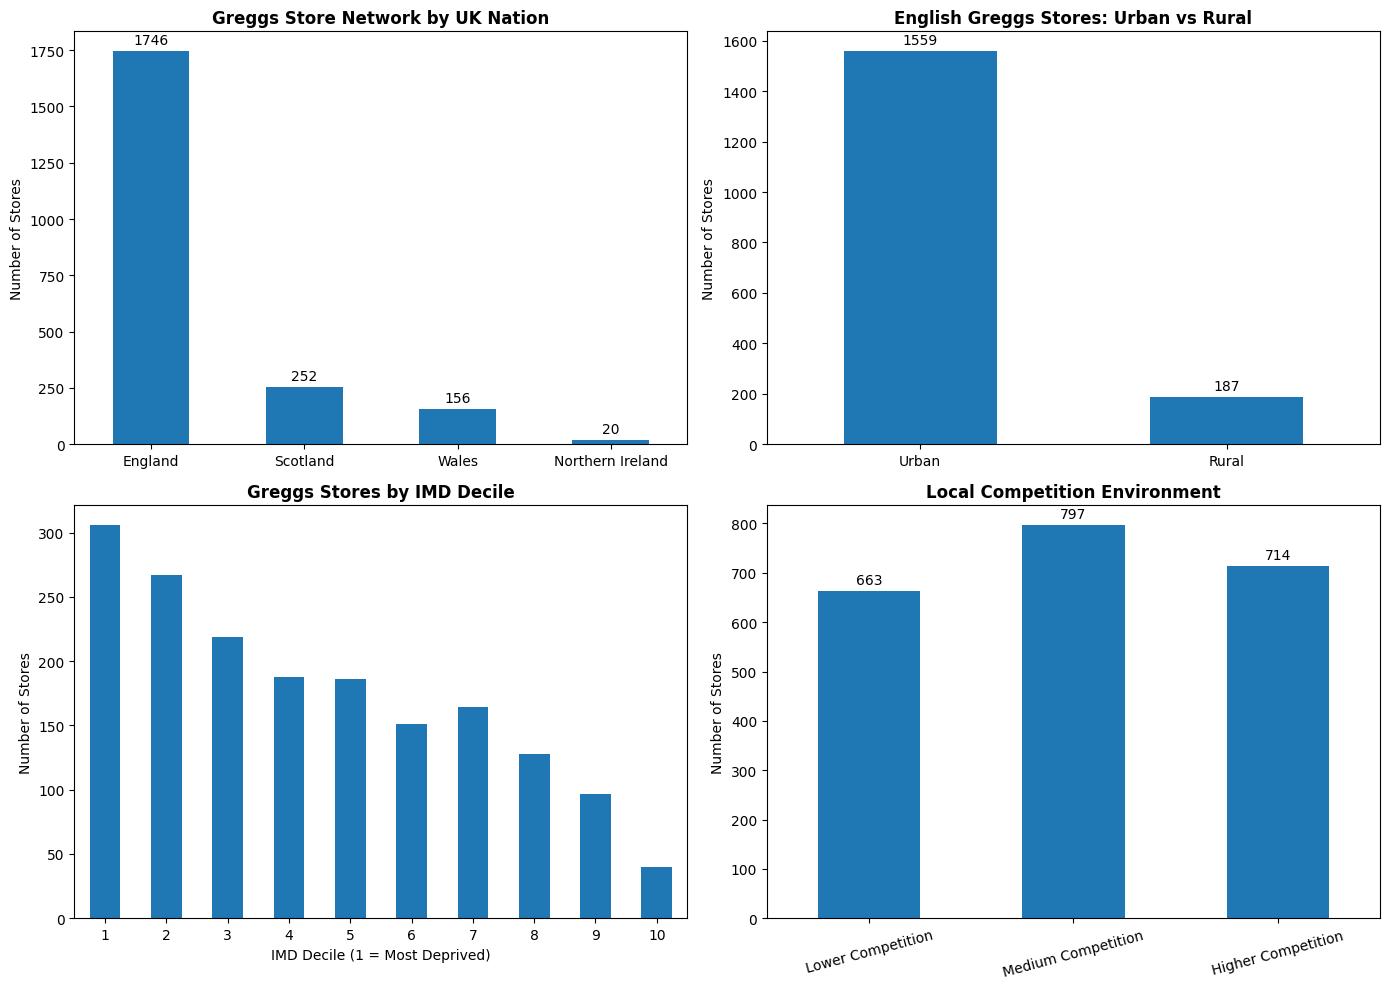


Saved figure: /content/drive/MyDrive/greggs-growth-intelligence-system/figures/eda_network_area_profile.png

STATUS: Network and area profile complete.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("SECTION 6.1 - Network and Area Profile")

country_counts = (
    analysis_uk["country"]
    .value_counts()
)

urban_counts = (
    analysis_england["rural_urban"]
    .value_counts()
)

decile_counts = (
    analysis_england["imd_decile"]
    .value_counts()
    .sort_index()
)

competition_counts = (
    analysis_uk["competition_environment"]
    .value_counts()
    .reindex([
        "Lower Competition",
        "Medium Competition",
        "Higher Competition"
    ])
)

print("\nUK network by country:")
print(country_counts.to_string())

print("\nEngland urban/rural profile:")
print(urban_counts.to_string())

print("\nEngland IMD decile distribution:")
print(decile_counts.to_string())

print("\nUK competition environment:")
print(competition_counts.to_string())

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

country_counts.plot(
    kind="bar",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Greggs Store Network by UK Nation",
    fontweight="bold"
)
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Number of Stores")
axes[0, 0].tick_params(
    axis="x",
    rotation=0
)

for container in axes[0, 0].containers:
    axes[0, 0].bar_label(
        container,
        padding=3
    )


urban_counts.plot(
    kind="bar",
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "English Greggs Stores: Urban vs Rural",
    fontweight="bold"
)
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Number of Stores")
axes[0, 1].tick_params(
    axis="x",
    rotation=0
)

for container in axes[0, 1].containers:
    axes[0, 1].bar_label(
        container,
        padding=3
    )


decile_counts.plot(
    kind="bar",
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Greggs Stores by IMD Decile",
    fontweight="bold"
)
axes[1, 0].set_xlabel(
    "IMD Decile (1 = Most Deprived)"
)
axes[1, 0].set_ylabel(
    "Number of Stores"
)
axes[1, 0].tick_params(
    axis="x",
    rotation=0
)


competition_counts.plot(
    kind="bar",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Local Competition Environment",
    fontweight="bold"
)
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel(
    "Number of Stores"
)
axes[1, 1].tick_params(
    axis="x",
    rotation=15
)

for container in axes[1, 1].containers:
    axes[1, 1].bar_label(
        container,
        padding=3
    )
plt.tight_layout()

NETWORK_PROFILE_FIGURE = (
    FIGURES_DIR /
    "eda_network_area_profile.png"
)

plt.savefig(
    NETWORK_PROFILE_FIGURE,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSaved figure:",
    NETWORK_PROFILE_FIGURE
)

print(
    "\nSTATUS: Network and area profile complete."
)

### 6.2 Deprivation Profile

The socioeconomic profile of English Greggs locations is examined using the English Indices of Deprivation 2025.

The analysis considers:

- representation of Greggs stores across IMD deciles
- distribution of IMD scores
- differences between urban and rural store environments
- local authorities where Greggs locations are concentrated in comparatively high-deprivation areas

Because each IMD decile contains approximately 10% of English LSOAs, the national LSOA distribution provides a useful reference point for assessing whether Greggs locations are disproportionately represented in particular deprivation groups.

These comparisons describe store-location patterns and do not establish why individual sites were selected.

SECTION 6.2 — Deprivation Profile

Deprivation representation:
  IMD deciles 1-3              : 45.4%
  IMD deciles 4-7              : 39.5%
  IMD deciles 8-10             : 15.2%
  Representation ratio (1-3)   : 1.51x
  Representation ratio (8-10)  : 0.51x

IMD profile by urban/rural classification:
             count  mean  median    std
rural_urban                            
Rural          187  16.5   14.28   8.69
Urban         1559  29.6   26.29  17.49

Highest average deprivation among local authorities with at least 5 Greggs stores:
local_authority  store_count  avg_imd_score  median_imd_decile
  Middlesbrough            7          57.34                1.0
         Oldham            5          55.48                1.0
     Darlington            7          54.29                1.0
      Blackpool            7          53.08                2.0
     Hartlepool            5          52.49                1.0
     Gloucester            5          50.28                1.0
       Rochda

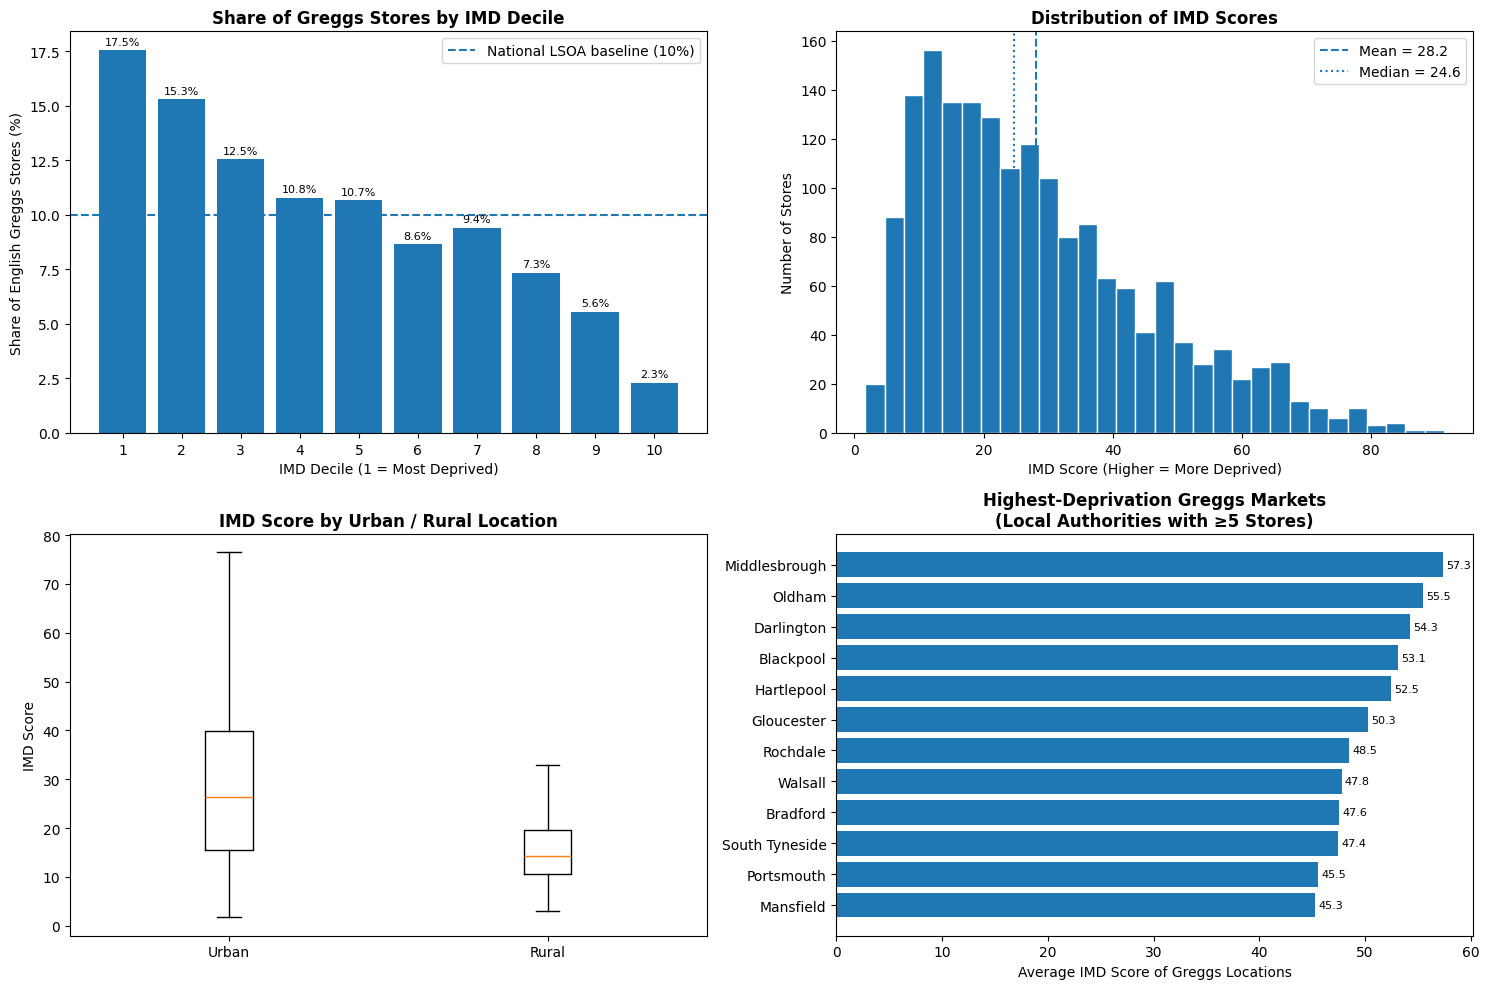


Saved figure: /content/drive/MyDrive/greggs-growth-intelligence-system/figures/eda_deprivation_profile.png

STATUS: Deprivation profile complete.


In [ ]:
# SECTION 6.2 - Deprivation Profile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("SECTION 6.2 — Deprivation Profile")

# Calculate the percentage of Greggs stores in each IMD decile
decile_share = (
    analysis_england["imd_decile"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

# Calculate headline deprivation groups
most_deprived_share = (
    analysis_england["imd_decile"]
    .le(3)
    .mean() * 100
)

middle_share = (
    analysis_england["imd_decile"]
    .between(4, 7)
    .mean() * 100
)

least_deprived_share = (
    analysis_england["imd_decile"]
    .ge(8)
    .mean() * 100
)

# Compare store representation with the national LSOA baseline
most_deprived_representation_ratio = (
    most_deprived_share / 30
)

least_deprived_representation_ratio = (
    least_deprived_share / 30
)

print("\nDeprivation representation:")

print(
    f"  IMD deciles 1-3              : "
    f"{most_deprived_share:.1f}%"
)

print(
    f"  IMD deciles 4-7              : "
    f"{middle_share:.1f}%"
)

print(
    f"  IMD deciles 8-10             : "
    f"{least_deprived_share:.1f}%"
)

print(
    f"  Representation ratio (1-3)   : "
    f"{most_deprived_representation_ratio:.2f}x"
)

print(
    f"  Representation ratio (8-10)  : "
    f"{least_deprived_representation_ratio:.2f}x"
)

# Compare urban and rural deprivation
urban_rural_imd = (
    analysis_england
    .groupby("rural_urban")
    ["imd_score"]
    .agg(["count", "mean", "median", "std"])
    .round(2)
)

print("\nIMD profile by urban/rural classification:")
print(urban_rural_imd.to_string())

# Calculate local-authority summaries
local_authority_profile = (
    analysis_england
    .groupby("local_authority")
    .agg(
        store_count=("osm_id", "count"),
        avg_imd_score=("imd_score", "mean"),
        median_imd_decile=("imd_decile", "median")
    )
    .reset_index()
)

# Require at least five Greggs stores before ranking an authority
local_authority_profile = (
    local_authority_profile[
        local_authority_profile["store_count"] >= 5
    ]
    .copy()
)

highest_deprivation_authorities = (
    local_authority_profile
    .sort_values(
        "avg_imd_score",
        ascending=False
    )
    .head(12)
)

print(
    "\nHighest average deprivation among local authorities "
    "with at least 5 Greggs stores:"
)

print(
    highest_deprivation_authorities[
        [
            "local_authority",
            "store_count",
            "avg_imd_score",
            "median_imd_decile"
        ]
    ]
    .round(2)
    .to_string(index=False)
)

# Create the deprivation-profile figure
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# Chart 1: Store share by IMD decile against the 10% LSOA baseline
axes[0, 0].bar(
    decile_share.index,
    decile_share.values
)

axes[0, 0].axhline(
    y=10,
    linestyle="--",
    linewidth=1.5,
    label="National LSOA baseline (10%)"
)

axes[0, 0].set_title(
    "Share of Greggs Stores by IMD Decile",
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "IMD Decile (1 = Most Deprived)"
)

axes[0, 0].set_ylabel(
    "Share of English Greggs Stores (%)"
)

axes[0, 0].set_xticks(
    range(1, 11)
)

axes[0, 0].legend()

for x, value in zip(
    decile_share.index,
    decile_share.values
):
    axes[0, 0].text(
        x,
        value + 0.25,
        f"{value:.1f}%",
        ha="center",
        fontsize=8
    )

# Chart 2: Distribution of IMD scores
axes[0, 1].hist(
    analysis_england["imd_score"],
    bins=30,
    edgecolor="white"
)

axes[0, 1].axvline(
    analysis_england["imd_score"].mean(),
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Mean = "
        f"{analysis_england['imd_score'].mean():.1f}"
    )
)

axes[0, 1].axvline(
    analysis_england["imd_score"].median(),
    linestyle=":",
    linewidth=1.5,
    label=(
        f"Median = "
        f"{analysis_england['imd_score'].median():.1f}"
    )
)

axes[0, 1].set_title(
    "Distribution of IMD Scores",
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "IMD Score (Higher = More Deprived)"
)

axes[0, 1].set_ylabel(
    "Number of Stores"
)

axes[0, 1].legend()

# Chart 3: Urban versus rural IMD score distribution
urban_data = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Urban",
        "imd_score"
    ]
)

rural_data = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Rural",
        "imd_score"
    ]
)

axes[1, 0].boxplot(
    [urban_data, rural_data],
    labels=["Urban", "Rural"],
    showfliers=False
)

axes[1, 0].set_title(
    "IMD Score by Urban / Rural Location",
    fontweight="bold"
)

axes[1, 0].set_ylabel(
    "IMD Score"
)

# Chart 4: Local authorities with highest average IMD
plot_la = (
    highest_deprivation_authorities
    .sort_values("avg_imd_score")
)

axes[1, 1].barh(
    plot_la["local_authority"],
    plot_la["avg_imd_score"]
)

axes[1, 1].set_title(
    "Highest-Deprivation Greggs Markets\n"
    "(Local Authorities with ≥5 Stores)",
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Average IMD Score of Greggs Locations"
)

for i, value in enumerate(
    plot_la["avg_imd_score"]
):
    axes[1, 1].text(
        value + 0.3,
        i,
        f"{value:.1f}",
        va="center",
        fontsize=8
    )

plt.tight_layout()

DEPRIVATION_PROFILE_FIGURE = (
    FIGURES_DIR /
    "eda_deprivation_profile.png"
)

plt.savefig(
    DEPRIVATION_PROFILE_FIGURE,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

print(
    "\nSaved figure:",
    DEPRIVATION_PROFILE_FIGURE
)

print(
    "\nSTATUS: Deprivation profile complete."
)

### 6.3 Competition Profile

The local competitive environment surrounding the Greggs network is examined using the spatial proximity features created previously.

The analysis considers:

- the brand of the nearest selected competitor
- distance to the nearest competitor
- number of competitors within 500 metres and 1 kilometre
- local overlap with each major competitor brand

The 500 metre measure represents the immediate local environment, while the 1 kilometre measure captures a broader nearby competitive market.

These measures describe geographic co-location and competitive intensity. They do not directly measure competitor sales, customer switching or causal competitive effects.

SECTION 6.3 — Competition Profile

Nearest competitor brands:
                          stores  share_pct
nearest_competitor_brand                   
Costa Coffee                 772       35.5
Subway                       656       30.2
McDonald's                   312       14.4
KFC                          215        9.9
Burger King                  144        6.6
Pret A Manger                 75        3.4

Nearest competitor distance summary:
count    2174.000
mean        0.599
std         1.885
min         0.002
25%         0.030
50%         0.079
75%         0.363
90%         1.439
95%         2.221
max        31.564

Local competition summary:
       competitors_within_500m  competitors_within_1km  brand_diversity_500m  brand_diversity_1km
count                  2174.00                 2174.00               2174.00              2174.00
mean                      3.10                    5.03                  2.14                 2.67
std                       3.88                

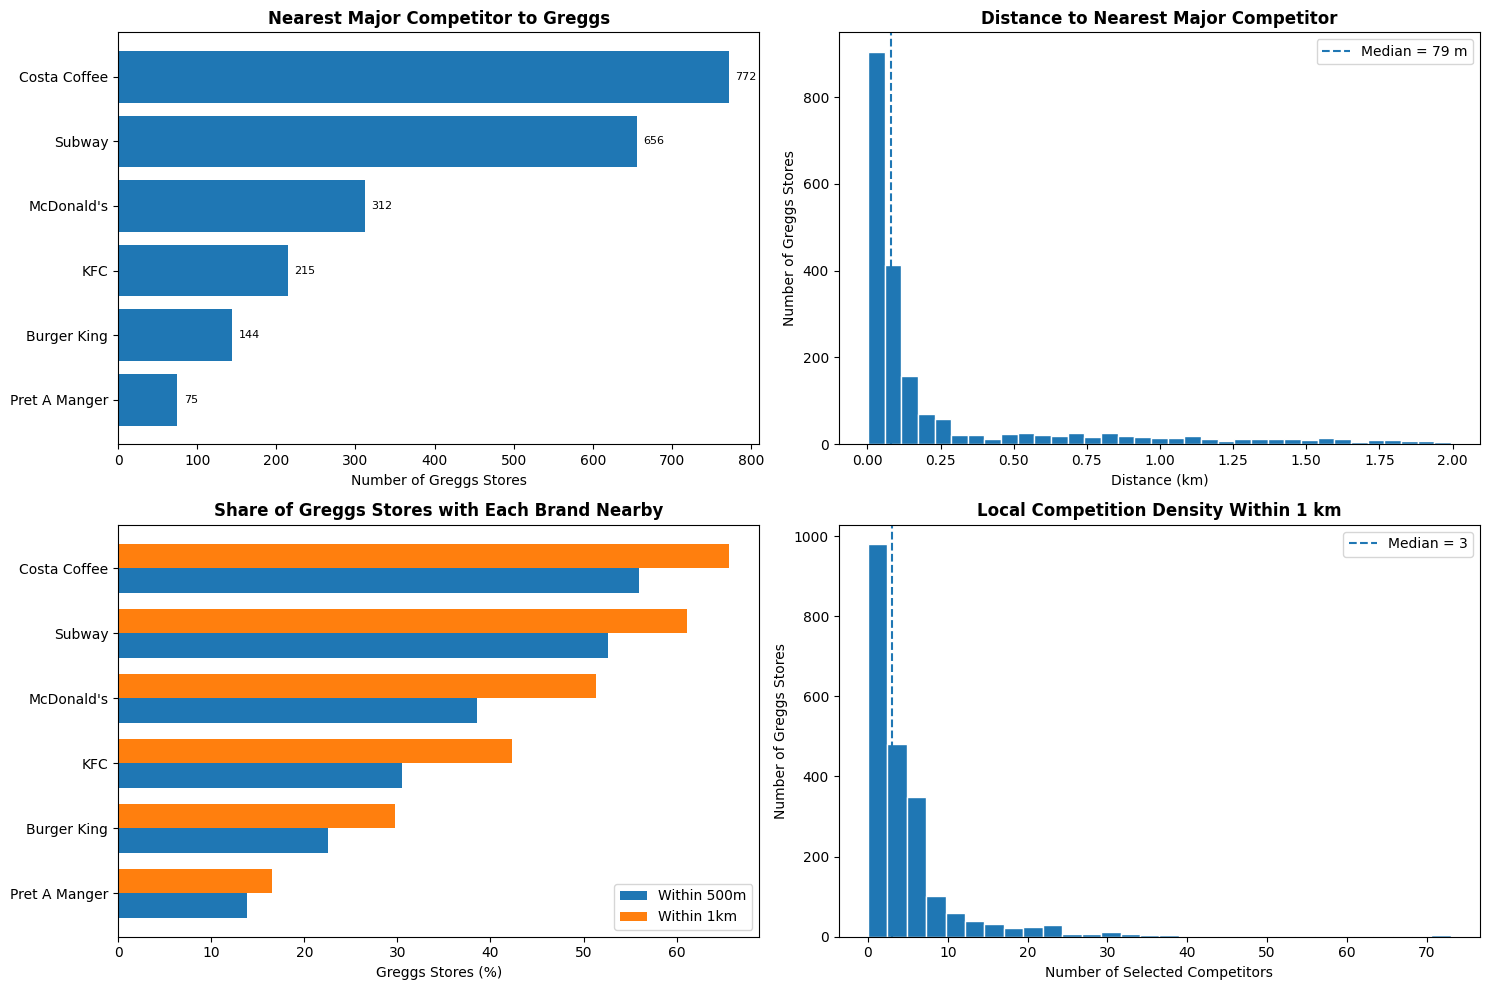


Saved figure: /content/drive/MyDrive/greggs-growth-intelligence-system/figures/eda_competition_profile.png
Saved brand summary: /content/drive/MyDrive/greggs-growth-intelligence-system/exports/competition_brand_overlap.csv

STATUS: Competition profile complete.


In [ ]:
# SECTION 6.3 - Competition Profile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("SECTION 6.3 — Competition Profile")

# Calculate nearest competitor brand distribution
nearest_brand_counts = (
    analysis_uk["nearest_competitor_brand"]
    .value_counts()
)

nearest_brand_share = (
    analysis_uk["nearest_competitor_brand"]
    .value_counts(normalize=True)
    .mul(100)
)

# Summarise nearest competitor distances
nearest_distance_summary = (
    analysis_uk["nearest_competitor_distance_km"]
    .describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
    .round(3)
)

# Calculate network competition statistics
competition_summary = (
    analysis_uk[
        [
            "competitors_within_500m",
            "competitors_within_1km",
            "brand_diversity_500m",
            "brand_diversity_1km"
        ]
    ]
    .describe()
    .round(2)
)

print("\nNearest competitor brands:")

nearest_brand_table = pd.DataFrame({
    "stores": nearest_brand_counts,
    "share_pct": nearest_brand_share.round(1)
})

print(
    nearest_brand_table
    .to_string()
)

print("\nNearest competitor distance summary:")
print(nearest_distance_summary.to_string())

print("\nLocal competition summary:")
print(competition_summary.to_string())

# Define the brand-feature columns used in the final dataset
brand_features = {
    "McDonald's": "mcdonalds",
    "Costa Coffee": "costa",
    "Subway": "subway",
    "KFC": "kfc",
    "Burger King": "burger_king",
    "Pret A Manger": "pret"
}

# Calculate the percentage of Greggs stores with each brand nearby
brand_overlap_records = []

for brand, feature in brand_features.items():

    within_500m = (
        analysis_uk[
            f"{feature}_within_500m"
        ] > 0
    ).mean() * 100

    within_1km = (
        analysis_uk[
            f"{feature}_within_1km"
        ] > 0
    ).mean() * 100

    median_distance = (
        analysis_uk[
            f"nearest_{feature}_km"
        ].median()
    )

    brand_overlap_records.append({
        "brand": brand,
        "within_500m_pct": within_500m,
        "within_1km_pct": within_1km,
        "median_nearest_km": median_distance
    })

brand_overlap = (
    pd.DataFrame(brand_overlap_records)
    .sort_values(
        "within_1km_pct",
        ascending=False
    )
    .reset_index(drop=True)
)

brand_overlap[
    [
        "within_500m_pct",
        "within_1km_pct"
    ]
] = (
    brand_overlap[
        [
            "within_500m_pct",
            "within_1km_pct"
        ]
    ]
    .round(1)
)

brand_overlap[
    "median_nearest_km"
] = (
    brand_overlap[
        "median_nearest_km"
    ].round(3)
)

print("\nBrand overlap with Greggs:")
print(
    brand_overlap.to_string(
        index=False
    )
)

# Calculate useful proximity headline measures
within_100m = (
    analysis_uk[
        "nearest_competitor_distance_km"
    ] <= 0.1
).mean() * 100

within_250m = (
    analysis_uk[
        "nearest_competitor_distance_km"
    ] <= 0.25
).mean() * 100

within_500m = (
    analysis_uk[
        "nearest_competitor_distance_km"
    ] <= 0.5
).mean() * 100

print("\nNearest-competitor proximity:")

print(
    f"  Within 100 metres : "
    f"{within_100m:.1f}%"
)

print(
    f"  Within 250 metres : "
    f"{within_250m:.1f}%"
)

print(
    f"  Within 500 metres : "
    f"{within_500m:.1f}%"
)

# Create competition-profile visualisations
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# Chart 1: Nearest competitor brand
nearest_brand_plot = (
    nearest_brand_counts
    .sort_values()
)

axes[0, 0].barh(
    nearest_brand_plot.index,
    nearest_brand_plot.values
)

axes[0, 0].set_title(
    "Nearest Major Competitor to Greggs",
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "Number of Greggs Stores"
)

for i, value in enumerate(
    nearest_brand_plot.values
):
    axes[0, 0].text(
        value + 8,
        i,
        str(value),
        va="center",
        fontsize=8
    )

# Chart 2: Distance to nearest competitor
distance_for_plot = (
    analysis_uk.loc[
        analysis_uk[
            "nearest_competitor_distance_km"
        ] <= 2,
        "nearest_competitor_distance_km"
    ]
)

axes[0, 1].hist(
    distance_for_plot,
    bins=35,
    edgecolor="white"
)

axes[0, 1].axvline(
    analysis_uk[
        "nearest_competitor_distance_km"
    ].median(),
    linestyle="--",
    linewidth=1.5,
    label=(
        "Median = "
        f"{analysis_uk['nearest_competitor_distance_km'].median()*1000:.0f} m"
    )
)

axes[0, 1].set_title(
    "Distance to Nearest Major Competitor",
    fontweight="bold"
)

axes[0, 1].set_xlabel(
    "Distance (km)"
)

axes[0, 1].set_ylabel(
    "Number of Greggs Stores"
)

axes[0, 1].legend()

# Chart 3: Brand overlap within 500m and 1km
plot_overlap = (
    brand_overlap
    .sort_values(
        "within_1km_pct",
        ascending=True
    )
)

y_positions = np.arange(
    len(plot_overlap)
)

bar_height = 0.38

axes[1, 0].barh(
    y_positions - bar_height / 2,
    plot_overlap["within_500m_pct"],
    height=bar_height,
    label="Within 500m"
)

axes[1, 0].barh(
    y_positions + bar_height / 2,
    plot_overlap["within_1km_pct"],
    height=bar_height,
    label="Within 1km"
)

axes[1, 0].set_yticks(
    y_positions
)

axes[1, 0].set_yticklabels(
    plot_overlap["brand"]
)

axes[1, 0].set_title(
    "Share of Greggs Stores with Each Brand Nearby",
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    "Greggs Stores (%)"
)

axes[1, 0].legend()

# Chart 4: Distribution of competitors within 1km
competition_for_plot = (
    analysis_uk[
        "competitors_within_1km"
    ]
)

axes[1, 1].hist(
    competition_for_plot,
    bins=30,
    edgecolor="white"
)

axes[1, 1].axvline(
    competition_for_plot.median(),
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Median = "
        f"{competition_for_plot.median():.0f}"
    )
)

axes[1, 1].set_title(
    "Local Competition Density Within 1 km",
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "Number of Selected Competitors"
)

axes[1, 1].set_ylabel(
    "Number of Greggs Stores"
)

axes[1, 1].legend()

plt.tight_layout()

COMPETITION_PROFILE_FIGURE = (
    FIGURES_DIR /
    "eda_competition_profile.png"
)

plt.savefig(
    COMPETITION_PROFILE_FIGURE,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# Save the brand-overlap summary for later reporting
BRAND_OVERLAP_FILE = (
    EXPORTS_DIR /
    "competition_brand_overlap.csv"
)

brand_overlap.to_csv(
    BRAND_OVERLAP_FILE,
    index=False
)

print(
    "\nSaved figure:",
    COMPETITION_PROFILE_FIGURE
)

print(
    "Saved brand summary:",
    BRAND_OVERLAP_FILE
)

print(
    "\nSTATUS: Competition profile complete."
)

### 6.4 Socioeconomic Environment and Local Competition

The relationship between deprivation and local competition is examined for English Greggs stores.

Earlier analysis showed that Greggs locations are disproportionately represented in more deprived LSOAs, while the competition analysis showed that most stores operate close to other major food-to-go and quick-service brands.

This section investigates whether these patterns are connected.

Particular attention is given to urbanisation because urban locations may simultaneously have:

- greater commercial density
- more nearby competitors
- different deprivation characteristics

The analysis is exploratory. Formal statistical testing of these relationships is performed later.

SECTION 6.4 — Socioeconomic Environment and Competition

Competition profile by IMD decile:
            stores  mean_competitors_1km  median_competitors_1km  mean_brand_diversity  median_nearest_distance_m
imd_decile                                                                                                       
1              306                  4.22                     3.0                  2.75                      87.75
2              267                  4.21                     3.0                  2.79                      82.90
3              219                  5.78                     3.0                  2.89                      73.50
4              188                  7.72                     4.0                  3.17                      66.45
5              186                  8.49                     3.0                  3.25                      71.95
6              151                  3.79                     3.0                  2.38                      81

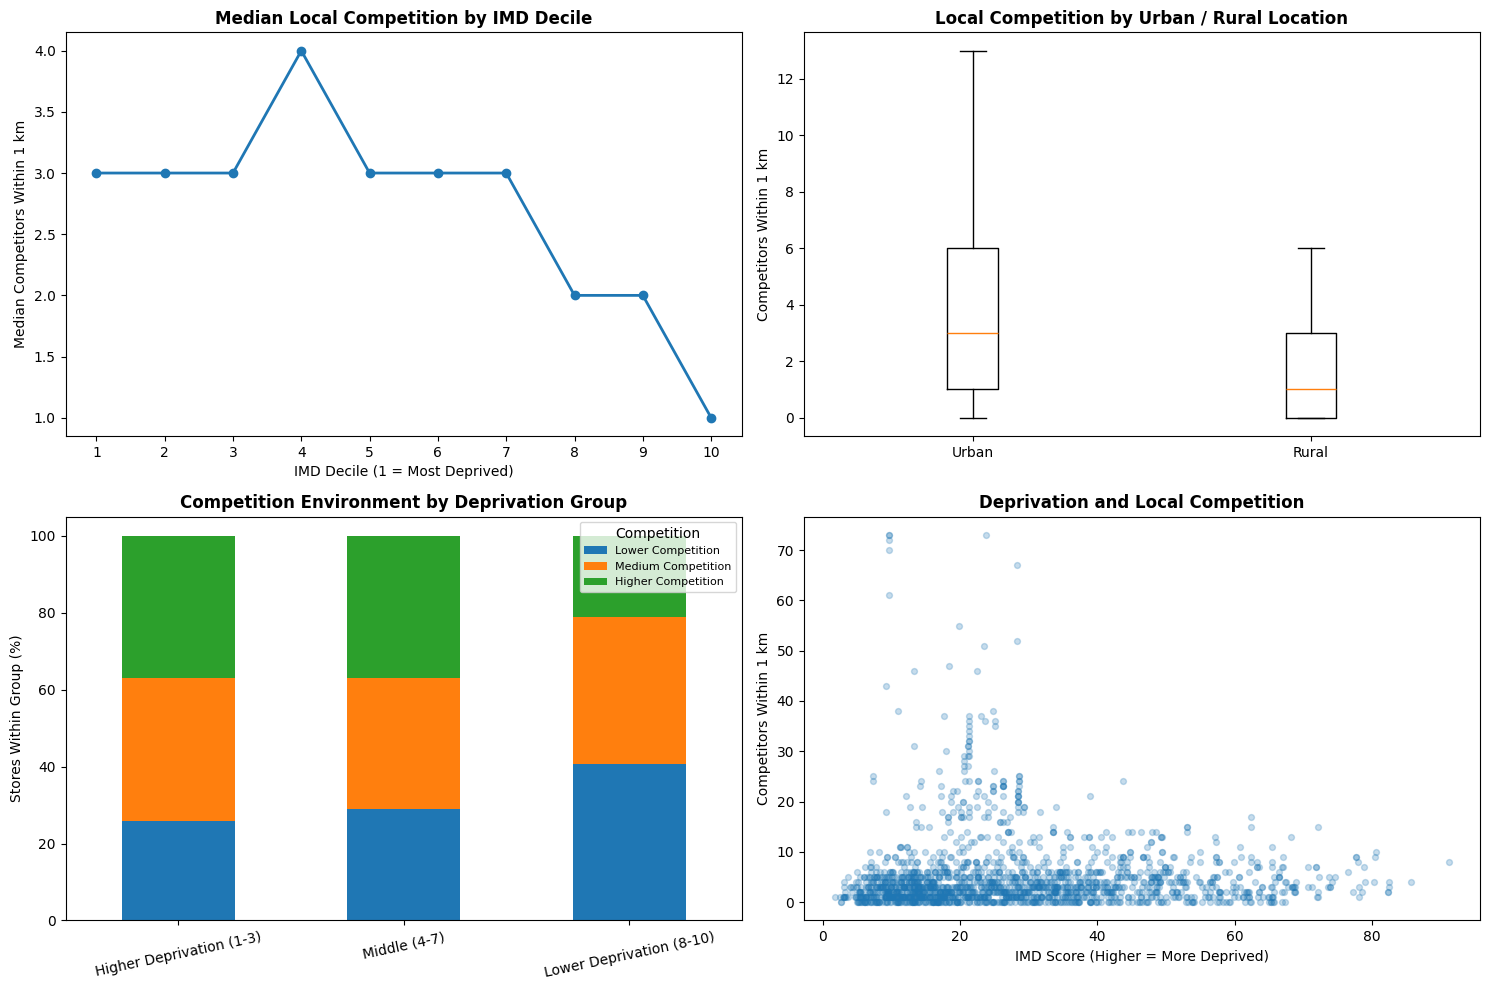


Saved figure: /content/drive/MyDrive/greggs-growth-intelligence-system/figures/eda_socioeconomic_competition.png

STATUS: Socioeconomic and competition EDA complete.


In [ ]:
# SECTION 6.4 - Socioeconomic Environment and Competition

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("SECTION 6.4 — Socioeconomic Environment and Competition")

# Create broad deprivation groups for interpretation
analysis_england["deprivation_group"] = np.select(
    [
        analysis_england["imd_decile"].between(1, 3),
        analysis_england["imd_decile"].between(4, 7),
        analysis_england["imd_decile"].between(8, 10)
    ],
    [
        "Higher Deprivation (1-3)",
        "Middle (4-7)",
        "Lower Deprivation (8-10)"
    ],
    default="Unknown"
)

# Summarise competition by individual IMD decile
competition_by_decile = (
    analysis_england
    .groupby("imd_decile")
    .agg(
        stores=("osm_id", "count"),
        mean_competitors_1km=("competitors_within_1km", "mean"),
        median_competitors_1km=("competitors_within_1km", "median"),
        mean_brand_diversity=("brand_diversity_1km", "mean"),
        median_nearest_distance_m=("nearest_competitor_distance_m", "median")
    )
    .round(2)
)

print("\nCompetition profile by IMD decile:")
print(competition_by_decile.to_string())

# Summarise competition across the three broader deprivation groups
competition_by_deprivation_group = (
    analysis_england
    .groupby(
        "deprivation_group",
        observed=True
    )
    .agg(
        stores=("osm_id", "count"),
        mean_competitors_1km=("competitors_within_1km", "mean"),
        median_competitors_1km=("competitors_within_1km", "median"),
        mean_brand_diversity=("brand_diversity_1km", "mean"),
        median_nearest_distance_m=("nearest_competitor_distance_m", "median")
    )
    .round(2)
)

group_order = [
    "Higher Deprivation (1-3)",
    "Middle (4-7)",
    "Lower Deprivation (8-10)"
]

competition_by_deprivation_group = (
    competition_by_deprivation_group
    .reindex(group_order)
)

print("\nCompetition by deprivation group:")
print(
    competition_by_deprivation_group
    .to_string()
)

# Compare urban and rural competition
competition_by_urbanity = (
    analysis_england
    .groupby("rural_urban")
    .agg(
        stores=("osm_id", "count"),
        mean_competitors_1km=("competitors_within_1km", "mean"),
        median_competitors_1km=("competitors_within_1km", "median"),
        mean_brand_diversity=("brand_diversity_1km", "mean"),
        median_nearest_distance_m=("nearest_competitor_distance_m", "median"),
        mean_imd_score=("imd_score", "mean")
    )
    .round(2)
)

print("\nCompetition and deprivation by urban/rural location:")
print(
    competition_by_urbanity
    .to_string()
)

# Calculate competition-environment percentages within each deprivation group
competition_environment_table = pd.crosstab(
    analysis_england["deprivation_group"],
    analysis_england["competition_environment"],
    normalize="index"
).mul(100)

competition_environment_table = (
    competition_environment_table
    .reindex(group_order)
)

competition_environment_table = (
    competition_environment_table[
        [
            "Lower Competition",
            "Medium Competition",
            "Higher Competition"
        ]
    ]
    .round(1)
)

print("\nCompetition environment within each deprivation group (%):")
print(
    competition_environment_table
    .to_string()
)

# Create the visual analysis
fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)

# Chart 1: Median competition by IMD decile
axes[0, 0].plot(
    competition_by_decile.index,
    competition_by_decile["median_competitors_1km"],
    marker="o",
    linewidth=2
)

axes[0, 0].set_title(
    "Median Local Competition by IMD Decile",
    fontweight="bold"
)

axes[0, 0].set_xlabel(
    "IMD Decile (1 = Most Deprived)"
)

axes[0, 0].set_ylabel(
    "Median Competitors Within 1 km"
)

axes[0, 0].set_xticks(
    range(1, 11)
)

# Chart 2: Competition distribution in urban and rural locations
urban_competition = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Urban",
        "competitors_within_1km"
    ]
)

rural_competition = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Rural",
        "competitors_within_1km"
    ]
)

axes[0, 1].boxplot(
    [
        urban_competition,
        rural_competition
    ],
    labels=[
        "Urban",
        "Rural"
    ],
    showfliers=False
)

axes[0, 1].set_title(
    "Local Competition by Urban / Rural Location",
    fontweight="bold"
)

axes[0, 1].set_ylabel(
    "Competitors Within 1 km"
)

# Chart 3: Competition environment composition by deprivation group
competition_environment_table.plot(
    kind="bar",
    stacked=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Competition Environment by Deprivation Group",
    fontweight="bold"
)

axes[1, 0].set_xlabel(
    ""
)

axes[1, 0].set_ylabel(
    "Stores Within Group (%)"
)

axes[1, 0].tick_params(
    axis="x",
    rotation=12
)

axes[1, 0].legend(
    title="Competition",
    fontsize=8
)

# Chart 4: IMD score against local competition
axes[1, 1].scatter(
    analysis_england["imd_score"],
    analysis_england["competitors_within_1km"],
    alpha=0.25,
    s=18
)

axes[1, 1].set_title(
    "Deprivation and Local Competition",
    fontweight="bold"
)

axes[1, 1].set_xlabel(
    "IMD Score (Higher = More Deprived)"
)

axes[1, 1].set_ylabel(
    "Competitors Within 1 km"
)

plt.tight_layout()

SOCIOECONOMIC_COMPETITION_FIGURE = (
    FIGURES_DIR /
    "eda_socioeconomic_competition.png"
)

plt.savefig(
    SOCIOECONOMIC_COMPETITION_FIGURE,
    dpi=180,
    bbox_inches="tight"
)

plt.show()

# Save grouped summaries for later reporting
COMPETITION_BY_DECILE_FILE = (
    EXPORTS_DIR /
    "competition_by_imd_decile.csv"
)

competition_by_decile.to_csv(
    COMPETITION_BY_DECILE_FILE
)

print(
    "\nSaved figure:",
    SOCIOECONOMIC_COMPETITION_FIGURE
)

print(
    "\nSTATUS: Socioeconomic and competition EDA complete."
)

### 6.5 Key EDA Findings and Analytical Questions

The exploratory analysis identified several important characteristics of the Greggs store network.

**Store geography**

Greggs is predominantly an urban network. Of the English locations in the analytical dataset, approximately 89% are classified as urban.

**Socioeconomic profile**

Greggs locations are disproportionately represented in more deprived English areas. IMD deciles 1–3 contain 45.4% of English Greggs stores, compared with approximately 30% of English LSOAs nationally.

Only 15.2% of stores are located in deciles 8–10.

Urban Greggs locations also have substantially higher average IMD scores than rural locations.

**Competitive environment**

Major food-to-go and quick-service competitors are commonly located close to Greggs.

The median distance to the nearest selected competitor is approximately 79 metres, and more than half of Greggs stores have a selected competitor within 100 metres.

Costa Coffee and Subway show the strongest geographic overlap with the Greggs network.

**Deprivation and competition**

Competition does not increase monotonically with deprivation.

Middle-deprivation locations show the highest mean competitor counts, while higher- and lower-deprivation groups show lower averages.

Urban stores experience substantially greater competition density than rural stores, suggesting that urbanisation may be an important factor connecting socioeconomic characteristics and commercial density.

These exploratory findings motivate the following statistical questions:

1. Do urban and rural Greggs locations differ significantly in deprivation?
2. Do urban and rural stores experience significantly different levels of local competition?
3. Is there a meaningful association between deprivation and competition density?
4. Do competition levels differ across broad deprivation groups?
5. How large are these differences, rather than merely whether they are statistically significant?

In [ ]:
# SECTION 6.5 - EDA Summary Metrics

print("SECTION 6.5 - EDA Summary Metrics")

# Calculate core network metrics
urban_share = (
    analysis_england["rural_urban"]
    .eq("Urban")
    .mean() * 100
)

high_deprivation_share = (
    analysis_england["imd_decile"]
    .between(1, 3)
    .mean() * 100
)

low_deprivation_share = (
    analysis_england["imd_decile"]
    .between(8, 10)
    .mean() * 100
)

# Calculate core competition metrics
median_nearest_competitor_m = (
    analysis_uk["nearest_competitor_distance_km"]
    .median() * 1000
)

competitor_within_100m_share = (
    analysis_uk["nearest_competitor_distance_km"]
    .le(0.1)
    .mean() * 100
)

median_competitors_1km = (
    analysis_uk["competitors_within_1km"]
    .median()
)

# Compare urban and rural environments
urban_mean_imd = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Urban",
        "imd_score"
    ]
    .mean()
)

rural_mean_imd = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Rural",
        "imd_score"
    ]
    .mean()
)

urban_mean_competition = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Urban",
        "competitors_within_1km"
    ]
    .mean()
)

rural_mean_competition = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Rural",
        "competitors_within_1km"
    ]
    .mean()
)

# Create a reusable summary table
eda_summary = pd.DataFrame({
    "metric": [
        "UK Greggs stores",
        "England analytical stores",
        "Urban share of English stores (%)",
        "Stores in IMD deciles 1-3 (%)",
        "Stores in IMD deciles 8-10 (%)",
        "Median nearest competitor distance (m)",
        "Stores with competitor within 100m (%)",
        "Median competitors within 1km",
        "Urban mean IMD score",
        "Rural mean IMD score",
        "Urban mean competitors within 1km",
        "Rural mean competitors within 1km"
    ],
    "value": [
        len(analysis_uk),
        len(analysis_england),
        round(urban_share, 1),
        round(high_deprivation_share, 1),
        round(low_deprivation_share, 1),
        round(median_nearest_competitor_m, 1),
        round(competitor_within_100m_share, 1),
        round(median_competitors_1km, 1),
        round(urban_mean_imd, 2),
        round(rural_mean_imd, 2),
        round(urban_mean_competition, 2),
        round(rural_mean_competition, 2)
    ]
})

print("\nKey EDA metrics:")
display(eda_summary)

# Save the summary for later reporting
EDA_SUMMARY_FILE = (
    EXPORTS_DIR /
    "eda_key_metrics.csv"
)

eda_summary.to_csv(
    EDA_SUMMARY_FILE,
    index=False
)

print("\nSaved summary:")
print(EDA_SUMMARY_FILE)

print("\nSTATUS: Exploratory Data Analysis complete.")

SECTION 6.5 - EDA Summary Metrics

Key EDA metrics:


,metric,value
0,UK Greggs stores,2174.00
1,England analytical stores,1746.00
2,Urban share of English stores (%),89.30
3,Stores in IMD deciles 1-3 (%),45.40
4,Stores in IMD deciles 8-10 (%),15.20
5,Median nearest competitor distance (m),79.20
6,Stores with competitor within 100m (%),56.70
7,Median competitors within 1km,3.00
8,Urban mean IMD score,29.60
9,Rural mean IMD score,16.50



Saved summary:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/eda_key_metrics.csv

STATUS: Exploratory Data Analysis complete.


## 7. Statistical Analysis

Statistical analysis is used to determine whether the patterns identified during exploratory analysis are sufficiently large and consistent to warrant stronger conclusions.

Statistical significance is assessed at a 5% significance level (α = 0.05).

However, p-values are not interpreted alone. Effect sizes and confidence intervals are also reported because a statistically significant result may still represent a practically small difference, particularly with large samples.

The tests are selected according to the structure and distribution of each variable rather than applying one statistical test to every comparison.

### 7.1 Urban versus Rural Deprivation

Exploratory analysis showed that English urban Greggs locations have substantially higher average IMD scores than rural locations.

This section tests whether the observed difference in mean deprivation is statistically significant.

**Null hypothesis (H₀):**  
The mean IMD score is the same for urban and rural Greggs locations.

**Alternative hypothesis (H₁):**  
The mean IMD scores differ between urban and rural Greggs locations.

Welch's independent-samples t-test is used because the urban and rural groups have substantially different sample sizes and may have unequal variances.

The size of the difference is additionally quantified using Hedges' g.

In [ ]:
# SECTION 7.1 - Urban vs Rural Deprivation

from scipy import stats
import numpy as np
import pandas as pd

print("SECTION 7.1 - Urban vs Rural Deprivation")

# Extract IMD scores for the two independent groups
urban_imd = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Urban",
        "imd_score"
    ]
    .dropna()
)

rural_imd = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Rural",
        "imd_score"
    ]
    .dropna()
)

# Summarise each group
group_summary = pd.DataFrame({
    "group": ["Urban", "Rural"],
    "n": [
        len(urban_imd),
        len(rural_imd)
    ],
    "mean_imd": [
        urban_imd.mean(),
        rural_imd.mean()
    ],
    "median_imd": [
        urban_imd.median(),
        rural_imd.median()
    ],
    "std_imd": [
        urban_imd.std(ddof=1),
        rural_imd.std(ddof=1)
    ]
}).round(2)

print("\nGroup summary:")
display(group_summary)

# Calculate the observed difference in means
mean_difference = (
    urban_imd.mean()
    - rural_imd.mean()
)

# Perform Welch's independent-samples t-test
welch_result = stats.ttest_ind(
    urban_imd,
    rural_imd,
    equal_var=False
)

t_statistic = welch_result.statistic
p_value = welch_result.pvalue

# Calculate Welch-Satterthwaite degrees of freedom
n1 = len(urban_imd)
n2 = len(rural_imd)

var1 = urban_imd.var(ddof=1)
var2 = rural_imd.var(ddof=1)

welch_df = (
    (var1 / n1 + var2 / n2) ** 2
    /
    (
        ((var1 / n1) ** 2 / (n1 - 1))
        +
        ((var2 / n2) ** 2 / (n2 - 1))
    )
)

# Calculate pooled standard deviation for the effect size
pooled_sd = np.sqrt(
    (
        (n1 - 1) * var1
        +
        (n2 - 1) * var2
    )
    /
    (n1 + n2 - 2)
)

cohens_d = (
    urban_imd.mean()
    - rural_imd.mean()
) / pooled_sd

# Apply small-sample correction to obtain Hedges' g
correction_factor = (
    1
    -
    3 / (
        4 * (n1 + n2) - 9
    )
)

hedges_g = (
    cohens_d
    * correction_factor
)

# Calculate a 95% confidence interval for the mean difference
standard_error_difference = np.sqrt(
    var1 / n1
    +
    var2 / n2
)

critical_t = stats.t.ppf(
    0.975,
    df=welch_df
)

ci_lower = (
    mean_difference
    -
    critical_t * standard_error_difference
)

ci_upper = (
    mean_difference
    +
    critical_t * standard_error_difference
)

print("\nWelch's t-test results:")

print(
    f"  Urban mean IMD             : "
    f"{urban_imd.mean():.2f}"
)

print(
    f"  Rural mean IMD             : "
    f"{rural_imd.mean():.2f}"
)

print(
    f"  Mean difference            : "
    f"{mean_difference:.2f}"
)

print(
    f"  t-statistic                : "
    f"{t_statistic:.3f}"
)

print(
    f"  Degrees of freedom         : "
    f"{welch_df:.1f}"
)

print(
    f"  p-value                    : "
    f"{p_value:.6g}"
)

print(
    f"  95% CI for mean difference : "
    f"[{ci_lower:.2f}, {ci_upper:.2f}]"
)

print(
    f"  Hedges' g                  : "
    f"{hedges_g:.3f}"
)

# Interpret statistical significance
if p_value < 0.05:
    significance_result = "Reject H0"
    significance_text = (
        "Urban and rural Greggs locations "
        "have statistically different mean IMD scores."
    )
else:
    significance_result = "Fail to reject H0"
    significance_text = (
        "The analysis does not provide sufficient evidence "
        "of a difference in mean IMD scores."
    )

# Interpret approximate effect-size magnitude
absolute_g = abs(hedges_g)

if absolute_g < 0.2:
    effect_label = "Very small"
elif absolute_g < 0.5:
    effect_label = "Small"
elif absolute_g < 0.8:
    effect_label = "Medium"
else:
    effect_label = "Large"

print("\nInterpretation:")

print(
    f"  Statistical decision : "
    f"{significance_result}"
)

print(
    f"  Effect magnitude     : "
    f"{effect_label}"
)

print(
    f"  Conclusion           : "
    f"{significance_text}"
)

print(
    "\nSTATUS: Urban/rural deprivation test complete."
)

SECTION 7.1 - Urban vs Rural Deprivation

Group summary:


,group,n,mean_imd,median_imd,std_imd
0,Urban,1559,29.6,26.29,17.49
1,Rural,187,16.5,14.28,8.69



Welch's t-test results:
  Urban mean IMD             : 29.60
  Rural mean IMD             : 16.50
  Mean difference            : 13.09
  t-statistic                : 16.900
  Degrees of freedom         : 399.4
  p-value                    : 1.00654e-48
  95% CI for mean difference : [11.57, 14.62]
  Hedges' g                  : 0.780

Interpretation:
  Statistical decision : Reject H0
  Effect magnitude     : Medium
  Conclusion           : Urban and rural Greggs locations have statistically different mean IMD scores.

STATUS: Urban/rural deprivation test complete.


### 7.2 Urban versus Rural Competition

Exploratory analysis showed that urban Greggs locations experience substantially greater local competition than rural locations.

Competitor counts are strongly right-skewed and contain many repeated integer values. A Mann–Whitney U test is therefore used as the primary comparison rather than relying on a normality-based comparison of means.

**Null hypothesis (H₀):**  
The distribution of competitors within 1 kilometre is the same for urban and rural Greggs locations.

**Alternative hypothesis (H₁):**  
The distributions differ between urban and rural Greggs locations.

The analysis also reports rank-biserial correlation as an effect-size measure.

In [ ]:
# SECTION 7.2 - Urban vs Rural Competition

print("SECTION 7.2 - Urban vs Rural Competition")

# Extract competitor counts for urban and rural stores
urban_competition = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Urban",
        "competitors_within_1km"
    ]
    .dropna()
)

rural_competition = (
    analysis_england.loc[
        analysis_england["rural_urban"] == "Rural",
        "competitors_within_1km"
    ]
    .dropna()
)

# Summarise the two groups
competition_group_summary = pd.DataFrame({
    "group": ["Urban", "Rural"],
    "n": [
        len(urban_competition),
        len(rural_competition)
    ],
    "mean": [
        urban_competition.mean(),
        rural_competition.mean()
    ],
    "median": [
        urban_competition.median(),
        rural_competition.median()
    ],
    "std": [
        urban_competition.std(ddof=1),
        rural_competition.std(ddof=1)
    ],
    "q1": [
        urban_competition.quantile(0.25),
        rural_competition.quantile(0.25)
    ],
    "q3": [
        urban_competition.quantile(0.75),
        rural_competition.quantile(0.75)
    ]
}).round(2)

print("\nGroup summary:")
display(competition_group_summary)

# Perform two-sided Mann-Whitney U test
mw_result = stats.mannwhitneyu(
    urban_competition,
    rural_competition,
    alternative="two-sided",
    method="asymptotic"
)

u_statistic = mw_result.statistic
p_value = mw_result.pvalue

# Calculate rank-biserial correlation
n_urban = len(urban_competition)
n_rural = len(rural_competition)

rank_biserial = (
    (2 * u_statistic)
    / (n_urban * n_rural)
    - 1
)

# Calculate simple median difference for interpretation
median_difference = (
    urban_competition.median()
    - rural_competition.median()
)

print("\nMann-Whitney U results:")

print(
    f"  Urban median competitors    : "
    f"{urban_competition.median():.1f}"
)

print(
    f"  Rural median competitors    : "
    f"{rural_competition.median():.1f}"
)

print(
    f"  Median difference           : "
    f"{median_difference:.1f}"
)

print(
    f"  Urban mean competitors      : "
    f"{urban_competition.mean():.2f}"
)

print(
    f"  Rural mean competitors      : "
    f"{rural_competition.mean():.2f}"
)

print(
    f"  U statistic                 : "
    f"{u_statistic:.1f}"
)

print(
    f"  p-value                     : "
    f"{p_value:.6g}"
)

print(
    f"  Rank-biserial correlation   : "
    f"{rank_biserial:.3f}"
)

# Interpret the statistical result
if p_value < 0.05:
    decision = "Reject H0"
    conclusion = (
        "Urban and rural Greggs locations have "
        "statistically different competition distributions."
    )
else:
    decision = "Fail to reject H0"
    conclusion = (
        "There is insufficient evidence of a difference "
        "in competition distributions."
    )

# Interpret the effect-size magnitude
absolute_r = abs(rank_biserial)

if absolute_r < 0.10:
    effect_label = "Very small"
elif absolute_r < 0.30:
    effect_label = "Small"
elif absolute_r < 0.50:
    effect_label = "Moderate"
else:
    effect_label = "Large"

print("\nInterpretation:")

print(
    f"  Statistical decision : "
    f"{decision}"
)

print(
    f"  Effect magnitude     : "
    f"{effect_label}"
)

print(
    f"  Conclusion           : "
    f"{conclusion}"
)

print(
    "\nSTATUS: Urban/rural competition test complete."
)

SECTION 7.2 - Urban vs Rural Competition

Group summary:


,group,n,mean,median,std,q1,q3
0,Urban,1559,5.57,3.0,8.04,1.0,6.0
1,Rural,187,2.08,1.0,2.29,0.0,3.0



Mann-Whitney U results:
  Urban median competitors    : 3.0
  Rural median competitors    : 1.0
  Median difference           : 2.0
  Urban mean competitors      : 5.57
  Rural mean competitors      : 2.08
  U statistic                 : 200945.0
  p-value                     : 1.5203e-17
  Rank-biserial correlation   : 0.379

Interpretation:
  Statistical decision : Reject H0
  Effect magnitude     : Moderate
  Conclusion           : Urban and rural Greggs locations have statistically different competition distributions.

STATUS: Urban/rural competition test complete.


### 7.3 Association Between Deprivation and Local Competition

Exploratory analysis did not show a simple linear relationship between deprivation and competition density.

Spearman's rank correlation is used to test whether stores located in areas with higher deprivation scores tend to experience systematically higher or lower local competition.

Spearman correlation is appropriate because competitor counts are highly skewed and the relationship does not need to be linear.

**Null hypothesis (H₀):**  
There is no monotonic association between IMD score and the number of competitors within 1 kilometre.

**Alternative hypothesis (H₁):**  
A monotonic association exists between IMD score and local competitor density.

The analysis is first performed across all English Greggs stores and then separately for urban stores to examine whether urbanisation influences the observed relationship.

In [ ]:
# SECTION 7.3 - Deprivation and Competition Association
print("SECTION 7.3 - Deprivation and Competition Association")

# Keep only complete English observations
corr_data = (
    analysis_england[
        [
            "imd_score",
            "imd_decile",
            "competitors_within_1km",
            "brand_diversity_1km",
            "rural_urban"
        ]
    ]
    .dropna()
    .copy()
)

# Test IMD score against competition density
rho_imd_comp, p_imd_comp = stats.spearmanr(
    corr_data["imd_score"],
    corr_data["competitors_within_1km"]
)

# Test IMD score against nearby brand diversity
rho_imd_diversity, p_imd_diversity = stats.spearmanr(
    corr_data["imd_score"],
    corr_data["brand_diversity_1km"]
)

# Repeat the main test for urban locations only
urban_corr_data = (
    corr_data[
        corr_data["rural_urban"] == "Urban"
    ]
)

rho_urban, p_urban = stats.spearmanr(
    urban_corr_data["imd_score"],
    urban_corr_data["competitors_within_1km"]
)

# Repeat the main test for rural locations only
rural_corr_data = (
    corr_data[
        corr_data["rural_urban"] == "Rural"
    ]
)

rho_rural, p_rural = stats.spearmanr(
    rural_corr_data["imd_score"],
    rural_corr_data["competitors_within_1km"]
)

# Store the results in a summary table
spearman_results = pd.DataFrame({
    "analysis": [
        "All England stores: IMD vs competitors within 1km",
        "All England stores: IMD vs brand diversity within 1km",
        "Urban stores: IMD vs competitors within 1km",
        "Rural stores: IMD vs competitors within 1km"
    ],
    "n": [
        len(corr_data),
        len(corr_data),
        len(urban_corr_data),
        len(rural_corr_data)
    ],
    "spearman_rho": [
        rho_imd_comp,
        rho_imd_diversity,
        rho_urban,
        rho_rural
    ],
    "p_value": [
        p_imd_comp,
        p_imd_diversity,
        p_urban,
        p_rural
    ]
})

spearman_results["spearman_rho"] = (
    spearman_results["spearman_rho"]
    .round(3)
)

print("\nSpearman correlation results:")
display(spearman_results)

# Interpret correlation strength
def interpret_spearman(rho):
    magnitude = abs(rho)

    if magnitude < 0.10:
        strength = "Negligible"
    elif magnitude < 0.30:
        strength = "Weak"
    elif magnitude < 0.50:
        strength = "Moderate"
    elif magnitude < 0.70:
        strength = "Strong"
    else:
        strength = "Very strong"

    if rho > 0:
        direction = "positive"
    elif rho < 0:
        direction = "negative"
    else:
        direction = "no"

    return strength, direction

overall_strength, overall_direction = interpret_spearman(
    rho_imd_comp
)

urban_strength, urban_direction = interpret_spearman(
    rho_urban
)

rural_strength, rural_direction = interpret_spearman(
    rho_rural
)

print("\nMain result:")

print(
    f"  All England stores rho : "
    f"{rho_imd_comp:.3f}"
)

print(
    f"  p-value                : "
    f"{p_imd_comp:.6g}"
)

print(
    f"  Relationship           : "
    f"{overall_strength} {overall_direction}"
)

print("\nUrban-only result:")

print(
    f"  rho                     : "
    f"{rho_urban:.3f}"
)

print(
    f"  p-value                 : "
    f"{p_urban:.6g}"
)

print(
    f"  Relationship            : "
    f"{urban_strength} {urban_direction}"
)

print("\nRural-only result:")

print(
    f"  rho                     : "
    f"{rho_rural:.3f}"
)

print(
    f"  p-value                 : "
    f"{p_rural:.6g}"
)

print(
    f"  Relationship            : "
    f"{rural_strength} {rural_direction}"
)

# State the hypothesis-test decision for the overall relationship
if p_imd_comp < 0.05:
    decision = "Reject H0"
else:
    decision = "Fail to reject H0"

print("\nInterpretation:")

print(
    f"  Statistical decision : "
    f"{decision}"
)

print(
    "  Note                 : Correlation describes association, "
    "not causation."
)

print(
    "\nSTATUS: Deprivation/competition association test complete."
)

SECTION 7.3 - Deprivation and Competition Association

Spearman correlation results:


,analysis,n,spearman_rho,p_value
0,All England stores: IMD vs competitors within 1km,1746,0.112,0.000003
1,All England stores: IMD vs brand diversity wit...,1746,0.106,0.000010
2,Urban stores: IMD vs competitors within 1km,1559,0.070,0.006018
3,Rural stores: IMD vs competitors within 1km,187,-0.074,0.314764



Main result:
  All England stores rho : 0.112
  p-value                : 2.8348e-06
  Relationship           : Weak positive

Urban-only result:
  rho                     : 0.070
  p-value                 : 0.00601819
  Relationship            : Negligible positive

Rural-only result:
  rho                     : -0.074
  p-value                 : 0.314764
  Relationship            : Negligible negative

Interpretation:
  Statistical decision : Reject H0
  Note                 : Correlation describes association, not causation.

STATUS: Deprivation/competition association test complete.


### 7.4 Competition Across Deprivation Groups

The exploratory analysis showed that local competition does not change monotonically across deprivation levels. Middle-deprivation Greggs locations showed the highest average competitor counts, while lower-deprivation locations showed the lowest median competition.

A Kruskal–Wallis test is used to determine whether the distribution of competitors within 1 kilometre differs across the three broad deprivation groups.

**Null hypothesis (H₀):**  
The competition distributions are the same across higher-, middle-, and lower-deprivation Greggs locations.

**Alternative hypothesis (H₁):**  
At least one deprivation group has a different competition distribution.

Because the competition variable is strongly right-skewed, the non-parametric Kruskal–Wallis test is preferred to a one-way ANOVA.

If the overall test is statistically significant, pairwise Mann–Whitney U tests are used to identify which groups differ. Holm adjustment is applied to the pairwise p-values to control for multiple comparisons.

In [ ]:
# SECTION 7.4 - Competition Across Deprivation Groups
print("SECTION 7.4 - Competition Across Deprivation Groups")

# Define the three deprivation groups
group_order = [
    "Higher Deprivation (1-3)",
    "Middle (4-7)",
    "Lower Deprivation (8-10)"
]

# Extract competitor counts for each group
higher_comp = (
    analysis_england.loc[
        analysis_england["deprivation_group"] == "Higher Deprivation (1-3)",
        "competitors_within_1km"
    ]
    .dropna()
)

middle_comp = (
    analysis_england.loc[
        analysis_england["deprivation_group"] == "Middle (4-7)",
        "competitors_within_1km"
    ]
    .dropna()
)

lower_comp = (
    analysis_england.loc[
        analysis_england["deprivation_group"] == "Lower Deprivation (8-10)",
        "competitors_within_1km"
    ]
    .dropna()
)

# Create descriptive summary
deprivation_comp_summary = pd.DataFrame({
    "group": group_order,
    "n": [
        len(higher_comp),
        len(middle_comp),
        len(lower_comp)
    ],
    "mean_competitors": [
        higher_comp.mean(),
        middle_comp.mean(),
        lower_comp.mean()
    ],
    "median_competitors": [
        higher_comp.median(),
        middle_comp.median(),
        lower_comp.median()
    ],
    "q1": [
        higher_comp.quantile(0.25),
        middle_comp.quantile(0.25),
        lower_comp.quantile(0.25)
    ],
    "q3": [
        higher_comp.quantile(0.75),
        middle_comp.quantile(0.75),
        lower_comp.quantile(0.75)
    ]
}).round(2)

print("\nGroup summary:")
display(deprivation_comp_summary)

# Perform Kruskal-Wallis test
kw_result = stats.kruskal(
    higher_comp,
    middle_comp,
    lower_comp
)

h_statistic = kw_result.statistic
kw_p_value = kw_result.pvalue

print("\nKruskal-Wallis results:")

print(
    f"  H statistic : "
    f"{h_statistic:.3f}"
)

print(
    f"  p-value     : "
    f"{kw_p_value:.6g}"
)

# Calculate epsilon-squared effect size
n_total = (
    len(higher_comp)
    + len(middle_comp)
    + len(lower_comp)
)

k_groups = 3

epsilon_squared = (
    h_statistic
    - k_groups
    + 1
) / (
    n_total
    - k_groups
)

print(
    f"  Epsilon²    : "
    f"{epsilon_squared:.3f}"
)

# Interpret approximate effect size
if epsilon_squared < 0.01:
    effect_label = "Negligible"
elif epsilon_squared < 0.06:
    effect_label = "Small"
elif epsilon_squared < 0.14:
    effect_label = "Moderate"
else:
    effect_label = "Large"

if kw_p_value < 0.05:
    overall_decision = "Reject H0"
else:
    overall_decision = "Fail to reject H0"

print("\nOverall interpretation:")

print(
    f"  Statistical decision : "
    f"{overall_decision}"
)

print(
    f"  Effect magnitude     : "
    f"{effect_label}"
)

# Run pairwise tests only when the overall test is significant
groups = {
    "Higher vs Middle": (
        higher_comp,
        middle_comp
    ),
    "Higher vs Lower": (
        higher_comp,
        lower_comp
    ),
    "Middle vs Lower": (
        middle_comp,
        lower_comp
    )
}

pairwise_results = []

for comparison, (group_a, group_b) in groups.items():

    result = stats.mannwhitneyu(
        group_a,
        group_b,
        alternative="two-sided",
        method="asymptotic"
    )

    pairwise_results.append({
        "comparison": comparison,
        "u_statistic": result.statistic,
        "raw_p_value": result.pvalue
    })

pairwise_df = pd.DataFrame(
    pairwise_results
)

# Apply Holm multiple-testing correction manually
order = np.argsort(
    pairwise_df["raw_p_value"].values
)

m = len(pairwise_df)

adjusted = np.empty(
    m,
    dtype=float
)

running_max = 0

for rank, idx in enumerate(order):

    multiplier = (
        m - rank
    )

    adjusted_p = min(
        pairwise_df.loc[idx, "raw_p_value"]
        * multiplier,
        1.0
    )

    running_max = max(
        running_max,
        adjusted_p
    )

    adjusted[idx] = running_max

pairwise_df["holm_p_value"] = adjusted

pairwise_df["significant_after_correction"] = (
    pairwise_df["holm_p_value"] < 0.05
)

pairwise_df["u_statistic"] = (
    pairwise_df["u_statistic"]
    .round(1)
)

print("\nPairwise comparisons:")
display(pairwise_df)

print(
    "\nSTATUS: Competition/deprivation-group analysis complete."
)

SECTION 7.4 - Competition Across Deprivation Groups

Group summary:


,group,n,mean_competitors,median_competitors,q1,q3
0,Higher Deprivation (1-3),792,4.65,3.0,1.0,6.0
1,Middle (4-7),689,6.19,3.0,1.0,6.0
2,Lower Deprivation (8-10),265,4.25,2.0,1.0,4.0



Kruskal-Wallis results:
  H statistic : 32.417
  p-value     : 9.13473e-08
  Epsilon²    : 0.017

Overall interpretation:
  Statistical decision : Reject H0
  Effect magnitude     : Small

Pairwise comparisons:


,comparison,u_statistic,raw_p_value,holm_p_value,significant_after_correction
0,Higher vs Middle,272205.0,9.376446e-01,9.376446e-01,False
1,Higher vs Lower,128883.0,2.082833e-08,6.248500e-08,True
2,Middle vs Lower,110103.0,6.622859e-07,1.324572e-06,True



STATUS: Competition/deprivation-group analysis complete.


### 7.5 Statistical Analysis Summary

The statistical analysis supports several of the patterns identified during exploratory analysis, while also showing that statistical significance does not necessarily imply a strong practical relationship.

Urban Greggs locations are substantially more deprived than rural locations, with a moderate-to-large standardised difference.

Urban stores also operate in significantly more competitive environments than rural stores, with a moderate distributional effect.

Deprivation itself has only a weak association with local competition. This relationship becomes negligible when urban locations are considered separately, suggesting that urban commercial density is an important contextual factor.

Competition also differs across broad deprivation groups, although the overall effect is small. Lower-deprivation locations tend to experience less competition, while higher- and middle-deprivation locations have broadly similar competition distributions.

Together, these results suggest that store context is multidimensional. Deprivation, urbanisation and local competition should therefore be treated as related but distinct characteristics rather than combined into a simple deterministic rule.

In [ ]:
# SECTION 7.5 - Statistical Analysis Summary
print("SECTION 7.5 - Statistical Analysis Summary")
# Consolidate the principal statistical results
statistical_summary = pd.DataFrame({
    "research_question": [
        "Do urban and rural stores differ in deprivation?",
        "Do urban and rural stores differ in local competition?",
        "Is deprivation associated with local competition?",
        "Does competition differ across deprivation groups?"
    ],

    "test": [
        "Welch's t-test",
        "Mann-Whitney U",
        "Spearman rank correlation",
        "Kruskal-Wallis"
    ],

    "statistic": [
        round(t_statistic, 3),
        round(u_statistic, 1),
        round(rho_imd_comp, 3),
        round(h_statistic, 3)
    ],

    "p_value": [
        p_value if "p_value" in globals() else None,
        None,
        p_imd_comp,
        kw_p_value
    ],

    "effect_measure": [
        "Hedges' g",
        "Rank-biserial correlation",
        "Spearman rho",
        "Epsilon-squared"
    ],

    "effect_size": [
        round(hedges_g, 3),
        round(rank_biserial, 3),
        round(rho_imd_comp, 3),
        round(epsilon_squared, 3)
    ],

    "effect_interpretation": [
        "Moderate-to-large",
        "Moderate",
        "Weak",
        "Small"
    ],

    "conclusion": [
        "Urban stores are substantially more deprived than rural stores.",
        "Urban stores generally face greater local competition.",
        "Deprivation has only a weak positive association with competition.",
        "Competition differs across deprivation groups, but the effect is small."
    ]
})

# Replace the Mann-Whitney p-value explicitly
statistical_summary.loc[
    statistical_summary["test"] == "Mann-Whitney U",
    "p_value"
] = 1.5203e-17

# Replace the Welch test p-value explicitly
statistical_summary.loc[
    statistical_summary["test"] == "Welch's t-test",
    "p_value"
] = 1.00654e-48

print("\nStatistical analysis summary:")
display(statistical_summary)

# Save reusable results for README and Power BI
STATISTICAL_SUMMARY_FILE = (
    EXPORTS_DIR /
    "statistical_analysis_summary.csv"
)

statistical_summary.to_csv(
    STATISTICAL_SUMMARY_FILE,
    index=False
)

# Save pairwise deprivation-group results as well
PAIRWISE_RESULTS_FILE = (
    EXPORTS_DIR /
    "deprivation_group_pairwise_tests.csv"
)

pairwise_df.to_csv(
    PAIRWISE_RESULTS_FILE,
    index=False
)

print("\nSaved statistical summary:")
print(STATISTICAL_SUMMARY_FILE)

print("\nSaved pairwise comparison results:")
print(PAIRWISE_RESULTS_FILE)

print("\nKey statistical conclusions:")
print("1. Urban locations are substantially more deprived than rural locations.")
print("2. Urban locations generally operate in more competitive environments.")
print("3. Deprivation alone has only a weak relationship with competition density.")
print("4. Lower-deprivation locations tend to face less competition.")
print("5. Urbanisation appears more important for competition than deprivation alone.")
print("\nSTATUS: Statistical Analysis complete.")

SECTION 7.5 - Statistical Analysis Summary

Statistical analysis summary:


,research_question,test,statistic,p_value,effect_measure,effect_size,effect_interpretation,conclusion
0,Do urban and rural stores differ in deprivation?,Welch's t-test,16.900,1.006540e-48,Hedges' g,0.780,Moderate-to-large,Urban stores are substantially more deprived t...
1,Do urban and rural stores differ in local comp...,Mann-Whitney U,200945.000,1.520300e-17,Rank-biserial correlation,0.379,Moderate,Urban stores generally face greater local comp...
2,Is deprivation associated with local competition?,Spearman rank correlation,0.112,2.834801e-06,Spearman rho,0.112,Weak,Deprivation has only a weak positive associati...
3,Does competition differ across deprivation gro...,Kruskal-Wallis,32.417,9.134726e-08,Epsilon-squared,0.017,Small,"Competition differs across deprivation groups,..."



Saved statistical summary:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/statistical_analysis_summary.csv

Saved pairwise comparison results:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/deprivation_group_pairwise_tests.csv

Key statistical conclusions:
1. Urban locations are substantially more deprived than rural locations.
2. Urban locations generally operate in more competitive environments.
3. Deprivation alone has only a weak relationship with competition density.
4. Lower-deprivation locations tend to face less competition.
5. Urbanisation appears more important for competition than deprivation alone.

STATUS: Statistical Analysis complete.


## 8. Machine Learning — Strategic Store Segmentation

The machine-learning stage uses unsupervised learning to identify natural strategic segments within the English Greggs store network.

Rather than predicting a manually defined opportunity label, the analysis allows stores to group according to similarities in their socioeconomic, geographic and competitive environments.

### 8.1 Feature Preparation

Five dimensions are initially used for segmentation:

- deprivation level
- local population
- competition density
- competitor-brand diversity
- urban/rural context

Highly related socioeconomic variables such as income, employment and crime scores are not simultaneously included with IMD because doing so would disproportionately weight deprivation within the clustering process.

Similarly, individual competitor-brand counts and engineered competition indices are excluded from the initial model to avoid repeatedly representing the same underlying competitive environment.

Skewed count variables are log-transformed before standardisation. All final model features are then standardised because K-Means clustering is distance-based and is sensitive to differences in measurement scale.

In [ ]:
# SECTION 8.1 - Machine Learning Feature Preparation
from sklearn.preprocessing import StandardScaler
print("SECTION 8.1 - Machine Learning Feature Preparation")

# Use the England analytical dataset because IoD 2025
# socioeconomic variables are available for English stores.
ml_data = analysis_england.copy()

# Define the raw variables needed for clustering.
required_columns = [
    "osm_id",
    "imd_score",
    "total_population",
    "competitors_within_1km",
    "brand_diversity_1km",
    "rural_urban"
]

# Confirm that every required column exists.
missing_columns = [
    column
    for column in required_columns
    if column not in ml_data.columns
]

if missing_columns:
    raise KeyError(
        f"Missing required columns: {missing_columns}"
    )

# Keep stores with complete information for the selected features.
before_rows = len(ml_data)

ml_data = (
    ml_data
    .dropna(subset=required_columns)
    .copy()
)

after_rows = len(ml_data)

print(f"\nStores before ML filtering : {before_rows:,}")
print(f"Stores available for ML    : {after_rows:,}")
print(f"Stores removed             : {before_rows - after_rows:,}")


# Convert urban/rural classification into a numeric indicator.
# Urban = 1 and Rural = 0.
ml_data["urban_flag"] = (
    ml_data["rural_urban"]
    .eq("Urban")
    .astype(int)
)


# Competitor counts are strongly right-skewed.
# log1p means log(1 + x), allowing zero values to remain valid.
ml_data["log_competitors_1km"] = np.log1p(
    ml_data["competitors_within_1km"]
)


# Population also contains some relatively large observations.
# A log transformation reduces the influence of extreme values.
ml_data["log_population"] = np.log1p(
    ml_data["total_population"]
)


# Define the final clustering features.
feature_columns = [
    "imd_score",
    "log_population",
    "log_competitors_1km",
    "brand_diversity_1km",
    "urban_flag"
]

X = ml_data[feature_columns].copy()


# Display the feature distributions before standardisation.
feature_summary = (
    X.describe()
    .T[
        [
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
    .round(3)
)

print("\nModel feature summary:")
display(feature_summary)


# Check correlations to identify strongly redundant features.
feature_correlations = (
    X.corr()
    .round(3)
)

print("\nFeature correlation matrix:")
display(feature_correlations)


# Identify the strongest pairwise correlations.
correlation_pairs = []

for i in range(len(feature_columns)):
    for j in range(i + 1, len(feature_columns)):

        correlation_pairs.append({
            "feature_1": feature_columns[i],
            "feature_2": feature_columns[j],
            "correlation": feature_correlations.iloc[i, j]
        })

correlation_pairs = (
    pd.DataFrame(correlation_pairs)
    .assign(
        absolute_correlation=lambda x:
        x["correlation"].abs()
    )
    .sort_values(
        "absolute_correlation",
        ascending=False
    )
    .reset_index(drop=True)
)

print("\nStrongest feature relationships:")
display(correlation_pairs.head(10))


# Standardise the clustering variables.
# Each transformed feature will have approximately
# mean = 0 and standard deviation = 1.
scaler = StandardScaler()

X_scaled_array = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled_array,
    columns=feature_columns,
    index=ml_data.index
)


# Validate the standardisation.
scaled_summary = pd.DataFrame({
    "feature": feature_columns,
    "scaled_mean": X_scaled.mean().values,
    "scaled_std": X_scaled.std(ddof=0).values
}).round(4)

print("\nStandardisation check:")
display(scaled_summary)


# Create a reusable modelling dataset.
ml_feature_table = ml_data[
    [
        "osm_id",
        "city",
        "local_authority",
        "geography_postcode",
        "lat",
        "lon",
        "imd_score",
        "imd_decile",
        "total_population",
        "rural_urban",
        "competitors_within_1km",
        "brand_diversity_1km",
        "competition_environment"
    ]
].copy()

ml_feature_table["log_population"] = (
    ml_data["log_population"]
)

ml_feature_table["log_competitors_1km"] = (
    ml_data["log_competitors_1km"]
)

ml_feature_table["urban_flag"] = (
    ml_data["urban_flag"]
)
# Save the model-ready feature table.
ML_FEATURE_FILE = (
    PROCESSED_DIR /
    "ml_segmentation_features.parquet"
)

ml_feature_table.to_parquet(
    ML_FEATURE_FILE,
    index=False
)
print("\nModel-ready dataset:")
print(
    f"  Observations : {len(ml_feature_table):,}"
)
print(
    f"  Features     : {len(feature_columns)}"
)
print(
    f"  Saved to     : {ML_FEATURE_FILE}"
)
print(
    "\nSTATUS: Machine-learning features prepared."
)

SECTION 8.1 - Machine Learning Feature Preparation

Stores before ML filtering : 1,746
Stores available for ML    : 1,746
Stores removed             : 0

Model feature summary:


,mean,std,min,25%,50%,75%,max
imd_score,28.194562,17.253892,1.704,14.2655,24.6485,38.49275,91.27
log_population,7.497696,0.255958,6.904751,7.32663,7.477887,7.649216,9.160415
log_competitors_1km,1.39886,0.877188,0.0,0.693147,1.386294,1.94591,4.304065
brand_diversity_1km,2.724513,1.852821,0.0,1.0,3.0,4.0,6.0
urban_flag,0.892898,0.309331,0.0,1.0,1.0,1.0,1.0



Feature correlation matrix:


,imd_score,log_population,log_competitors_1km,brand_diversity_1km,urban_flag
imd_score,1.000,-0.063,0.055,0.073,0.235
log_population,-0.063,1.000,0.201,0.187,0.028
log_competitors_1km,0.055,0.201,1.000,0.943,0.206
brand_diversity_1km,0.073,0.187,0.943,1.000,0.204
urban_flag,0.235,0.028,0.206,0.204,1.000



Strongest feature relationships:


,feature_1,feature_2,correlation,absolute_correlation
0,log_competitors_1km,brand_diversity_1km,0.943,0.943
1,imd_score,urban_flag,0.235,0.235
2,log_competitors_1km,urban_flag,0.206,0.206
3,brand_diversity_1km,urban_flag,0.204,0.204
4,log_population,log_competitors_1km,0.201,0.201
5,log_population,brand_diversity_1km,0.187,0.187
6,imd_score,brand_diversity_1km,0.073,0.073
7,imd_score,log_population,-0.063,0.063
8,imd_score,log_competitors_1km,0.055,0.055
9,log_population,urban_flag,0.028,0.028



Standardisation check:


,feature,scaled_mean,scaled_std
0,imd_score,-0.0,1.0
1,log_population,0.0,1.0
2,log_competitors_1km,0.0,1.0
3,brand_diversity_1km,-0.0,1.0
4,urban_flag,-0.0,1.0



Model-ready dataset:
  Observations : 1,746
  Features     : 5
  Saved to     : /content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/ml_segmentation_features.parquet

STATUS: Machine-learning features prepared.


###8.1.1 - Final Clustering Feature Selection

Initial feature diagnostics identified a very strong correlation between competitor count and competitor-brand diversity within one kilometre (r = 0.943). Including both variables would therefore give disproportionate weight to the same competitive-density dimension.

The binary urban/rural indicator is also excluded from the K-Means distance calculation. Because the English Greggs network is predominantly urban, standardising this binary feature could make urban/rural status disproportionately influential in cluster formation.

The final segmentation therefore uses three continuous dimensions:

- IMD score — socioeconomic environment
- log-transformed local population — market scale
- log-transformed competitors within one kilometre — competitive intensity

Urban/rural status, brand diversity and other competition variables are retained as profiling variables and will be used after clustering to interpret the resulting strategic segments.

In [ ]:
# SECTION 8.1B - Final Clustering Feature Selection
print("SECTION 8.1B - Final Clustering Feature Selection")

# Final features used to determine cluster membership
clustering_features = [
    "imd_score",
    "log_population",
    "log_competitors_1km"
]

# Variables deliberately kept for later cluster interpretation
profiling_features = [
    "rural_urban",
    "imd_decile",
    "total_population",
    "competitors_within_1km",
    "brand_diversity_1km",
    "nearest_competitor_distance_km",
    "nearest_competitor_brand",
    "competition_environment"
]

# Prepare final clustering matrix
X_cluster = ml_data[
    clustering_features
].copy()

# Standardise continuous clustering variables
cluster_scaler = StandardScaler()

X_cluster_scaled_array = (
    cluster_scaler.fit_transform(X_cluster)
)

X_cluster_scaled = pd.DataFrame(
    X_cluster_scaled_array,
    columns=clustering_features,
    index=ml_data.index
)

# Confirm standardisation
final_scaling_check = pd.DataFrame({
    "feature": clustering_features,
    "mean": X_cluster_scaled.mean().values,
    "std": X_cluster_scaled.std(ddof=0).values
}).round(4)

print("\nFinal clustering features:")
for feature in clustering_features:
    print(f"  {feature}")

print("\nProfiling variables retained:")
for feature in profiling_features:
    print(f"  {feature}")

print("\nStandardisation check:")
display(final_scaling_check)

print(
    f"\nStores entering clustering : "
    f"{len(X_cluster_scaled):,}"
)

print(
    f"Number of clustering features : "
    f"{len(clustering_features)}"
)

print(
    "\nSTATUS: Final clustering feature set confirmed."
)

SECTION 8.1B - Final Clustering Feature Selection

Final clustering features:
  imd_score
  log_population
  log_competitors_1km

Profiling variables retained:
  rural_urban
  imd_decile
  total_population
  competitors_within_1km
  brand_diversity_1km
  nearest_competitor_distance_km
  nearest_competitor_brand
  competition_environment

Standardisation check:


,feature,mean,std
0,imd_score,-0.0,1.0
1,log_population,0.0,1.0
2,log_competitors_1km,0.0,1.0



Stores entering clustering : 1,746
Number of clustering features : 3

STATUS: Final clustering feature set confirmed.


### 8.2 Selecting the Number of Clusters

K-Means requires the number of clusters to be specified before fitting the model. Rather than selecting this value subjectively, candidate solutions from K=2 to K=8 are evaluated using several complementary diagnostics.

The assessment considers:

- inertia, with the elbow indicating diminishing improvements in within-cluster compactness
- silhouette score, where higher values indicate better separation between clusters
- Davies-Bouldin index, where lower values indicate more distinct and compact clusters
- Calinski-Harabasz score, where higher values indicate stronger between-cluster separation
- cluster-size balance, to identify solutions that create very small or potentially unstable groups

No single metric determines the final choice. The selected number of clusters should provide a reasonable balance between statistical separation, stability and business interpretability.

SECTION 8.2 - Selecting the Number of Clusters

Cluster evaluation metrics:


,k,inertia,silhouette,davies_bouldin,calinski_harabasz,smallest_cluster,smallest_cluster_pct,largest_cluster,largest_cluster_pct
0,2,3923.562,0.259,1.562,584.260,750,42.955,996,57.045
1,3,2908.619,0.283,1.190,697.945,451,25.830,791,45.304
2,4,2427.576,0.259,1.173,672.250,372,21.306,541,30.985
3,5,2110.991,0.260,1.131,644.739,170,9.737,437,25.029
4,6,1899.556,0.255,1.150,611.605,161,9.221,401,22.967
5,7,1736.123,0.258,1.104,584.615,90,5.155,402,23.024
6,8,1580.465,0.257,1.083,574.604,79,4.525,323,18.499



Cluster sizes:


cluster,0,1,2,3,4,5,6,7
k,,,,,,,,
2,996,750,0,0,0,0,0,0
3,504,791,451,0,0,0,0,0
4,425,372,408,541,0,0,0,0
5,349,437,429,361,170,0,0,0
6,248,161,375,251,401,310,0,0
7,402,90,208,265,133,329,319,0
8,323,171,184,251,79,116,315,307


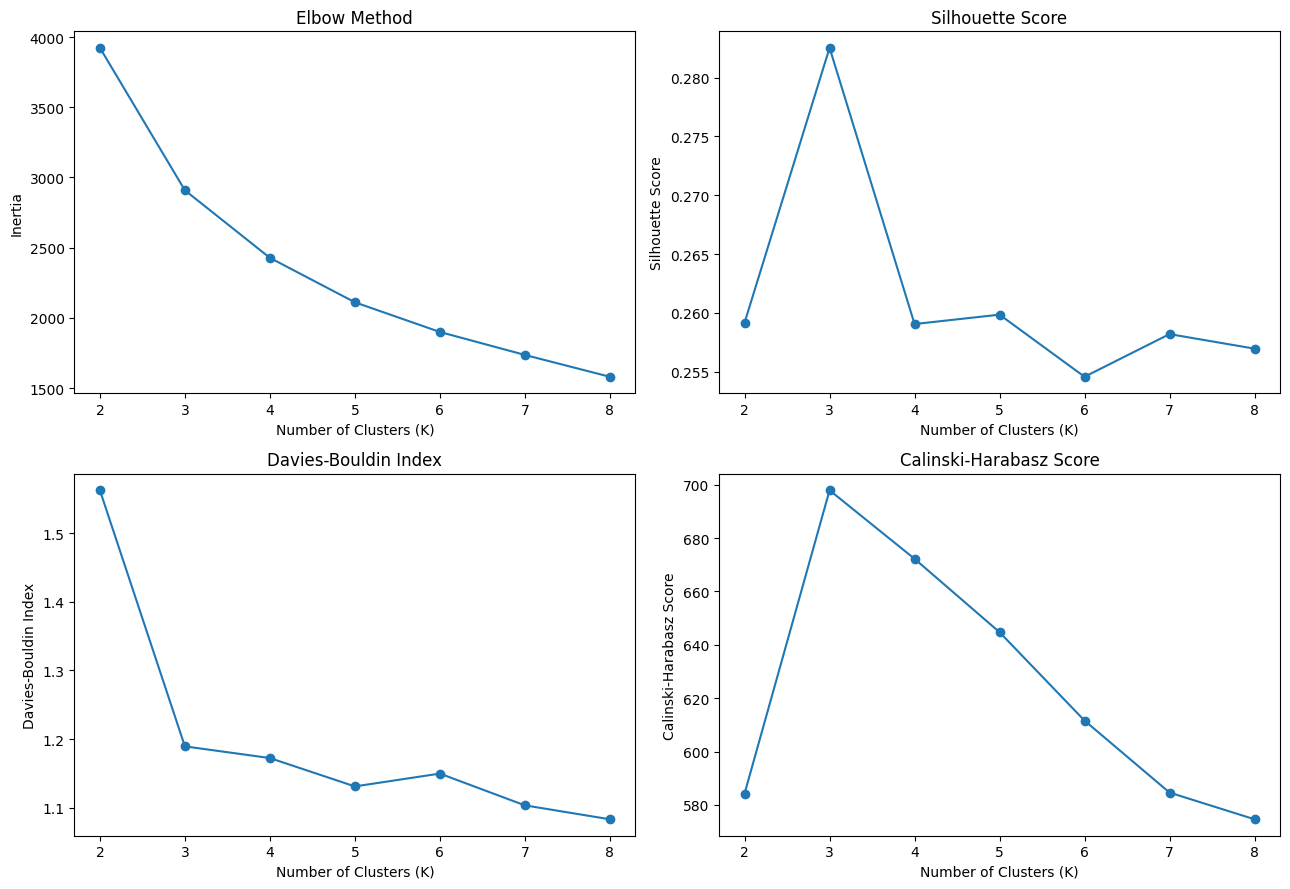


Metric leaders:
  Best silhouette score      : K=3
  Best Davies-Bouldin index  : K=8
  Best Calinski-Harabasz     : K=3

Important: the final K should not be selected from one metric alone.
We will compare these diagnostics with the elbow, cluster sizes and business interpretability.

Saved figure: /content/drive/MyDrive/greggs-growth-intelligence-system/figures/ml_cluster_selection.png

STATUS: Candidate cluster solutions evaluated.


In [ ]:
# SECTION 8.2 - Selecting the Number of Clusters

from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

print("SECTION 8.2 - Selecting the Number of Clusters")

# Test several possible numbers of clusters.
k_values = range(2, 9)

evaluation_results = []
cluster_size_records = []

for k in k_values:

    # Fit K-Means using the same random seed
    # so the experiment is reproducible.
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    cluster_labels = model.fit_predict(
        X_cluster_scaled
    )

    # Calculate clustering-quality metrics.
    inertia = model.inertia_

    silhouette = silhouette_score(
        X_cluster_scaled,
        cluster_labels
    )

    davies_bouldin = davies_bouldin_score(
        X_cluster_scaled,
        cluster_labels
    )

    calinski_harabasz = calinski_harabasz_score(
        X_cluster_scaled,
        cluster_labels
    )

    # Inspect the size of each resulting cluster.
    cluster_sizes = (
        pd.Series(cluster_labels)
        .value_counts()
        .sort_index()
    )

    smallest_cluster = cluster_sizes.min()
    largest_cluster = cluster_sizes.max()

    smallest_share = (
        smallest_cluster
        / len(cluster_labels)
        * 100
    )

    largest_share = (
        largest_cluster
        / len(cluster_labels)
        * 100
    )

    evaluation_results.append({
        "k": k,
        "inertia": inertia,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
        "smallest_cluster": smallest_cluster,
        "smallest_cluster_pct": smallest_share,
        "largest_cluster": largest_cluster,
        "largest_cluster_pct": largest_share
    })

    for cluster_id, size in cluster_sizes.items():

        cluster_size_records.append({
            "k": k,
            "cluster": cluster_id,
            "stores": size,
            "share_pct": (
                size / len(cluster_labels) * 100
            )
        })


# Create evaluation tables.
cluster_evaluation = pd.DataFrame(
    evaluation_results
)

cluster_sizes_all = pd.DataFrame(
    cluster_size_records
)

cluster_evaluation_display = (
    cluster_evaluation.copy()
)

cluster_evaluation_display[
    [
        "inertia",
        "silhouette",
        "davies_bouldin",
        "calinski_harabasz",
        "smallest_cluster_pct",
        "largest_cluster_pct"
    ]
] = (
    cluster_evaluation_display[
        [
            "inertia",
            "silhouette",
            "davies_bouldin",
            "calinski_harabasz",
            "smallest_cluster_pct",
            "largest_cluster_pct"
        ]
    ]
    .round(3)
)

print("\nCluster evaluation metrics:")
display(cluster_evaluation_display)


# Show the actual cluster sizes for each K.
cluster_size_table = (
    cluster_sizes_all
    .pivot(
        index="k",
        columns="cluster",
        values="stores"
    )
    .fillna(0)
    .astype(int)
)

print("\nCluster sizes:")
display(cluster_size_table)


# Plot the four diagnostic measures.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9)
)

axes[0, 0].plot(
    cluster_evaluation["k"],
    cluster_evaluation["inertia"],
    marker="o"
)

axes[0, 0].set_title(
    "Elbow Method"
)

axes[0, 0].set_xlabel(
    "Number of Clusters (K)"
)

axes[0, 0].set_ylabel(
    "Inertia"
)


axes[0, 1].plot(
    cluster_evaluation["k"],
    cluster_evaluation["silhouette"],
    marker="o"
)

axes[0, 1].set_title(
    "Silhouette Score"
)

axes[0, 1].set_xlabel(
    "Number of Clusters (K)"
)

axes[0, 1].set_ylabel(
    "Silhouette Score"
)


axes[1, 0].plot(
    cluster_evaluation["k"],
    cluster_evaluation["davies_bouldin"],
    marker="o"
)

axes[1, 0].set_title(
    "Davies-Bouldin Index"
)

axes[1, 0].set_xlabel(
    "Number of Clusters (K)"
)

axes[1, 0].set_ylabel(
    "Davies-Bouldin Index"
)


axes[1, 1].plot(
    cluster_evaluation["k"],
    cluster_evaluation["calinski_harabasz"],
    marker="o"
)

axes[1, 1].set_title(
    "Calinski-Harabasz Score"
)

axes[1, 1].set_xlabel(
    "Number of Clusters (K)"
)

axes[1, 1].set_ylabel(
    "Calinski-Harabasz Score"
)

for ax in axes.flat:
    ax.set_xticks(list(k_values))

plt.tight_layout()

CLUSTER_SELECTION_FIGURE = (
    FIGURES_DIR /
    "ml_cluster_selection.png"
)

plt.savefig(
    CLUSTER_SELECTION_FIGURE,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Highlight which K performs best on each direct metric.
best_silhouette_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["silhouette"].idxmax(),
        "k"
    ]
)

best_db_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["davies_bouldin"].idxmin(),
        "k"
    ]
)

best_ch_k = int(
    cluster_evaluation.loc[
        cluster_evaluation["calinski_harabasz"].idxmax(),
        "k"
    ]
)

print("\nMetric leaders:")

print(
    f"  Best silhouette score      : K={best_silhouette_k}"
)

print(
    f"  Best Davies-Bouldin index  : K={best_db_k}"
)

print(
    f"  Best Calinski-Harabasz     : K={best_ch_k}"
)

print(
    "\nImportant: the final K should not be selected "
    "from one metric alone."
)

print(
    "We will compare these diagnostics with the elbow, "
    "cluster sizes and business interpretability."
)

print(
    f"\nSaved figure: {CLUSTER_SELECTION_FIGURE}"
)

print(
    "\nSTATUS: Candidate cluster solutions evaluated."
)

### 8.3 Final K-Means Segmentation

The candidate-cluster evaluation favoured a three-cluster solution.

K=3 produced the highest silhouette score and Calinski-Harabasz score among the tested solutions, while maintaining three substantial and reasonably balanced groups. The elbow analysis also indicated diminishing improvements beyond approximately three to four clusters.

The final K-Means model is therefore initially fitted with three clusters.

Cluster numbers themselves have no inherent meaning. The resulting groups are profiled using socioeconomic, population, competition and geographic characteristics before descriptive strategic labels are assigned.

In [ ]:
# SECTION 8.3 - Final K-Means Model and Cluster Profiling

from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

print("SECTION 8.3 - Final K-Means Model and Cluster Profiling")

# Fit the selected three-cluster solution.
final_k = 3

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=20
)

cluster_labels = final_kmeans.fit_predict(
    X_cluster_scaled
)

# Attach cluster membership to the modelling dataset.
ml_clustered = ml_data.copy()

ml_clustered["cluster"] = cluster_labels


# Check the number of stores assigned to each cluster.
cluster_counts = (
    ml_clustered["cluster"]
    .value_counts()
    .sort_index()
)

cluster_shares = (
    cluster_counts
    / len(ml_clustered)
    * 100
).round(1)

cluster_distribution = pd.DataFrame({
    "stores": cluster_counts,
    "share_pct": cluster_shares
})

print("\nCluster distribution:")
display(cluster_distribution)


# Convert the cluster centres from standardised values
# back into the transformed feature scales.
centres_transformed = (
    cluster_scaler
    .inverse_transform(
        final_kmeans.cluster_centers_
    )
)

cluster_centres = pd.DataFrame(
    centres_transformed,
    columns=clustering_features
)

# Convert log-transformed variables back to intuitive units.
cluster_centres[
    "estimated_population"
] = np.expm1(
    cluster_centres["log_population"]
)

cluster_centres[
    "estimated_competitors_1km"
] = np.expm1(
    cluster_centres["log_competitors_1km"]
)

cluster_centres.index.name = "cluster"

centre_display = (
    cluster_centres[
        [
            "imd_score",
            "estimated_population",
            "estimated_competitors_1km"
        ]
    ]
    .round({
        "imd_score": 2,
        "estimated_population": 0,
        "estimated_competitors_1km": 2
    })
)

print("\nCluster centres:")
display(centre_display)


# Create detailed business profiles using original variables.
cluster_profiles = (
    ml_clustered
    .groupby("cluster")
    .agg(
        stores=("osm_id", "count"),

        mean_imd=("imd_score", "mean"),
        median_imd_decile=("imd_decile", "median"),

        mean_population=("total_population", "mean"),
        median_population=("total_population", "median"),

        mean_competitors_1km=(
            "competitors_within_1km",
            "mean"
        ),

        median_competitors_1km=(
            "competitors_within_1km",
            "median"
        ),

        mean_brand_diversity=(
            "brand_diversity_1km",
            "mean"
        ),

        median_nearest_competitor_km=(
            "nearest_competitor_distance_km",
            "median"
        ),

        urban_share=(
            "rural_urban",
            lambda x:
            (x == "Urban").mean() * 100
        )
    )
    .round(2)
)

print("\nCluster business profiles:")
display(cluster_profiles)


# Examine deprivation composition inside each cluster.
imd_composition = (
    pd.crosstab(
        ml_clustered["cluster"],
        ml_clustered["imd_decile"],
        normalize="index"
    )
    * 100
).round(1)

print("\nIMD decile composition within each cluster (%):")
display(imd_composition)


# Examine broad competition environments.
competition_composition = (
    pd.crosstab(
        ml_clustered["cluster"],
        ml_clustered["competition_environment"],
        normalize="index"
    )
    * 100
).round(1)

print("\nCompetition-environment composition (%):")
display(competition_composition)


# Examine urban/rural composition.
urban_composition = (
    pd.crosstab(
        ml_clustered["cluster"],
        ml_clustered["rural_urban"],
        normalize="index"
    )
    * 100
).round(1)

print("\nUrban/rural composition (%):")
display(urban_composition)


# Find the most common nearest competitor brand
# for each strategic cluster.
nearest_brand_profile = (
    ml_clustered
    .groupby("cluster")[
        "nearest_competitor_brand"
    ]
    .agg(
        lambda x:
        x.value_counts().index[0]
        if not x.dropna().empty
        else "Unknown"
    )
    .rename("most_common_nearest_brand")
)

print("\nMost common nearest competitor:")
display(
    nearest_brand_profile.to_frame()
)


# Find the most represented local authorities.
top_authorities = []

for cluster_id in sorted(
    ml_clustered["cluster"].unique()
):

    cluster_subset = ml_clustered[
        ml_clustered["cluster"] == cluster_id
    ]

    authorities = (
        cluster_subset[
            "local_authority"
        ]
        .value_counts()
        .head(8)
    )

    for authority, count in authorities.items():

        top_authorities.append({
            "cluster": cluster_id,
            "local_authority": authority,
            "stores": count
        })

top_authorities = pd.DataFrame(
    top_authorities
)

print("\nMost represented local authorities:")
display(top_authorities)


# Save the preliminary clustered dataset.
CLUSTERED_DATA_FILE = (
    PROCESSED_DIR /
    "greggs_kmeans_clusters_preliminary.parquet"
)

ml_clustered.to_parquet(
    CLUSTERED_DATA_FILE,
    index=False
)

print("\nSaved preliminary cluster dataset:")
print(CLUSTERED_DATA_FILE)

print(
    "\nSTATUS: Three-cluster K-Means model fitted and profiled."
)

SECTION 8.3 - Final K-Means Model and Cluster Profiling

Cluster distribution:


,stores,share_pct
cluster,,
0,504,28.9
1,791,45.3
2,451,25.8



Cluster centres:


,imd_score,estimated_population,estimated_competitors_1km
cluster,,,
0,21.43,2234.0,7.81
1,19.06,1620.0,1.41
2,51.77,1711.0,3.24



Cluster business profiles:


...


Most common nearest competitor:


,most_common_nearest_brand
cluster,
0,Costa Coffee
1,Costa Coffee
2,Costa Coffee



Most represented local authorities:


,cluster,local_authority,stores
0,0,Manchester,18
1,0,Birmingham,16
2,0,Leeds,15
3,0,Newcastle upon Tyne,15
4,0,Liverpool,14
5,0,Westminster,12
6,0,"Bristol, City of",10
7,0,Nottingham,9
8,1,Leeds,26
9,1,Birmingham,18



Saved preliminary cluster dataset:
/content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_kmeans_clusters_preliminary.parquet

STATUS: Three-cluster K-Means model fitted and profiled.


### 8.4 Strategic Cluster Interpretation

The three-cluster solution produces distinct store-market profiles that can be translated into business-oriented strategic segments.

**Competitive Urban Hubs** operate in relatively populous areas with the highest concentration and diversity of nearby competitors. These locations represent dense commercial environments where Greggs competes alongside multiple food-to-go and quick-service brands.

**Lower-Competition Local Markets** form the largest segment. These stores generally operate in less competitively dense areas and have lower surrounding population than the Competitive Urban Hub segment.

**High-Deprivation Urban Core** locations are almost entirely urban and are strongly concentrated within the most deprived English neighbourhoods. Competition remains present but is substantially lower than in the Competitive Urban Hub segment.

The segment labels are descriptive rather than prescriptive. Cluster membership describes the market environment surrounding each store and does not by itself indicate store performance or expansion potential.

SECTION 8.4 - Strategic Cluster Interpretation and Visualisation

Strategic segment summary:


,cluster,segment,stores,mean_imd,median_imd_decile,mean_population,mean_competitors_1km,median_competitors_1km,mean_brand_diversity,median_nearest_competitor_m,urban_share_pct,network_share_pct
0,0,Competitive Urban Hubs,504,21.43,5.0,2329.0,11.19,6.0,4.31,48.9,91.7,28.9
1,1,Lower-Competition Local Markets,791,19.06,5.0,1647.0,1.90,1.0,1.63,95.2,82.2,45.3
2,2,High-Deprivation Urban Core,451,51.77,1.0,1743.0,4.27,4.0,2.87,85.4,99.1,25.8


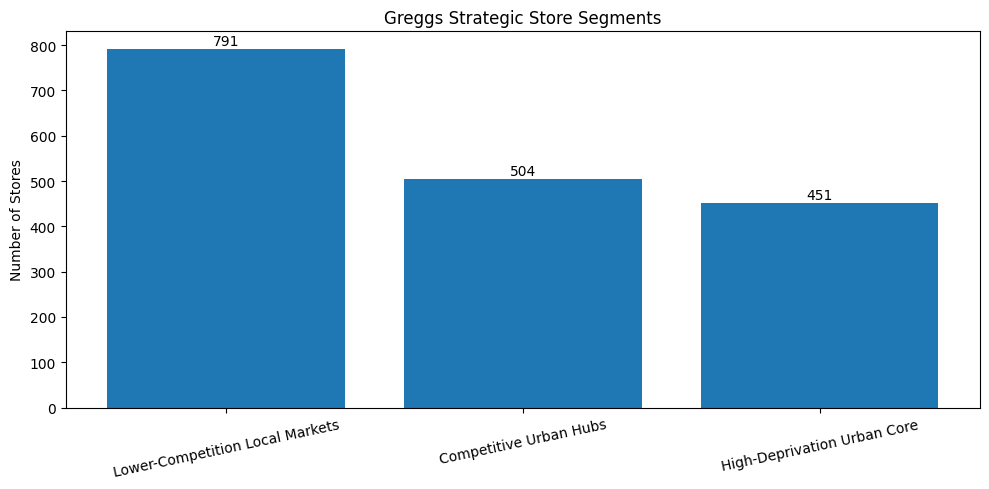

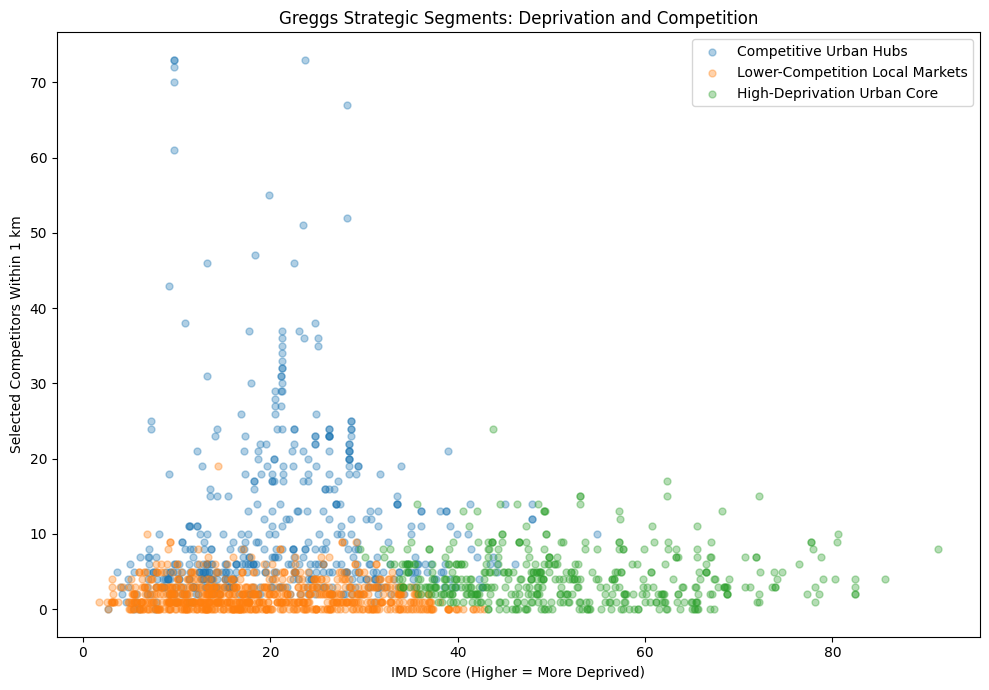

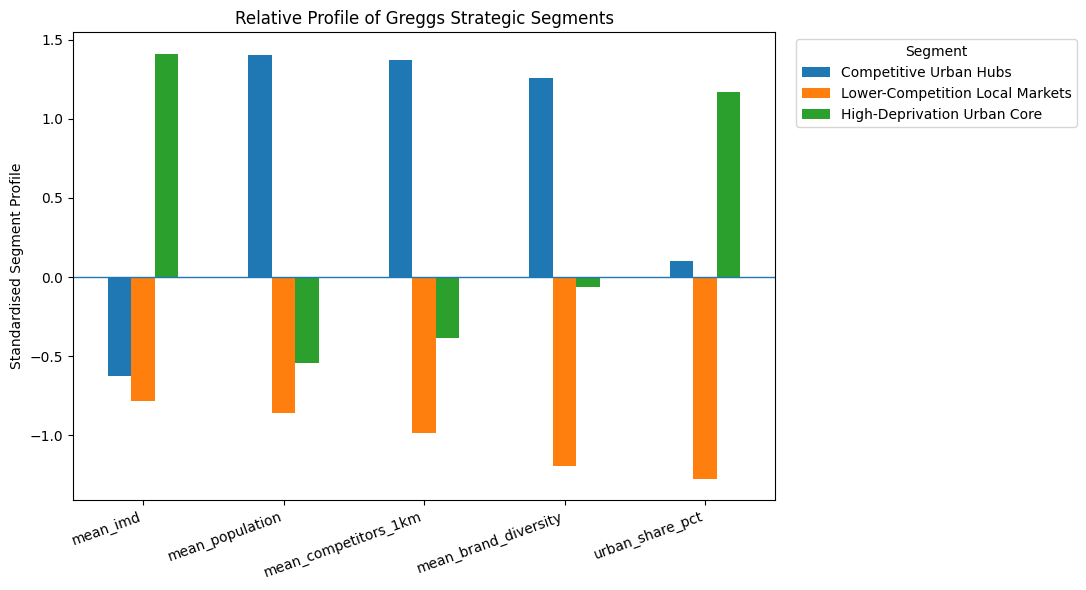


Saved strategic segment summary:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/strategic_segment_summary.csv

Saved segmented store dataset:
/content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_kmeans_segments.parquet

Saved figures:
/content/drive/MyDrive/greggs-growth-intelligence-system/figures/ml_strategic_segment_sizes.png
/content/drive/MyDrive/greggs-growth-intelligence-system/figures/ml_segments_deprivation_competition.png
/content/drive/MyDrive/greggs-growth-intelligence-system/figures/ml_segment_profile_comparison.png

STATUS: Strategic cluster interpretation complete.


In [ ]:
# SECTION 8.4 - Strategic Cluster Interpretation and Visualisation

print("SECTION 8.4 - Strategic Cluster Interpretation and Visualisation")

# Give each mathematical cluster a meaningful business label.
cluster_label_map = {
    0: "Competitive Urban Hubs",
    1: "Lower-Competition Local Markets",
    2: "High-Deprivation Urban Core"
}

ml_clustered["segment"] = (
    ml_clustered["cluster"]
    .map(cluster_label_map)
)

# Confirm that every store received a segment label.
if ml_clustered["segment"].isna().any():
    raise ValueError(
        "Some cluster values do not have a strategic segment label."
    )


# Create a concise strategic profile table.
segment_summary = (
    ml_clustered
    .groupby(["cluster", "segment"])
    .agg(
        stores=("osm_id", "count"),

        mean_imd=("imd_score", "mean"),

        median_imd_decile=(
            "imd_decile",
            "median"
        ),

        mean_population=(
            "total_population",
            "mean"
        ),

        mean_competitors_1km=(
            "competitors_within_1km",
            "mean"
        ),

        median_competitors_1km=(
            "competitors_within_1km",
            "median"
        ),

        mean_brand_diversity=(
            "brand_diversity_1km",
            "mean"
        ),

        median_nearest_competitor_m=(
            "nearest_competitor_distance_km",
            lambda x: x.median() * 1000
        ),

        urban_share_pct=(
            "rural_urban",
            lambda x: (x == "Urban").mean() * 100
        )
    )
    .reset_index()
)

segment_summary["network_share_pct"] = (
    segment_summary["stores"]
    / len(ml_clustered)
    * 100
)

segment_summary = segment_summary.round({
    "mean_imd": 2,
    "mean_population": 0,
    "mean_competitors_1km": 2,
    "median_competitors_1km": 1,
    "mean_brand_diversity": 2,
    "median_nearest_competitor_m": 1,
    "urban_share_pct": 1,
    "network_share_pct": 1
})

print("\nStrategic segment summary:")
display(segment_summary)


# Add concise descriptions for later use in
# Power BI, README and portfolio documentation.
segment_descriptions = {
    "Competitive Urban Hubs":
        "High-population locations operating in dense, highly competitive commercial environments.",

    "Lower-Competition Local Markets":
        "Locations characterised by lower surrounding competitive intensity and smaller local population.",

    "High-Deprivation Urban Core":
        "Predominantly urban locations strongly concentrated in England's most deprived neighbourhoods."
}

segment_summary["description"] = (
    segment_summary["segment"]
    .map(segment_descriptions)
)


# Visual 1: Segment size
fig, ax = plt.subplots(figsize=(10, 5))

segment_order = (
    segment_summary
    .sort_values("stores", ascending=False)
)

bars = ax.bar(
    segment_order["segment"],
    segment_order["stores"]
)

ax.set_title(
    "Greggs Strategic Store Segments"
)

ax.set_ylabel(
    "Number of Stores"
)

ax.set_xlabel(
    ""
)

ax.tick_params(
    axis="x",
    rotation=12
)

for bar, value in zip(
    bars,
    segment_order["stores"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 10,
        f"{int(value):,}",
        ha="center"
    )

plt.tight_layout()

SEGMENT_SIZE_FIGURE = (
    FIGURES_DIR /
    "ml_strategic_segment_sizes.png"
)

plt.savefig(
    SEGMENT_SIZE_FIGURE,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Visual 2: Deprivation versus local competition
fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, segment_name in cluster_label_map.items():

    cluster_data = ml_clustered[
        ml_clustered["cluster"] == cluster_id
    ]

    ax.scatter(
        cluster_data["imd_score"],
        cluster_data["competitors_within_1km"],
        alpha=0.35,
        s=25,
        label=segment_name
    )

ax.set_title(
    "Greggs Strategic Segments: Deprivation and Competition"
)

ax.set_xlabel(
    "IMD Score (Higher = More Deprived)"
)

ax.set_ylabel(
    "Selected Competitors Within 1 km"
)

ax.legend()

plt.tight_layout()

SEGMENT_SCATTER_FIGURE = (
    FIGURES_DIR /
    "ml_segments_deprivation_competition.png"
)

plt.savefig(
    SEGMENT_SCATTER_FIGURE,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Visual 3: Segment-level comparison
comparison_metrics = (
    segment_summary
    .set_index("segment")[
        [
            "mean_imd",
            "mean_population",
            "mean_competitors_1km",
            "mean_brand_diversity",
            "urban_share_pct"
        ]
    ]
)

# Standardise the segment-level metrics only for visual comparison.
comparison_scaled = (
    comparison_metrics
    - comparison_metrics.mean()
) / comparison_metrics.std(ddof=0)

fig, ax = plt.subplots(figsize=(11, 6))

comparison_scaled.T.plot(
    kind="bar",
    ax=ax
)

ax.set_title(
    "Relative Profile of Greggs Strategic Segments"
)

ax.set_ylabel(
    "Standardised Segment Profile"
)

ax.set_xlabel(
    ""
)

ax.axhline(
    0,
    linewidth=1
)

ax.legend(
    title="Segment",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

SEGMENT_PROFILE_FIGURE = (
    FIGURES_DIR /
    "ml_segment_profile_comparison.png"
)

plt.savefig(
    SEGMENT_PROFILE_FIGURE,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Save the segment summary.
SEGMENT_SUMMARY_FILE = (
    EXPORTS_DIR /
    "strategic_segment_summary.csv"
)

segment_summary.to_csv(
    SEGMENT_SUMMARY_FILE,
    index=False
)


# Save store-level cluster assignments.
CLUSTERED_FINAL_FILE = (
    PROCESSED_DIR /
    "greggs_kmeans_segments.parquet"
)

ml_clustered.to_parquet(
    CLUSTERED_FINAL_FILE,
    index=False
)

print("\nSaved strategic segment summary:")
print(SEGMENT_SUMMARY_FILE)

print("\nSaved segmented store dataset:")
print(CLUSTERED_FINAL_FILE)

print("\nSaved figures:")
print(SEGMENT_SIZE_FIGURE)
print(SEGMENT_SCATTER_FIGURE)
print(SEGMENT_PROFILE_FIGURE)

print("\nSTATUS: Strategic cluster interpretation complete.")

### 8.5 Cluster Stability Assessment

Because K-Means can be sensitive to its initial centroid positions, the robustness of the selected three-cluster solution is assessed across repeated model initialisations.

The Adjusted Rand Index (ARI) is used to compare each repeated clustering solution against the final three-cluster model. ARI measures agreement between two cluster assignments while accounting for chance and is unaffected by arbitrary differences in cluster numbering.

In addition to cluster agreement, inertia and silhouette scores are monitored across repeated runs. A stable solution should produce broadly consistent cluster memberships and clustering-quality metrics across different random initialisations.

SECTION 8.5 - Cluster Stability Assessment

Stability summary:


,adjusted_rand_index,inertia,silhouette
mean,0.9978,2908.6179,0.2826
std,0.0030,0.0028,0.0001
min,0.9918,2908.6148,0.2825
max,1.0000,2908.6300,0.2829



Lowest-agreement runs:


,random_seed,adjusted_rand_index,inertia,silhouette
7,7,0.9918,2908.6148,0.2829
8,8,0.9918,2908.6148,0.2829
24,24,0.9918,2908.6148,0.2829
23,23,0.9918,2908.6148,0.2829
27,27,0.9918,2908.6148,0.2829
11,11,0.9973,2908.6164,0.2826
6,6,0.9973,2908.6164,0.2826
1,1,0.9973,2908.6164,0.2826
17,17,0.9973,2908.6164,0.2826
19,19,0.9973,2908.6164,0.2826



Runs with ARI >= 0.95 : 30 / 30
Mean ARI              : 0.9978
Minimum ARI           : 0.9918


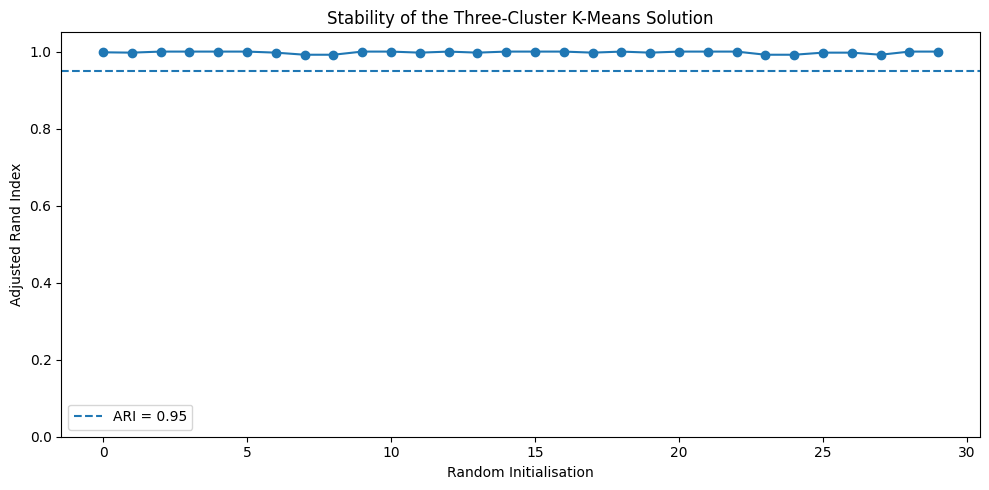


Saved stability results:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/cluster_stability_results.csv

Saved stability figure:
/content/drive/MyDrive/greggs-growth-intelligence-system/figures/ml_cluster_stability.png

STATUS: Cluster stability assessment complete.


In [ ]:
# SECTION 8.5 - Cluster Stability Assessment
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_score
)
print("SECTION 8.5 - Cluster Stability Assessment")

# Use the final K=3 solution as the reference clustering.
reference_labels = ml_clustered["cluster"].values

stability_results = []

# Refit K-Means using multiple independent random seeds.
for seed in range(30):

    stability_model = KMeans(
        n_clusters=3,
        random_state=seed,
        n_init=20
    )

    repeated_labels = stability_model.fit_predict(
        X_cluster_scaled
    )

    ari = adjusted_rand_score(
        reference_labels,
        repeated_labels
    )

    silhouette = silhouette_score(
        X_cluster_scaled,
        repeated_labels
    )

    stability_results.append({
        "random_seed": seed,
        "adjusted_rand_index": ari,
        "inertia": stability_model.inertia_,
        "silhouette": silhouette
    })


# Create results table.
stability_df = pd.DataFrame(
    stability_results
)

print("\nStability summary:")

stability_summary = (
    stability_df[
        [
            "adjusted_rand_index",
            "inertia",
            "silhouette"
        ]
    ]
    .describe()
    .loc[
        ["mean", "std", "min", "max"]
    ]
    .round(4)
)

display(stability_summary)


# Show individual runs with the lowest agreement.
print("\nLowest-agreement runs:")

display(
    stability_df
    .sort_values(
        "adjusted_rand_index"
    )
    .head(10)
    .round(4)
)


# Count how often the repeated solution is effectively identical.
highly_stable_runs = (
    stability_df[
        "adjusted_rand_index"
    ] >= 0.95
).sum()

print(
    f"\nRuns with ARI >= 0.95 : "
    f"{highly_stable_runs} / {len(stability_df)}"
)

print(
    f"Mean ARI              : "
    f"{stability_df['adjusted_rand_index'].mean():.4f}"
)

print(
    f"Minimum ARI           : "
    f"{stability_df['adjusted_rand_index'].min():.4f}"
)


# Visualise agreement across repeated initialisations.
fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    stability_df["random_seed"],
    stability_df["adjusted_rand_index"],
    marker="o"
)

ax.axhline(
    y=0.95,
    linestyle="--",
    label="ARI = 0.95"
)

ax.set_title(
    "Stability of the Three-Cluster K-Means Solution"
)

ax.set_xlabel(
    "Random Initialisation"
)

ax.set_ylabel(
    "Adjusted Rand Index"
)

ax.set_ylim(
    0,
    1.05
)

ax.legend()

plt.tight_layout()

STABILITY_FIGURE = (
    FIGURES_DIR /
    "ml_cluster_stability.png"
)

plt.savefig(
    STABILITY_FIGURE,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Save stability results for documentation.
STABILITY_RESULTS_FILE = (
    EXPORTS_DIR /
    "cluster_stability_results.csv"
)

stability_df.to_csv(
    STABILITY_RESULTS_FILE,
    index=False
)

print("\nSaved stability results:")
print(STABILITY_RESULTS_FILE)

print("\nSaved stability figure:")
print(STABILITY_FIGURE)

print(
    "\nSTATUS: Cluster stability assessment complete."
)

## 9. Strategic Market Context & Action Framework

The clustering analysis identifies different types of Greggs market environments, but cluster membership alone does not indicate whether a location represents an attractive growth, defensive or monitoring priority.

A separate strategic prioritisation layer is therefore developed.

Rather than constructing a single opportunity score from arbitrary fixed weights, the analysis retains three interpretable dimensions:

- **Market scale** — relative local population size
- **Competitive pressure** — intensity and proximity of selected major competitors
- **Deprivation context** — relative socioeconomic deprivation of the store location

Percentile ranks are used so that variables measured on different scales can be compared consistently from 0 to 100.

Competitive pressure combines competitor density with proximity to the nearest major competitor. A high value therefore represents locations facing both greater surrounding competition and/or closer competitors.

These dimensions will subsequently be used to construct strategic market profiles rather than being interpreted as predictions of store sales or profitability.

### 9.1 Strategic Dimension Engineering

The preceding geographic, socioeconomic and competition features are translated into three interpretable strategic dimensions: market scale, competitive pressure and deprivation context.

These indices summarise different characteristics of each existing English Greggs location on comparable scales. They are used for market-context interpretation rather than as predictions of store profitability or future expansion success.

In [ ]:
# SECTION 9.1 - Strategic Dimension Engineering
print("SECTION 9.1 - Strategic Dimension Engineering")
strategy_df = ml_clustered.copy()

# Convert the main strategic variables into percentile ranks.
# Percentiles make variables with different units comparable.

strategy_df["market_scale_pct"] = (
    strategy_df["total_population"]
    .rank(method="average", pct=True)
    * 100
)

strategy_df["competition_density_pct"] = (
    strategy_df["competitors_within_1km"]
    .rank(method="average", pct=True)
    * 100
)

strategy_df["nearest_distance_pct"] = (
    strategy_df["nearest_competitor_distance_km"]
    .rank(method="average", pct=True)
    * 100
)

strategy_df["deprivation_context_pct"] = (
    strategy_df["imd_score"]
    .rank(method="average", pct=True)
    * 100
)


# Smaller competitor distance means greater competitive pressure.
strategy_df["competitor_proximity_pressure_pct"] = (
    100 - strategy_df["nearest_distance_pct"]
)
# Competitive pressure combines two complementary ideas:
# how many competitors surround the store
# and how close the nearest major competitor is.

strategy_df["competitive_pressure_index"] = (
    strategy_df[
        [
            "competition_density_pct",
            "competitor_proximity_pressure_pct"
        ]
    ]
    .mean(axis=1)
)
# Market scale is retained separately rather than mixed
# into an arbitrary overall opportunity score.
strategy_df["market_scale_index"] = (
    strategy_df["market_scale_pct"]
)


# Keep deprivation as a separate strategic context dimension.
strategy_df["deprivation_context_index"] = (
    strategy_df["deprivation_context_pct"]
)


# Round analytical indices for readability.
index_columns = [
    "market_scale_index",
    "competition_density_pct",
    "competitor_proximity_pressure_pct",
    "competitive_pressure_index",
    "deprivation_context_index"
]

strategy_df[index_columns] = (
    strategy_df[index_columns]
    .round(2)
)

# Summarise the new strategic dimensions.
dimension_summary = (
    strategy_df[
        [
            "market_scale_index",
            "competitive_pressure_index",
            "deprivation_context_index"
        ]
    ]
    .describe()
    .T[
        [
            "mean",
            "std",
            "min",
            "25%",
            "50%",
            "75%",
            "max"
        ]
    ]
    .round(2)
)

print("\nStrategic dimension summary:")
display(dimension_summary)

# Check the two components used in competitive pressure.
pressure_components = (
    strategy_df[
        [
            "competitors_within_1km",
            "nearest_competitor_distance_km",
            "competition_density_pct",
            "competitor_proximity_pressure_pct",
            "competitive_pressure_index"
        ]
    ]
    .corr()
    .round(3)
)

print("\nCompetitive-pressure component relationships:")
display(pressure_components)

# Compare strategic dimensions across the three K-Means segments.
segment_strategy_profile = (
    strategy_df
    .groupby("segment")
    .agg(
        stores=("osm_id", "count"),

        avg_market_scale=(
            "market_scale_index",
            "mean"
        ),

        avg_competitive_pressure=(
            "competitive_pressure_index",
            "mean"
        ),

        avg_deprivation_context=(
            "deprivation_context_index",
            "mean"
        ),

        median_competitors_1km=(
            "competitors_within_1km",
            "median"
        ),

        median_nearest_competitor_m=(
            "nearest_competitor_distance_km",
            lambda x: x.median() * 1000
        )
    )
    .round(2)
)

print("\nStrategic dimensions by K-Means segment:")
display(segment_strategy_profile)


# Validate index ranges.
validation_summary = pd.DataFrame({
    "dimension": [
        "Market scale",
        "Competitive pressure",
        "Deprivation context"
    ],

    "minimum": [
        strategy_df["market_scale_index"].min(),
        strategy_df["competitive_pressure_index"].min(),
        strategy_df["deprivation_context_index"].min()
    ],

    "maximum": [
        strategy_df["market_scale_index"].max(),
        strategy_df["competitive_pressure_index"].max(),
        strategy_df["deprivation_context_index"].max()
    ],

    "missing": [
        strategy_df["market_scale_index"].isna().sum(),
        strategy_df["competitive_pressure_index"].isna().sum(),
        strategy_df["deprivation_context_index"].isna().sum()
    ]
}).round(2)

print("\nValidation:")
display(validation_summary)


# Save the strategic analytical dataset.
STRATEGY_DATA_FILE = (
    PROCESSED_DIR /
    "greggs_strategic_dimensions.parquet"
)

strategy_df.to_parquet(
    STRATEGY_DATA_FILE,
    index=False
)

print("\nSaved strategic dataset:")
print(STRATEGY_DATA_FILE)

print(
    "\nSTATUS: Strategic dimensions created."
)

SECTION 9.1 - Strategic Dimension Engineering

Strategic dimension summary:


,mean,std,min,25%,50%,75%,max
market_scale_index,50.03,28.88,0.06,24.94,50.03,75.00,100.00
competitive_pressure_index,50.00,24.33,3.32,34.00,54.40,68.42,98.65
deprivation_context_index,50.03,28.88,0.06,25.05,50.03,75.02,100.00



Competitive-pressure component relationships:


,competitors_within_1km,nearest_competitor_distance_km,competition_density_pct,competitor_proximity_pressure_pct,competitive_pressure_index
competitors_within_1km,1.000,-0.198,0.691,0.219,0.537
nearest_competitor_distance_km,-0.198,1.000,-0.423,-0.504,-0.549
competition_density_pct,0.691,-0.423,1.000,0.430,0.844
competitor_proximity_pressure_pct,0.219,-0.504,0.430,1.000,0.847
competitive_pressure_index,0.537,-0.549,0.844,0.847,1.000



Strategic dimensions by K-Means segment:


,stores,avg_market_scale,avg_competitive_pressure,avg_deprivation_context,median_competitors_1km,median_nearest_competitor_m
segment,,,,,,
Competitive Urban Hubs,504,74.33,67.35,40.72,6.0,48.93
High-Deprivation Urban Core,451,44.91,50.43,86.25,4.0,85.41
Lower-Competition Local Markets,791,37.47,38.70,35.30,1.0,95.24



Validation:


,dimension,minimum,maximum,missing
0,Market scale,0.06,100.00,0
1,Competitive pressure,3.32,98.65,0
2,Deprivation context,0.06,100.00,0



Saved strategic dataset:
/content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_strategic_dimensions.parquet

STATUS: Strategic dimensions created.


### 9.2 Strategic Market Matrix

The market-scale and competitive-pressure dimensions are combined into a two-dimensional strategic matrix.

Rather than imposing arbitrary fixed thresholds, the median value of each dimension across the analytical network is used to distinguish relatively higher and lower market environments.

This produces four store-market contexts:

- **Large-Market Lower-Pressure** — relatively large surrounding populations with below-median competitive pressure
- **Large-Market Competitive** — relatively large surrounding populations combined with above-median competitive pressure
- **Local Lower-Pressure** — smaller local population environments with below-median competitive pressure
- **Smaller-Market Competitive** — smaller local population environments facing above-median competitive pressure

These categories describe the external context surrounding existing Greggs stores. They should not be interpreted as direct measures of store profitability or as confirmed recommendations for new-store expansion.

The market-scale measure is based on LSOA population and should therefore be interpreted as a local demographic indicator rather than a complete retail catchment or footfall measure.

SECTION 9.2 - Strategic Market Matrix

Data-derived thresholds:
  Market scale median          : 50.03
  Competitive pressure median  : 54.40

Strategic market-context distribution:


,market_context,stores,network_share_pct
0,Large-Market Competitive,475,27.2
1,Local Lower-Pressure,473,27.1
2,Smaller-Market Competitive,400,22.9
3,Large-Market Lower-Pressure,398,22.8



Strategic context profiles:


,stores,avg_market_scale,avg_competitive_pressure,avg_deprivation_context,mean_imd,median_imd_decile,mean_population,median_competitors_1km,median_nearest_competitor_m,urban_share_pct
market_context,,,,,,,,,,
Large-Market Competitive,475,77.06,70.71,49.70,27.63,4.0,2322.99,6.0,32.96,90.32
Large-Market Lower-Pressure,398,72.61,32.60,48.83,27.59,4.0,2143.18,2.0,199.67,88.19
Local Lower-Pressure,473,26.08,28.02,50.01,28.40,4.0,1512.2,1.0,375.96,89.64
Smaller-Market Competitive,400,23.79,68.72,51.64,29.22,4.0,1477.45,5.0,26.70,88.75



Market context within each K-Means segment (%):


market_context,Large-Market Competitive,Large-Market Lower-Pressure,Local Lower-Pressure,Smaller-Market Competitive
segment,,,,
Competitive Urban Hubs,65.3,21.2,0.0,13.5
High-Deprivation Urban Core,20.4,21.5,27.7,30.4
Lower-Competition Local Markets,6.8,24.5,44.0,24.7


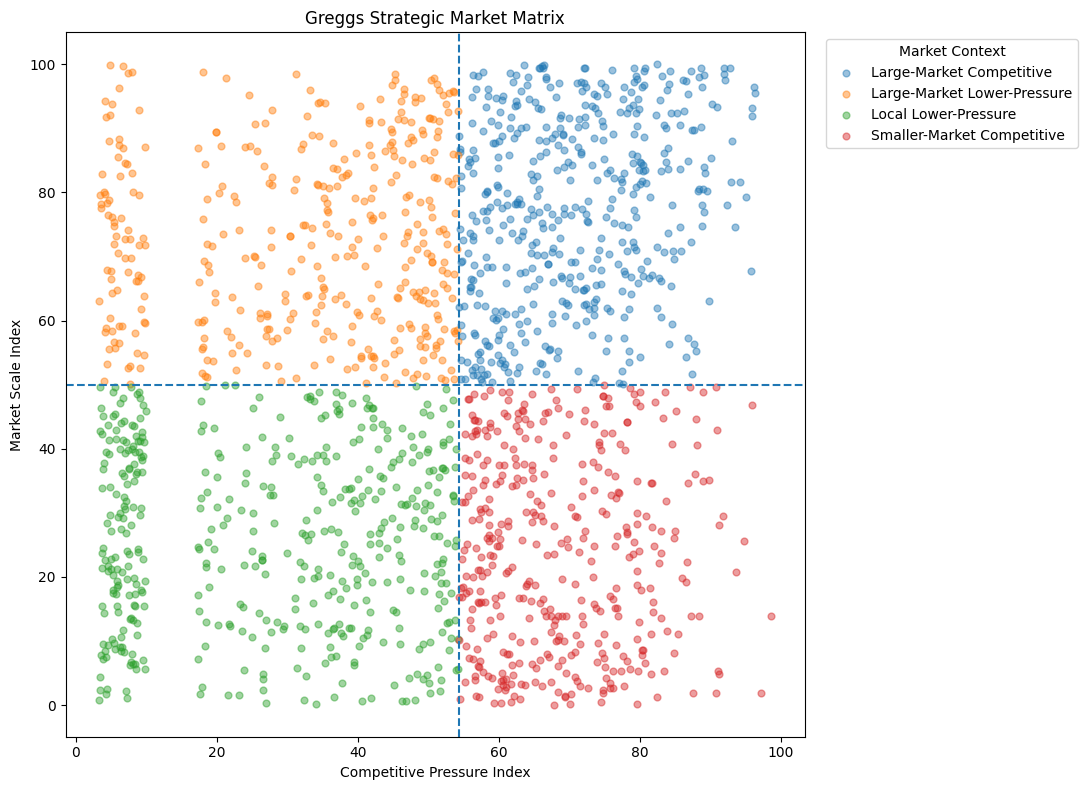


Saved strategic market dataset:
/content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_strategic_market_matrix.parquet

Saved strategic context summary:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/strategic_market_context_summary.csv

Saved figure:
/content/drive/MyDrive/greggs-growth-intelligence-system/figures/strategic_market_matrix.png

STATUS: Strategic market matrix created.


In [ ]:
# SECTION 9.2 - Strategic Market Matrix
print("SECTION 9.2 - Strategic Market Matrix")

matrix_df = strategy_df.copy()

# Use observed network medians as relative thresholds.
market_threshold = (
    matrix_df["market_scale_index"].median()
)

competition_threshold = (
    matrix_df["competitive_pressure_index"].median()
)

print("\nData-derived thresholds:")
print(
    f"  Market scale median          : "
    f"{market_threshold:.2f}"
)
print(
    f"  Competitive pressure median  : "
    f"{competition_threshold:.2f}"
)


# Assign each existing store to one strategic context.
def assign_market_context(row):

    high_market = (
        row["market_scale_index"]
        >= market_threshold
    )

    high_competition = (
        row["competitive_pressure_index"]
        >= competition_threshold
    )

    if high_market and not high_competition:
        return "Large-Market Lower-Pressure"

    if high_market and high_competition:
        return "Large-Market Competitive"

    if not high_market and not high_competition:
        return "Local Lower-Pressure"

    return "Smaller-Market Competitive"


matrix_df["market_context"] = (
    matrix_df.apply(
        assign_market_context,
        axis=1
    )
)


# Review the distribution of strategic contexts.
context_distribution = (
    matrix_df["market_context"]
    .value_counts()
    .rename_axis("market_context")
    .reset_index(name="stores")
)

context_distribution["network_share_pct"] = (
    context_distribution["stores"]
    / len(matrix_df)
    * 100
).round(1)

print("\nStrategic market-context distribution:")
display(context_distribution)


# Profile each context using original business variables.
context_profile = (
    matrix_df
    .groupby("market_context")
    .agg(
        stores=("osm_id", "count"),

        avg_market_scale=(
            "market_scale_index",
            "mean"
        ),

        avg_competitive_pressure=(
            "competitive_pressure_index",
            "mean"
        ),

        avg_deprivation_context=(
            "deprivation_context_index",
            "mean"
        ),

        mean_imd=(
            "imd_score",
            "mean"
        ),

        median_imd_decile=(
            "imd_decile",
            "median"
        ),

        mean_population=(
            "total_population",
            "mean"
        ),

        median_competitors_1km=(
            "competitors_within_1km",
            "median"
        ),

        median_nearest_competitor_m=(
            "nearest_competitor_distance_km",
            lambda x: x.median() * 1000
        ),

        urban_share_pct=(
            "rural_urban",
            lambda x:
            (x == "Urban").mean() * 100
        )
    )
    .round(2)
)

print("\nStrategic context profiles:")
display(context_profile)


# Compare K-Means segments with the new strategic matrix.
segment_context_cross = (
    pd.crosstab(
        matrix_df["segment"],
        matrix_df["market_context"],
        normalize="index"
    )
    * 100
).round(1)

print("\nMarket context within each K-Means segment (%):")
display(segment_context_cross)


# Plot the strategic matrix.
fig, ax = plt.subplots(
    figsize=(11, 8)
)

for context in sorted(
    matrix_df["market_context"].unique()
):

    subset = matrix_df[
        matrix_df["market_context"] == context
    ]

    ax.scatter(
        subset["competitive_pressure_index"],
        subset["market_scale_index"],
        alpha=0.45,
        s=24,
        label=context
    )


# Add median decision boundaries.
ax.axvline(
    competition_threshold,
    linestyle="--",
    linewidth=1.5
)

ax.axhline(
    market_threshold,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "Greggs Strategic Market Matrix"
)

ax.set_xlabel(
    "Competitive Pressure Index"
)

ax.set_ylabel(
    "Market Scale Index"
)

ax.legend(
    title="Market Context",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

MARKET_MATRIX_FIGURE = (
    FIGURES_DIR /
    "strategic_market_matrix.png"
)

plt.savefig(
    MARKET_MATRIX_FIGURE,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Save the contextualised analytical dataset.
MARKET_MATRIX_FILE = (
    PROCESSED_DIR /
    "greggs_strategic_market_matrix.parquet"
)

matrix_df.to_parquet(
    MARKET_MATRIX_FILE,
    index=False
)


# Save the summary table for reporting and Power BI.
MARKET_CONTEXT_SUMMARY_FILE = (
    EXPORTS_DIR /
    "strategic_market_context_summary.csv"
)

context_profile.to_csv(
    MARKET_CONTEXT_SUMMARY_FILE
)
print("\nSaved strategic market dataset:")
print(MARKET_MATRIX_FILE)

print("\nSaved strategic context summary:")
print(MARKET_CONTEXT_SUMMARY_FILE)

print("\nSaved figure:")
print(MARKET_MATRIX_FIGURE)

print(
    "\nSTATUS: Strategic market matrix created."
)

### 9.3 Strategic Action Framework

The four market contexts are translated into business-oriented strategic categories to make the analytical results easier to interpret.

The categories do not represent predictions of store profitability or formal expansion recommendations. Instead, they indicate how existing Greggs locations differ in terms of relative local market scale and competitive pressure.

- **Growth Benchmark Context** identifies larger-market locations operating under comparatively lower competitive pressure.
- **Defend & Differentiate** identifies larger markets where Greggs operates alongside relatively intense major-brand competition.
- **Local Coverage** identifies smaller local markets with comparatively lower competitive pressure.
- **Competitive Exposure** identifies smaller-market environments facing relatively high competitive pressure.

The framework provides a transparent bridge between the analytical results and later business-intelligence reporting without requiring an arbitrary weighted opportunity score.

SECTION 9.3 - Strategic Action Framework

Strategic action distribution:


,strategic_action,stores,network_share_pct
0,Defend & Differentiate,475,27.2
1,Local Coverage,473,27.1
2,Competitive Exposure,400,22.9
3,Growth Benchmark Context,398,22.8



Strategic action profiles:


,stores,avg_market_scale,avg_competitive_pressure,avg_deprivation_context,mean_population,mean_imd,median_imd_decile,median_competitors_1km,median_nearest_competitor_m
strategic_action,,,,,,,,,
Competitive Exposure,400,23.79,68.72,51.64,1477.45,29.22,4.0,5.0,26.70
Defend & Differentiate,475,77.06,70.71,49.70,2322.99,27.63,4.0,6.0,32.96
Growth Benchmark Context,398,72.61,32.60,48.83,2143.18,27.59,4.0,2.0,199.67
Local Coverage,473,26.08,28.02,50.01,1512.2,28.40,4.0,1.0,375.96



Local authorities containing at least 3 Growth Benchmark Context stores:


,stores,avg_market_scale,avg_competitive_pressure,avg_imd,avg_population
local_authority,,,,,
Birmingham,20,70.45,28.63,43.92,2064.4
Leeds,9,62.32,25.47,31.11,1918.67
Northumberland,7,82.74,34.16,24.57,2309.29
Westmorland and Furness,7,69.57,27.13,10.73,2019.86
Trafford,7,68.79,33.25,13.16,2041.29
Newcastle upon Tyne,7,67.95,27.81,44.26,2036.71
Wiltshire,6,67.03,17.56,20.35,1983.33
West Suffolk,5,82.29,32.93,18.24,2299.2
Sunderland,5,81.29,45.07,46.54,2441.4



Strategic action within each K-Means segment (%):


strategic_action,Competitive Exposure,Defend & Differentiate,Growth Benchmark Context,Local Coverage
segment,,,,
Competitive Urban Hubs,13.5,65.3,21.2,0.0
High-Deprivation Urban Core,30.4,20.4,21.5,27.7
Lower-Competition Local Markets,24.7,6.8,24.5,44.0


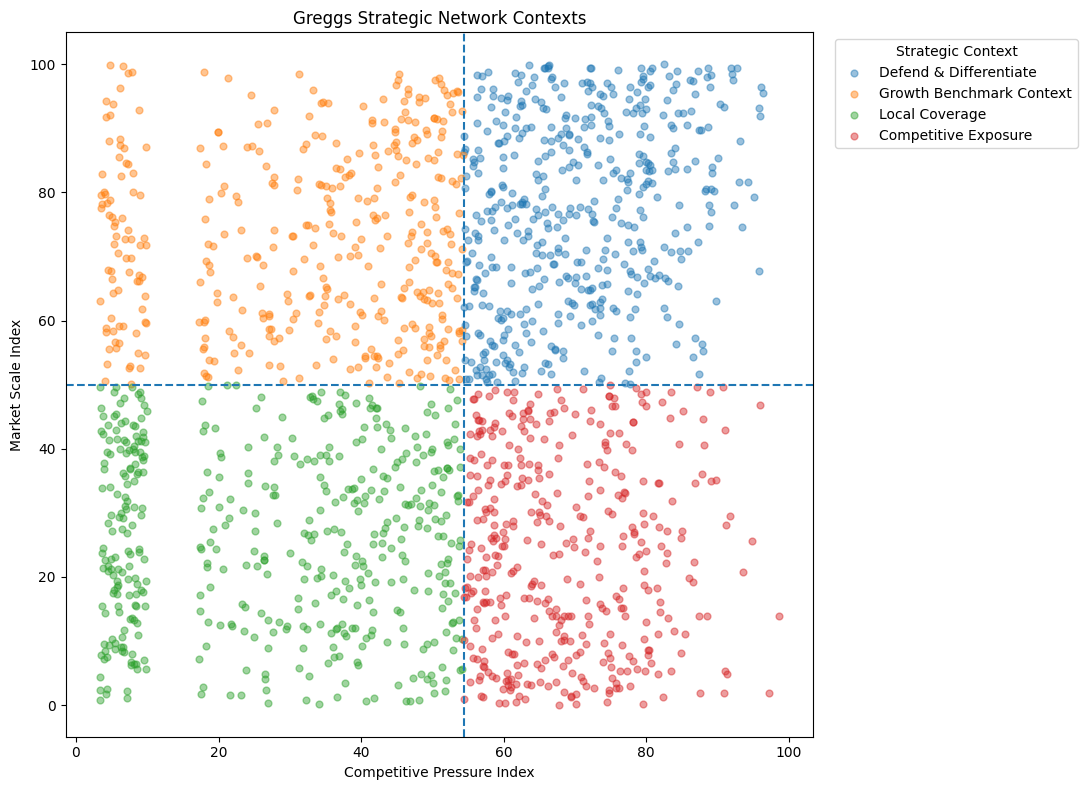


Saved strategic analytical dataset:
/content/drive/MyDrive/greggs-growth-intelligence-system/data/processed/greggs_strategic_actions.parquet

Saved strategic action summary:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/strategic_action_summary.csv

Saved local-authority benchmark summary:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/growth_benchmark_local_authorities.csv

Saved figure:
/content/drive/MyDrive/greggs-growth-intelligence-system/figures/strategic_action_matrix.png

STATUS: Strategic action framework complete.


In [ ]:
# SECTION 9.3 - Strategic Action Framework
print("SECTION 9.3 - Strategic Action Framework")

strategic_df = matrix_df.copy()


# Translate each analytical market context
# into a business-oriented strategic category.
action_map = {
    "Large-Market Lower-Pressure":
        "Growth Benchmark Context",

    "Large-Market Competitive":
        "Defend & Differentiate",

    "Local Lower-Pressure":
        "Local Coverage",

    "Smaller-Market Competitive":
        "Competitive Exposure"
}

strategic_df["strategic_action"] = (
    strategic_df["market_context"]
    .map(action_map)
)


# Add a concise explanation for Power BI
# and portfolio documentation.
action_description_map = {
    "Growth Benchmark Context":
        "Large local market with comparatively lower major-brand competitive pressure.",

    "Defend & Differentiate":
        "Large market operating under comparatively high major-brand competitive pressure.",

    "Local Coverage":
        "Smaller local market with comparatively lower competitive pressure.",

    "Competitive Exposure":
        "Smaller local market facing comparatively high major-brand competitive pressure."
}

strategic_df["strategic_action_description"] = (
    strategic_df["strategic_action"]
    .map(action_description_map)
)


# Validate that every store received a category.
missing_actions = (
    strategic_df["strategic_action"]
    .isna()
    .sum()
)

if missing_actions > 0:
    raise ValueError(
        f"{missing_actions} stores are missing a strategic action label."
    )


# Network distribution.
action_distribution = (
    strategic_df["strategic_action"]
    .value_counts()
    .rename_axis("strategic_action")
    .reset_index(name="stores")
)

action_distribution["network_share_pct"] = (
    action_distribution["stores"]
    / len(strategic_df)
    * 100
).round(1)

print("\nStrategic action distribution:")
display(action_distribution)


# Profile each strategic category.
action_profile = (
    strategic_df
    .groupby("strategic_action")
    .agg(
        stores=("osm_id", "count"),

        avg_market_scale=(
            "market_scale_index",
            "mean"
        ),

        avg_competitive_pressure=(
            "competitive_pressure_index",
            "mean"
        ),

        avg_deprivation_context=(
            "deprivation_context_index",
            "mean"
        ),

        mean_population=(
            "total_population",
            "mean"
        ),

        mean_imd=(
            "imd_score",
            "mean"
        ),

        median_imd_decile=(
            "imd_decile",
            "median"
        ),

        median_competitors_1km=(
            "competitors_within_1km",
            "median"
        ),

        median_nearest_competitor_m=(
            "nearest_competitor_distance_km",
            lambda x: x.median() * 1000
        )
    )
    .round(2)
)

print("\nStrategic action profiles:")
display(action_profile)


# Identify local authorities with the largest
# number of Growth Benchmark Context stores.
growth_context = strategic_df[
    strategic_df["strategic_action"]
    == "Growth Benchmark Context"
].copy()

growth_authorities = (
    growth_context
    .groupby("local_authority")
    .agg(
        stores=("osm_id", "count"),

        avg_market_scale=(
            "market_scale_index",
            "mean"
        ),

        avg_competitive_pressure=(
            "competitive_pressure_index",
            "mean"
        ),

        avg_imd=(
            "imd_score",
            "mean"
        ),

        avg_population=(
            "total_population",
            "mean"
        )
    )
    .query("stores >= 3")
    .sort_values(
        ["stores", "avg_market_scale"],
        ascending=[False, False]
    )
    .round(2)
)

print(
    "\nLocal authorities containing at least "
    "3 Growth Benchmark Context stores:"
)

display(
    growth_authorities.head(20)
)


# Compare strategic actions with K-Means segments.
segment_action_matrix = (
    pd.crosstab(
        strategic_df["segment"],
        strategic_df["strategic_action"],
        normalize="index"
    )
    * 100
).round(1)

print("\nStrategic action within each K-Means segment (%):")
display(segment_action_matrix)


# Visualise the four strategic contexts.
fig, ax = plt.subplots(
    figsize=(11, 8)
)

for action in strategic_df[
    "strategic_action"
].unique():

    subset = strategic_df[
        strategic_df["strategic_action"] == action
    ]

    ax.scatter(
        subset["competitive_pressure_index"],
        subset["market_scale_index"],
        alpha=0.45,
        s=24,
        label=action
    )


# Retain the data-derived matrix boundaries.
ax.axvline(
    competition_threshold,
    linestyle="--",
    linewidth=1.5
)

ax.axhline(
    market_threshold,
    linestyle="--",
    linewidth=1.5
)

ax.set_title(
    "Greggs Strategic Network Contexts"
)

ax.set_xlabel(
    "Competitive Pressure Index"
)

ax.set_ylabel(
    "Market Scale Index"
)

ax.legend(
    title="Strategic Context",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

ACTION_MATRIX_FIGURE = (
    FIGURES_DIR /
    "strategic_action_matrix.png"
)

plt.savefig(
    ACTION_MATRIX_FIGURE,
    dpi=150,
    bbox_inches="tight"
)

plt.show()


# Save the analytical dataset.
STRATEGIC_ACTION_FILE = (
    PROCESSED_DIR /
    "greggs_strategic_actions.parquet"
)

strategic_df.to_parquet(
    STRATEGIC_ACTION_FILE,
    index=False
)


# Save summaries for reporting and Power BI.
ACTION_SUMMARY_FILE = (
    EXPORTS_DIR /
    "strategic_action_summary.csv"
)

action_profile.to_csv(
    ACTION_SUMMARY_FILE
)

GROWTH_CONTEXT_FILE = (
    EXPORTS_DIR /
    "growth_benchmark_local_authorities.csv"
)

growth_authorities.to_csv(
    GROWTH_CONTEXT_FILE
)


print("\nSaved strategic analytical dataset:")
print(STRATEGIC_ACTION_FILE)

print("\nSaved strategic action summary:")
print(ACTION_SUMMARY_FILE)

print("\nSaved local-authority benchmark summary:")
print(GROWTH_CONTEXT_FILE)

print("\nSaved figure:")
print(ACTION_MATRIX_FIGURE)

print(
    "\nSTATUS: Strategic action framework complete."
)

### 9.4 Local Authority Strategic Profile

Strategic contexts are aggregated to local-authority level to examine how Greggs' existing network differs geographically.

Using absolute store counts alone can disproportionately highlight large Greggs markets. The analysis therefore reports both the number and proportion of stores assigned to each strategic context.

Local authorities containing fewer than five analysed Greggs stores are excluded from comparative ranking tables to reduce the influence of very small local samples.

These profiles describe the composition of Greggs' existing network and should not be interpreted as direct rankings of locations for new-store expansion.

In [ ]:
# SECTION 9.4 - Local Authority Strategic Profile
print("SECTION 9.4 - Local Authority Strategic Profile")

la_df = (
    strategic_df
    .dropna(subset=["local_authority"])
    .copy()
)

# Create the base local-authority profile.
la_profile = (
    la_df
    .groupby("local_authority")
    .agg(
        total_stores=("osm_id", "count"),

        avg_market_scale=(
            "market_scale_index",
            "mean"
        ),

        avg_competitive_pressure=(
            "competitive_pressure_index",
            "mean"
        ),

        avg_deprivation_context=(
            "deprivation_context_index",
            "mean"
        ),

        avg_imd_score=(
            "imd_score",
            "mean"
        ),

        avg_population=(
            "total_population",
            "mean"
        ),

        median_competitors_1km=(
            "competitors_within_1km",
            "median"
        )
    )
)


# Count stores in each strategic category.
action_counts = pd.crosstab(
    la_df["local_authority"],
    la_df["strategic_action"]
)

required_actions = [
    "Growth Benchmark Context",
    "Defend & Differentiate",
    "Local Coverage",
    "Competitive Exposure"
]

action_counts = action_counts.reindex(
    columns=required_actions,
    fill_value=0
)

action_counts = action_counts.rename(
    columns={
        "Growth Benchmark Context":
            "growth_benchmark_stores",

        "Defend & Differentiate":
            "defend_differentiate_stores",

        "Local Coverage":
            "local_coverage_stores",

        "Competitive Exposure":
            "competitive_exposure_stores"
    }
)


# Join strategic counts to the area profile.
la_profile = (
    la_profile
    .join(action_counts)
    .reset_index()
)


# Calculate the share of each local network.
la_profile["growth_benchmark_share_pct"] = (
    la_profile["growth_benchmark_stores"]
    / la_profile["total_stores"]
    * 100
)

la_profile["defend_differentiate_share_pct"] = (
    la_profile["defend_differentiate_stores"]
    / la_profile["total_stores"]
    * 100
)

la_profile["local_coverage_share_pct"] = (
    la_profile["local_coverage_stores"]
    / la_profile["total_stores"]
    * 100
)

la_profile["competitive_exposure_share_pct"] = (
    la_profile["competitive_exposure_stores"]
    / la_profile["total_stores"]
    * 100
)


# Identify the most common strategic context
# within each local authority.
share_columns = {
    "growth_benchmark_share_pct":
        "Growth Benchmark Context",

    "defend_differentiate_share_pct":
        "Defend & Differentiate",

    "local_coverage_share_pct":
        "Local Coverage",

    "competitive_exposure_share_pct":
        "Competitive Exposure"
}

la_profile["dominant_strategic_context"] = (
    la_profile[
        list(share_columns.keys())
    ]
    .idxmax(axis=1)
    .map(share_columns)
)


# Round numerical fields for reporting.
numeric_columns = [
    "avg_market_scale",
    "avg_competitive_pressure",
    "avg_deprivation_context",
    "avg_imd_score",
    "avg_population",
    "median_competitors_1km",
    "growth_benchmark_share_pct",
    "defend_differentiate_share_pct",
    "local_coverage_share_pct",
    "competitive_exposure_share_pct"
]

la_profile[numeric_columns] = (
    la_profile[numeric_columns]
    .round(2)
)


# Use authorities with at least five analysed stores
# for comparative rankings.
la_comparison = (
    la_profile[
        la_profile["total_stores"] >= 5
    ]
    .copy()
)

print(
    f"\nLocal authorities represented: "
    f"{len(la_profile)}"
)

print(
    f"Authorities with at least 5 stores: "
    f"{len(la_comparison)}"
)


# Areas with the strongest concentration
# of Growth Benchmark Context stores.
benchmark_leaders = (
    la_comparison
    .sort_values(
        [
            "growth_benchmark_share_pct",
            "growth_benchmark_stores",
            "avg_market_scale"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    [[
        "local_authority",
        "total_stores",
        "growth_benchmark_stores",
        "growth_benchmark_share_pct",
        "avg_market_scale",
        "avg_competitive_pressure",
        "avg_imd_score"
    ]]
    .head(20)
)

print(
    "\nHighest Growth Benchmark Context "
    "concentration:"
)

display(benchmark_leaders)


# Areas where a large share of the Greggs network
# operates in more competitive strategic contexts.
defensive_leaders = (
    la_comparison
    .sort_values(
        [
            "defend_differentiate_share_pct",
            "defend_differentiate_stores",
            "avg_competitive_pressure"
        ],
        ascending=[
            False,
            False,
            False
        ]
    )
    [[
        "local_authority",
        "total_stores",
        "defend_differentiate_stores",
        "defend_differentiate_share_pct",
        "avg_market_scale",
        "avg_competitive_pressure",
        "avg_imd_score"
    ]]
    .head(20)
)

print(
    "\nHighest Defend & Differentiate "
    "concentration:"
)

display(defensive_leaders)


# Review the dominant strategic context by authority.
dominant_context_summary = (
    la_comparison[
        "dominant_strategic_context"
    ]
    .value_counts()
    .rename_axis(
        "dominant_strategic_context"
    )
    .reset_index(
        name="local_authorities"
    )
)

print(
    "\nDominant strategic context "
    "across local authorities:"
)

display(dominant_context_summary)


# Save the full local-authority table.
LA_STRATEGY_FILE = (
    EXPORTS_DIR /
    "local_authority_strategic_profile.csv"
)

la_profile.to_csv(
    LA_STRATEGY_FILE,
    index=False
)

print("\nSaved local-authority strategic profile:")
print(LA_STRATEGY_FILE)

print(
    "\nSTATUS: Local-authority strategic profiling complete."
)

SECTION 9.4 - Local Authority Strategic Profile

Local authorities represented: 284
Authorities with at least 5 stores: 137

Highest Growth Benchmark Context concentration:


,local_authority,total_stores,growth_benchmark_stores,growth_benchmark_share_pct,avg_market_scale,avg_competitive_pressure,avg_imd_score
183,Redbridge,6,5,83.33,71.24,35.13,21.78
70,Ealing,6,5,83.33,70.21,29.77,31.23
68,Dover,6,4,66.67,59.05,43.15,43.45
184,Redcar and Cleveland,5,3,60.00,72.38,52.05,44.94
249,Trafford,12,7,58.33,51.19,37.62,18.88
267,West Suffolk,10,5,50.00,59.12,39.30,15.97
156,Newham,8,4,50.00,69.01,54.38,32.19
178,Peterborough,9,4,44.44,65.97,42.14,29.49
118,Huntingdonshire,9,4,44.44,50.91,35.38,14.96
7,Barnsley,9,4,44.44,46.50,39.89,32.03



Highest Defend & Differentiate concentration:


,local_authority,total_stores,defend_differentiate_stores,defend_differentiate_share_pct,avg_market_scale,avg_competitive_pressure,avg_imd_score
39,Camden,9,8,88.89,67.79,84.63,25.76
52,City of London,7,6,85.71,80.29,82.26,11.07
117,Hounslow,10,8,80.00,73.10,56.81,28.84
268,Westminster,13,10,76.92,60.54,78.44,19.67
9,Basingstoke and Deane,7,5,71.43,63.61,57.55,15.11
101,Hammersmith and Fulham,6,4,66.67,57.02,67.04,25.14
125,Kingston upon Thames,6,4,66.67,61.50,56.54,13.35
150,Milton Keynes,8,5,62.50,68.08,65.37,26.38
189,Rochdale,5,3,60.00,68.21,62.60,48.51
142,Mansfield,5,3,60.00,59.54,61.73,45.30



Dominant strategic context across local authorities:


,dominant_strategic_context,local_authorities
0,Defend & Differentiate,56
1,Growth Benchmark Context,35
2,Local Coverage,30
3,Competitive Exposure,16



Saved local-authority strategic profile:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/local_authority_strategic_profile.csv

STATUS: Local-authority strategic profiling complete.


### 9.5 Final Strategic Findings

The preceding analyses are consolidated into a final set of evidence-based findings describing the structure of the English Greggs analytical network.

The findings combine geographic coverage, socioeconomic context, local competitor proximity, statistical testing, K-Means segmentation and the strategic market matrix.

They describe patterns within the existing Greggs network rather than predicting store-level sales, profitability or confirmed expansion opportunities.

Where local-authority rankings are used for headline interpretation, larger network bases are preferred because percentages calculated from very small store counts can be unstable.

In [ ]:
# SECTION 9.5 - Final Strategic Findings
print("SECTION 9.5 - Final Strategic Findings")

findings_df = strategic_df.copy()


# Core network metrics

total_england_stores = len(findings_df)

urban_share = (
    findings_df["rural_urban"]
    .eq("Urban")
    .mean()
    * 100
)

high_deprivation_share = (
    findings_df["imd_decile"]
    .le(3)
    .mean()
    * 100
)

low_deprivation_share = (
    findings_df["imd_decile"]
    .ge(8)
    .mean()
    * 100
)

median_nearest_competitor_m = (
    findings_df[
        "nearest_competitor_distance_km"
    ]
    .median()
    * 1000
)

median_competitors_1km = (
    findings_df[
        "competitors_within_1km"
    ]
    .median()
)


# Largest K-Means segment

segment_counts = (
    findings_df["segment"]
    .value_counts()
)

largest_segment = (
    segment_counts.index[0]
)

largest_segment_stores = (
    segment_counts.iloc[0]
)

largest_segment_share = (
    largest_segment_stores
    / total_england_stores
    * 100
)


# Strategic action distribution

action_counts = (
    findings_df[
        "strategic_action"
    ]
    .value_counts()
)

largest_action = (
    action_counts.index[0]
)

largest_action_stores = (
    action_counts.iloc[0]
)

largest_action_share = (
    largest_action_stores
    / total_england_stores
    * 100
)


# Use authorities with at least 10 stores
# for more robust headline comparisons.

headline_authorities = (
    la_profile[
        la_profile["total_stores"] >= 10
    ]
    .copy()
)


top_benchmark_authority = (
    headline_authorities
    .sort_values(
        [
            "growth_benchmark_share_pct",
            "growth_benchmark_stores"
        ],
        ascending=False
    )
    .iloc[0]
)


top_defensive_authority = (
    headline_authorities
    .sort_values(
        [
            "defend_differentiate_share_pct",
            "defend_differentiate_stores"
        ],
        ascending=False
    )
    .iloc[0]
)


# Build one concise evidence table.

strategic_findings = pd.DataFrame([
    {
        "finding":
            "England analytical network",

        "value":
            f"{total_england_stores:,} stores",

        "interpretation":
            "Stores with complete England socioeconomic, geographic and competition data."
    },

    {
        "finding":
            "Urban network concentration",

        "value":
            f"{urban_share:.1f}% urban",

        "interpretation":
            "Greggs' English network is strongly concentrated in urban locations."
    },

    {
        "finding":
            "Higher-deprivation representation",

        "value":
            f"{high_deprivation_share:.1f}% in IMD deciles 1-3",

        "interpretation":
            "Higher-deprivation areas are strongly represented within the existing network."
    },

    {
        "finding":
            "Lower-deprivation representation",

        "value":
            f"{low_deprivation_share:.1f}% in IMD deciles 8-10",

        "interpretation":
            "The least-deprived areas account for a substantially smaller share of stores."
    },

    {
        "finding":
            "Nearest major competitor",

        "value":
            f"{median_nearest_competitor_m:.0f} m median distance",

        "interpretation":
            "Major food-to-go competition is typically located very close to Greggs stores."
    },

    {
        "finding":
            "Local competition density",

        "value":
            f"{median_competitors_1km:.0f} competitors within 1 km",

        "interpretation":
            "The typical Greggs location operates alongside several selected major competitors."
    },

    {
        "finding":
            "Largest strategic segment",

        "value":
            (
                f"{largest_segment}: "
                f"{largest_segment_stores:,} stores "
                f"({largest_segment_share:.1f}%)"
            ),

        "interpretation":
            "K-Means identifies this as the most common structural store environment."
    },

    {
        "finding":
            "Largest strategic action context",

        "value":
            (
                f"{largest_action}: "
                f"{largest_action_stores:,} stores "
                f"({largest_action_share:.1f}%)"
            ),

        "interpretation":
            "This is the most common market-scale and competition context across the analytical network."
    },

    {
        "finding":
            "Growth Benchmark concentration",

        "value":
            (
                f"{top_benchmark_authority['local_authority']} "
                f"{top_benchmark_authority['growth_benchmark_share_pct']:.1f}% "
                f"({int(top_benchmark_authority['growth_benchmark_stores'])}"
                f"/{int(top_benchmark_authority['total_stores'])} stores)"
            ),

        "interpretation":
            "Highest Growth Benchmark concentration among authorities containing at least 10 analysed stores."
    },

    {
        "finding":
            "Defend & Differentiate concentration",

        "value":
            (
                f"{top_defensive_authority['local_authority']} "
                f"{top_defensive_authority['defend_differentiate_share_pct']:.1f}% "
                f"({int(top_defensive_authority['defend_differentiate_stores'])}"
                f"/{int(top_defensive_authority['total_stores'])} stores)"
            ),

        "interpretation":
            "Highest competitive large-market concentration among authorities containing at least 10 analysed stores."
    }
])


print("\nFinal strategic findings:")
display(strategic_findings)


# Add the statistical findings already established
# in Section 7.

statistical_takeaways = pd.DataFrame({
    "finding": [
        "Urban versus rural deprivation",
        "Urban versus rural competition",
        "Deprivation and competition association",
        "Competition across deprivation groups",
        "K-Means stability"
    ],

    "result": [
        "Urban stores have substantially higher mean IMD scores than rural stores.",
        "Urban stores generally operate in more competitive local environments.",
        "Deprivation has only a weak positive association with local competition density.",
        "Competition differs statistically across deprivation groups, but the overall effect is small.",
        "Three-cluster solution is highly stable across repeated random initialisations."
    ]
})

print("\nStatistical and modelling conclusions:")
display(statistical_takeaways)


# Save findings for later documentation
# and dashboard development.

STRATEGIC_FINDINGS_FILE = (
    EXPORTS_DIR /
    "final_strategic_findings.csv"
)

strategic_findings.to_csv(
    STRATEGIC_FINDINGS_FILE,
    index=False
)

STATISTICAL_TAKEAWAYS_FILE = (
    EXPORTS_DIR /
    "final_statistical_takeaways.csv"
)

statistical_takeaways.to_csv(
    STATISTICAL_TAKEAWAYS_FILE,
    index=False
)


print("\nSaved strategic findings:")
print(STRATEGIC_FINDINGS_FILE)

print("\nSaved statistical takeaways:")
print(STATISTICAL_TAKEAWAYS_FILE)

print(
    "\nSTATUS: Strategic analysis complete."
)

SECTION 9.5 - Final Strategic Findings

Final strategic findings:


,finding,value,interpretation
0,England analytical network,"1,746 stores","Stores with complete England socioeconomic, ge..."
1,Urban network concentration,89.3% urban,Greggs' English network is strongly concentrat...
2,Higher-deprivation representation,45.4% in IMD deciles 1-3,Higher-deprivation areas are strongly represen...
3,Lower-deprivation representation,15.2% in IMD deciles 8-10,The least-deprived areas account for a substan...
4,Nearest major competitor,73 m median distance,Major food-to-go competition is typically loca...
5,Local competition density,3 competitors within 1 km,The typical Greggs location operates alongside...
6,Largest strategic segment,Lower-Competition Local Markets: 791 stores (4...,K-Means identifies this as the most common str...
7,Largest strategic action context,Defend & Differentiate: 475 stores (27.2%),This is the most common market-scale and compe...
8,Growth Benchmark concentration,Trafford 58.3% (7/12 stores),Highest Growth Benchmark concentration among a...
9,Defend & Differentiate concentration,Hounslow 80.0% (8/10 stores),Highest competitive large-market concentration...



Statistical and modelling conclusions:


,finding,result
0,Urban versus rural deprivation,Urban stores have substantially higher mean IM...
1,Urban versus rural competition,Urban stores generally operate in more competi...
2,Deprivation and competition association,Deprivation has only a weak positive associati...
3,Competition across deprivation groups,Competition differs statistically across depri...
4,K-Means stability,Three-cluster solution is highly stable across...



Saved strategic findings:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/final_strategic_findings.csv

Saved statistical takeaways:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/final_statistical_takeaways.csv

STATUS: Strategic analysis complete.


## 10. Power BI Data Preparation

### 10.1 Power BI Master Dataset

The final analytical outputs are consolidated into a single store-level dataset designed for Power BI.

The master dataset preserves the complete UK Greggs network. Geographic and local competition features are available across the UK, while socioeconomic, deprivation, clustering and strategic-context variables are available for English stores where the required official data sources apply.

Additional display and grouping fields are created to simplify filtering, mapping and visualisation in Power BI.

The resulting dataset provides one consistent source for the final interactive dashboard.

In [ ]:
# SECTION 10.1 - Power BI Master Dataset
print("SECTION 10.1 - Power BI Master Dataset")


# Load the final UK analytical dataset created earlier.
UK_FINAL_FILE = (
    FINAL_DIR /
    "greggs_intelligence_uk.parquet"
)

uk_master = pd.read_parquet(
    UK_FINAL_FILE
).copy()

print(
    f"\nUK stores loaded: "
    f"{len(uk_master):,}"
)


# Keep the final England-only modelling and
# strategy variables generated in Sections 8 and 9.
strategy_columns = [
    "osm_id",
    "cluster",
    "segment",
    "market_scale_index",
    "competitive_pressure_index",
    "deprivation_context_index",
    "market_context",
    "strategic_action",
    "strategic_action_description"
]

available_strategy_columns = [
    column
    for column in strategy_columns
    if column in strategic_df.columns
]

strategy_lookup = (
    strategic_df[
        available_strategy_columns
    ]
    .drop_duplicates(
        subset="osm_id"
    )
    .copy()
)


# Remove any previous versions of strategic fields
# before merging the final versions.
strategy_fields = [
    column
    for column in strategy_lookup.columns
    if column != "osm_id"
]

existing_strategy_fields = [
    column
    for column in strategy_fields
    if column in uk_master.columns
]

if existing_strategy_fields:
    uk_master = uk_master.drop(
        columns=existing_strategy_fields
    )


# Add final England strategy outputs
# to the complete UK store network.
powerbi_df = uk_master.merge(
    strategy_lookup,
    on="osm_id",
    how="left",
    validate="one_to_one"
)


# Create a clear analytical scope field.
powerbi_df["analysis_scope"] = np.where(
    powerbi_df["country"].eq("England"),
    "England strategic analytics",
    "UK geography and competition"
)


# Create convenient display fields without
# overwriting the original source variables.
powerbi_df["city_display"] = (
    powerbi_df["city"]
    .fillna("Unknown")
    .astype(str)
)

powerbi_df["postcode_display"] = (
    powerbi_df["geography_postcode"]
    .fillna("Unknown")
    .astype(str)
)


# Convert competitor distance into metres
# for easier dashboard interpretation.
powerbi_df[
    "nearest_competitor_distance_m"
] = (
    powerbi_df[
        "nearest_competitor_distance_km"
    ]
    * 1000
).round(1)


# Create deprivation groups consistent
# with the statistical analysis.
def assign_deprivation_group(decile):

    if pd.isna(decile):
        return "Not available"

    if decile <= 3:
        return "Higher Deprivation (1-3)"

    if decile <= 7:
        return "Middle (4-7)"

    return "Lower Deprivation (8-10)"


powerbi_df["deprivation_group"] = (
    powerbi_df["imd_decile"]
    .apply(assign_deprivation_group)
)


# Add simple binary fields useful for
# Power BI measures and filtering.
powerbi_df["has_competitor_within_500m"] = (
    powerbi_df["competitors_within_500m"] > 0
)

powerbi_df["has_competitor_within_1km"] = (
    powerbi_df["competitors_within_1km"] > 0
)

powerbi_df["is_england_analytical_store"] = (
    powerbi_df["country"].eq("England")
    & powerbi_df["imd_score"].notna()
)


# Create ordering columns so Power BI
# categories can be sorted logically.
deprivation_order = {
    "Higher Deprivation (1-3)": 1,
    "Middle (4-7)": 2,
    "Lower Deprivation (8-10)": 3,
    "Not available": 4
}

powerbi_df["deprivation_group_order"] = (
    powerbi_df["deprivation_group"]
    .map(deprivation_order)
)


action_order = {
    "Growth Benchmark Context": 1,
    "Defend & Differentiate": 2,
    "Local Coverage": 3,
    "Competitive Exposure": 4
}

powerbi_df["strategic_action_order"] = (
    powerbi_df["strategic_action"]
    .map(action_order)
)


# Put the most useful dashboard fields first.
priority_columns = [
    "osm_id",
    "name",
    "country",
    "city_display",
    "postcode_display",
    "local_authority",
    "lat",
    "lon",
    "analysis_scope",
    "is_england_analytical_store",

    "rural_urban",
    "imd_score",
    "imd_decile",
    "deprivation_group",
    "deprivation_group_order",
    "income_score",
    "employment_score",
    "crime_score",
    "total_population",

    "nearest_competitor_brand",
    "nearest_competitor_distance_km",
    "nearest_competitor_distance_m",
    "competitors_within_500m",
    "competitors_within_1km",
    "brand_diversity_500m",
    "brand_diversity_1km",
    "competition_environment",
    "dominant_competitor_1km",
    "has_competitor_within_500m",
    "has_competitor_within_1km",

    "cluster",
    "segment",

    "market_scale_index",
    "competitive_pressure_index",
    "deprivation_context_index",

    "market_context",
    "strategic_action",
    "strategic_action_order",
    "strategic_action_description"
]

priority_columns = [
    column
    for column in priority_columns
    if column in powerbi_df.columns
]

remaining_columns = [
    column
    for column in powerbi_df.columns
    if column not in priority_columns
]

powerbi_df = powerbi_df[
    priority_columns
    + remaining_columns
]


# Validate the master dataset.
duplicate_ids = (
    powerbi_df["osm_id"]
    .duplicated()
    .sum()
)

missing_coordinates = (
    powerbi_df[
        ["lat", "lon"]
    ]
    .isna()
    .any(axis=1)
    .sum()
)

england_count = (
    powerbi_df["country"]
    .eq("England")
    .sum()
)

england_strategy_count = (
    powerbi_df["strategic_action"]
    .notna()
    .sum()
)


print("\nPower BI master dataset audit:")

print(
    f"  Total UK stores               : "
    f"{len(powerbi_df):,}"
)

print(
    f"  England stores                : "
    f"{england_count:,}"
)

print(
    f"  Stores with strategy outputs  : "
    f"{england_strategy_count:,}"
)

print(
    f"  Duplicate OSM IDs             : "
    f"{duplicate_ids:,}"
)

print(
    f"  Missing coordinates           : "
    f"{missing_coordinates:,}"
)

print(
    f"  Total columns                 : "
    f"{powerbi_df.shape[1]:,}"
)


# Strategic distribution cross-check.
print(
    "\nStrategic action distribution "
    "(England only):"
)

display(
    powerbi_df[
        powerbi_df[
            "strategic_action"
        ].notna()
    ][
        "strategic_action"
    ]
    .value_counts()
    .rename_axis(
        "strategic_action"
    )
    .reset_index(
        name="stores"
    )
)


# Country distribution cross-check.
print("\nUK network by country:")

display(
    powerbi_df[
        "country"
    ]
    .value_counts()
    .rename_axis(
        "country"
    )
    .reset_index(
        name="stores"
    )
)


# Save one Power BI-ready CSV.
POWERBI_MASTER_FILE = (
    EXPORTS_DIR /
    "POWERBI_greggs_growth_intelligence_master.csv"
)

powerbi_df.to_csv(
    POWERBI_MASTER_FILE,
    index=False
)


# Also save a Parquet version
# for efficient future reuse.
POWERBI_MASTER_PARQUET = (
    FINAL_DIR /
    "greggs_powerbi_master.parquet"
)

powerbi_df.to_parquet(
    POWERBI_MASTER_PARQUET,
    index=False
)


print("\nSaved Power BI master CSV:")
print(POWERBI_MASTER_FILE)

print("\nSaved analytical master Parquet:")
print(POWERBI_MASTER_PARQUET)

print(
    "\nSTATUS: Power BI master dataset created."
)

SECTION 10.1 - Power BI Master Dataset

UK stores loaded: 2,174

Power BI master dataset audit:
  Total UK stores               : 2,174
  England stores                : 1,746
  Stores with strategy outputs  : 1,746
  Duplicate OSM IDs             : 0
  Missing coordinates           : 0
  Total columns                 : 97

Strategic action distribution (England only):


,strategic_action,stores
0,Defend & Differentiate,475
1,Local Coverage,473
2,Competitive Exposure,400
3,Growth Benchmark Context,398



UK network by country:


,country,stores
0,England,1746
1,Scotland,252
2,Wales,156
3,Northern Ireland,20



Saved Power BI master CSV:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/POWERBI_greggs_growth_intelligence_master.csv

Saved analytical master Parquet:
/content/drive/MyDrive/greggs-growth-intelligence-system/data/final/greggs_powerbi_master.parquet

STATUS: Power BI master dataset created.


### 10.2 Final Data Quality Audit

A final validation is performed on the Power BI master dataset before dashboard development.

The audit verifies store-level uniqueness, geographic completeness, valid socioeconomic classifications, consistency between competition-radius measures, strategic-output coverage and preservation of the complete UK network.

The exported CSV is also reloaded to confirm that the final dashboard source can be read independently of the notebook session.

Passing these checks marks completion of the analytical data pipeline.

In [ ]:
# SECTION 10.2 - Final Data Quality Audit

print("SECTION 10.2 - Final Data Quality Audit")


# Store the expected totals established
# throughout the completed pipeline.

expected_country_counts = {
    "England": 1746,
    "Scotland": 252,
    "Wales": 156,
    "Northern Ireland": 20
}

expected_action_counts = {
    "Defend & Differentiate": 475,
    "Local Coverage": 473,
    "Competitive Exposure": 400,
    "Growth Benchmark Context": 398
}


# Define the dashboard fields that must
# exist in the final exported dataset.

required_columns = [
    "osm_id",
    "name",
    "country",
    "city_display",
    "postcode_display",
    "lat",
    "lon",
    "analysis_scope",

    "nearest_competitor_brand",
    "nearest_competitor_distance_m",
    "competitors_within_500m",
    "competitors_within_1km",
    "competition_environment",

    "imd_score",
    "imd_decile",
    "deprivation_group",
    "rural_urban",

    "segment",
    "market_scale_index",
    "competitive_pressure_index",
    "deprivation_context_index",

    "market_context",
    "strategic_action",
    "strategic_action_description"
]


# Run individual quality checks.

audit_results = []


def add_check(check, passed, result):

    audit_results.append({
        "check": check,
        "status": "PASS" if passed else "FAIL",
        "result": result
    })


add_check(
    "UK store count",
    len(powerbi_df) == 2174,
    f"{len(powerbi_df):,} rows"
)


duplicate_ids = (
    powerbi_df["osm_id"]
    .duplicated()
    .sum()
)

add_check(
    "Unique OSM store identifiers",
    duplicate_ids == 0,
    f"{duplicate_ids:,} duplicates"
)


missing_coordinates = (
    powerbi_df[
        ["lat", "lon"]
    ]
    .isna()
    .any(axis=1)
    .sum()
)

add_check(
    "Store coordinates complete",
    missing_coordinates == 0,
    f"{missing_coordinates:,} missing"
)


latitude_valid = (
    powerbi_df["lat"]
    .between(49, 61)
    .all()
)

longitude_valid = (
    powerbi_df["lon"]
    .between(-9, 3)
    .all()
)

add_check(
    "Coordinates within plausible UK bounds",
    latitude_valid and longitude_valid,
    (
        f"Latitude {powerbi_df['lat'].min():.2f} "
        f"to {powerbi_df['lat'].max():.2f}; "
        f"Longitude {powerbi_df['lon'].min():.2f} "
        f"to {powerbi_df['lon'].max():.2f}"
    )
)


actual_country_counts = (
    powerbi_df["country"]
    .value_counts()
    .to_dict()
)

add_check(
    "UK nation counts",
    actual_country_counts == expected_country_counts,
    str(actual_country_counts)
)


england_df = (
    powerbi_df[
        powerbi_df["country"] == "England"
    ]
    .copy()
)

england_required_fields = [
    "imd_score",
    "imd_decile",
    "total_population",
    "rural_urban",
    "segment",
    "market_scale_index",
    "competitive_pressure_index",
    "deprivation_context_index",
    "market_context",
    "strategic_action"
]

england_missing = (
    england_df[
        england_required_fields
    ]
    .isna()
    .sum()
    .sum()
)

add_check(
    "England analytical fields complete",
    england_missing == 0,
    f"{england_missing:,} missing values"
)


valid_imd = (
    england_df["imd_decile"]
    .between(1, 10)
    .all()
)

add_check(
    "England IMD deciles valid",
    valid_imd,
    "Expected range: 1 to 10"
)


non_england_df = (
    powerbi_df[
        powerbi_df["country"] != "England"
    ]
)

non_england_strategy_values = (
    non_england_df[
        "strategic_action"
    ]
    .notna()
    .sum()
)

add_check(
    "England-only strategy scope preserved",
    non_england_strategy_values == 0,
    (
        f"{non_england_strategy_values:,} "
        "non-England strategy assignments"
    )
)


radius_errors = (
    powerbi_df[
        "competitors_within_500m"
    ]
    >
    powerbi_df[
        "competitors_within_1km"
    ]
).sum()

add_check(
    "500 m competition count <= 1 km count",
    radius_errors == 0,
    f"{radius_errors:,} inconsistencies"
)


diversity_errors = (
    powerbi_df[
        "brand_diversity_500m"
    ]
    >
    powerbi_df[
        "brand_diversity_1km"
    ]
).sum()

add_check(
    "500 m brand diversity <= 1 km diversity",
    diversity_errors == 0,
    f"{diversity_errors:,} inconsistencies"
)


actual_action_counts = (
    england_df[
        "strategic_action"
    ]
    .value_counts()
    .to_dict()
)

add_check(
    "Strategic action counts",
    actual_action_counts == expected_action_counts,
    str(actual_action_counts)
)


missing_required_columns = [
    column
    for column in required_columns
    if column not in powerbi_df.columns
]

add_check(
    "Required Power BI fields present",
    len(missing_required_columns) == 0,
    (
        "All required fields available"
        if not missing_required_columns
        else str(missing_required_columns)
    )
)


# Reload the exported CSV to prove that
# Power BI's actual source file is readable.

powerbi_reload = pd.read_csv(
    POWERBI_MASTER_FILE
)

csv_shape_matches = (
    powerbi_reload.shape
    == powerbi_df.shape
)

add_check(
    "Power BI CSV reload",
    csv_shape_matches,
    (
        f"{powerbi_reload.shape[0]:,} rows x "
        f"{powerbi_reload.shape[1]:,} columns"
    )
)


# Display the complete audit report.

audit_report = pd.DataFrame(
    audit_results
)

print("\nFinal quality audit:")
display(audit_report)


passed_checks = (
    audit_report["status"]
    .eq("PASS")
    .sum()
)

total_checks = len(
    audit_report
)

failed_checks = (
    total_checks
    - passed_checks
)


print("\nAudit summary:")

print(
    f"  Checks passed : "
    f"{passed_checks} / {total_checks}"
)

print(
    f"  Checks failed : "
    f"{failed_checks}"
)


# Save the audit report for the repository.

FINAL_AUDIT_FILE = (
    EXPORTS_DIR /
    "final_data_quality_audit.csv"
)

audit_report.to_csv(
    FINAL_AUDIT_FILE,
    index=False
)


# Produce a compact description of the
# final Power BI dataset for documentation.

dataset_summary = pd.DataFrame({
    "item": [
        "UK Greggs locations",
        "England analytical locations",
        "Scotland locations",
        "Wales locations",
        "Northern Ireland locations",
        "Final columns",
        "K-Means segments",
        "Strategic contexts",
        "Competitor brands analysed",
        "Local competition radii"
    ],

    "value": [
        "2,174",
        "1,746",
        "252",
        "156",
        "20",
        str(powerbi_df.shape[1]),
        "3",
        "4",
        "6",
        "500 m and 1 km"
    ]
})

print("\nFinal project dataset:")
display(dataset_summary)


DATASET_SUMMARY_FILE = (
    EXPORTS_DIR /
    "final_dataset_summary.csv"
)

dataset_summary.to_csv(
    DATASET_SUMMARY_FILE,
    index=False
)


print("\nSaved final audit:")
print(FINAL_AUDIT_FILE)

print("\nSaved dataset summary:")
print(DATASET_SUMMARY_FILE)


if failed_checks == 0:

    print(
        "\nSTATUS: ALL FINAL QUALITY CHECKS PASSED."
    )

    print(
        "STATUS: ANALYTICAL PIPELINE COMPLETE."
    )

    print(
        "STATUS: POWER BI DATASET READY."
    )

else:

    print(
        "\nSTATUS: FINAL AUDIT REQUIRES REVIEW."
    )

SECTION 10.2 - Final Data Quality Audit

Final quality audit:


,check,status,result
0,UK store count,PASS,"2,174 rows"
1,Unique OSM store identifiers,PASS,0 duplicates
2,Store coordinates complete,PASS,0 missing
3,Coordinates within plausible UK bounds,PASS,Latitude 50.26 to 57.65; Longitude -7.31 to 1.75
4,UK nation counts,PASS,"{'England': 1746, 'Scotland': 252, 'Wales': 15..."
5,England analytical fields complete,PASS,0 missing values
6,England IMD deciles valid,PASS,Expected range: 1 to 10
7,England-only strategy scope preserved,PASS,0 non-England strategy assignments
8,500 m competition count <= 1 km count,PASS,0 inconsistencies
9,500 m brand diversity <= 1 km diversity,PASS,0 inconsistencies



Audit summary:
  Checks passed : 13 / 13
  Checks failed : 0

Final project dataset:


,item,value
0,UK Greggs locations,"2,174"
1,England analytical locations,"1,746"
2,Scotland locations,252
3,Wales locations,156
4,Northern Ireland locations,20
5,Final columns,97
6,K-Means segments,3
7,Strategic contexts,4
8,Competitor brands analysed,6
9,Local competition radii,500 m and 1 km



Saved final audit:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/final_data_quality_audit.csv

Saved dataset summary:
/content/drive/MyDrive/greggs-growth-intelligence-system/exports/final_dataset_summary.csv

STATUS: ALL FINAL QUALITY CHECKS PASSED.
STATUS: ANALYTICAL PIPELINE COMPLETE.
STATUS: POWER BI DATASET READY.


# 11. Conclusion, Limitations & Next Steps

## 11.1 Conclusion

This project developed an end-to-end location-intelligence pipeline for analysing the existing Greggs store network using open-source location data and official UK socioeconomic datasets.

The final UK dataset contains **2,174 cleaned Greggs locations**, supported by **7,815 cleaned locations from six selected competitor brands**. Store-level geographic analysis was used to measure actual competitive proximity, including nearest-competitor distance, competitor density within 500 metres and 1 kilometre, brand diversity and brand-specific competition features.

For England, **1,746 Greggs stores** were successfully linked to the English Indices of Deprivation 2025 and related geographic information, providing complete socioeconomic coverage for the analytical sample.

Several patterns emerged from the analysis:

- **89.3%** of analysed English Greggs stores are located in urban areas.
- **45.4%** are located within IMD deciles 1–3, compared with **15.2%** in deciles 8–10.
- Major selected competitors are typically located close to Greggs stores, with a median nearest-competitor distance of approximately **79 metres across the UK network**.
- The typical Greggs location has **3 selected major competitors within 1 kilometre**.
- Urban Greggs locations are substantially more deprived on average than rural locations and generally operate within denser competitive environments.
- Deprivation itself has only a **weak relationship** with local competition density, suggesting that urbanisation and wider market structure are more important contextual factors.
- K-Means analysis identified a highly stable **three-segment solution**:
  - **Competitive Urban Hubs**
  - **Lower-Competition Local Markets**
  - **High-Deprivation Urban Core**
- Repeated clustering across different random initialisations produced a mean Adjusted Rand Index of approximately **0.998**, indicating highly stable segment assignments.

The clustering output was subsequently complemented by market-scale, competitive-pressure and deprivation-context indices. These were used to construct four strategic market contexts:

- **Defend & Differentiate**
- **Growth Benchmark Context**
- **Local Coverage**
- **Competitive Exposure**

The resulting framework provides an interpretable description of the different environments in which existing Greggs stores operate without treating those categories as direct predictions of commercial performance.

The completed pipeline produces a **97-column Power BI-ready master dataset**, and the final validation stage passed **13 out of 13 data-quality checks**.

---

## 11.2 Limitations

Several limitations should be considered when interpreting the results.

### OpenStreetMap coverage

Store locations are derived from OpenStreetMap rather than an official Greggs or competitor store registry. Although extensive validation and cleaning were performed, OSM coverage depends on community-maintained records and may contain missing, outdated or inconsistently tagged locations.

### Selected competitor set

The competition analysis includes six major brands: McDonald's, Costa Coffee, Subway, KFC, Burger King and Pret A Manger.

These brands provide a useful representation of major food-to-go competition but do not represent the complete competitive landscape. Independent bakeries, cafés, convenience stores, supermarkets and other regional or national chains are not included.

### England-only socioeconomic analysis

The English Indices of Deprivation 2025 apply only to England. Consequently, socioeconomic analysis, statistical testing, K-Means segmentation and the strategic market framework are restricted to the **1,746 English Greggs stores**.

Scotland, Wales and Northern Ireland remain within the UK network and competition analyses but are not assigned England-specific deprivation or strategic variables.

### Public data rather than internal commercial performance

The project does not contain Greggs' internal measures such as:

- store revenue
- transactions
- profitability
- average transaction value
- product mix
- customer footfall
- labour costs
- rent
- operating costs
- store capacity
- store-level growth

Therefore, the strategic contexts describe **market and location characteristics**, not proven store performance or financial attractiveness.

### Spatial proximity is not equivalent to competitive impact

A nearby competitor does not necessarily have the same commercial impact at every location. Distance-based measures do not directly capture pedestrian flows, road accessibility, opening hours, store format, customer demographics, transport hubs or differences in brand positioning.

### Cross-sectional analysis

The principal datasets represent the network and contextual conditions at particular points in time. The project therefore describes the current structure of the network rather than modelling how locations and competitive environments have changed longitudinally.

---

## 11.3 Next Steps

Several extensions could strengthen the system further.

### Interactive Power BI dashboard

The validated master dataset is already structured for Power BI. A future dashboard can provide interactive views of:

- UK store distribution
- England socioeconomic profiles
- local competitor density
- competitor-brand overlap
- K-Means strategic segments
- strategic market contexts
- local-authority comparisons

### Additional competitor categories

Future versions could expand beyond the six selected brands to include independent cafés, bakeries, supermarkets, convenience retailers and additional food-to-go chains.

### Travel-time and accessibility analysis

Catchments based on walking, driving or public-transport travel time could provide a more realistic measure of local accessibility than straight-line geographic distance alone.

### Temporal network analysis

Historical store openings, closures and changes in competitor presence could be incorporated to analyse how Greggs' network has evolved over time.

### Commercial performance integration

If reliable store-level performance data became available, the current geographic and socioeconomic feature set could be combined with revenue, transactions or profitability measures to develop genuine predictive models of store performance or expansion potential.

---

## Final Project Status

**Data collection:** Complete  
**Data validation and cleaning:** Complete  
**Geographic enrichment:** Complete  
**Socioeconomic enrichment:** Complete  
**Spatial competition analysis:** Complete  
**Exploratory data analysis:** Complete  
**Statistical analysis:** Complete  
**Machine-learning segmentation:** Complete  
**Cluster stability assessment:** Complete  
**Strategic market framework:** Complete  
**Power BI-ready dataset:** Complete  
**Final quality audit:** **13 / 13 PASS**

**The analytical pipeline is complete and ready for portfolio publication.**